# LigandMPNN Results Evaluation _(BindingDB)_
# Part 1: Log Probability Analysis & Tanimoto Similarity

Input: 
    LigandMPNN results (scores/*.pt)
    
Output:
1. LigandMPNN
    1. Log probability distributions (target vs off-target)
    2. Sequence-level statistics
    3. Tanimoto similarity between target and off-target ligands
    4. Sequence recovery rates
2. Boltz-2
    1. Structure prediction RMSD
    2. Biinding affinity
    3. GNINA (high accuracy binding affinity prediction)(?)

## Imports

In [132]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from collections import defaultdict
import json
import csv

# RDKit for Tanimoto similarity and ligand atom counts
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
from rdkit import DataStructs
import os

# For Boltz-2 evaluation
import glob
import re
from tqdm import tqdm
from scipy import stats
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import warnings

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Configuration

In [172]:
# Paths
OUTPUT_DIR = Path(f"/scratch/yunmin/data/graph/lmpnn/bdb_pdb/all/eval")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
OUTPUT_PLOTS_DIR = OUTPUT_DIR / "plots"
OUTPUT_PLOTS_DIR.mkdir(exist_ok=True)

# Number of designed sequences per target
N_SEQUENCES = 10

## Load BindingDB Data

In [173]:
# Load CSV with ligand information
ASSAY_TYPE = "Kd"
CSV_PATH = Path(f"/scratch/yunmin/data/graph/bdb/clustered/bindingdb_{ASSAY_TYPE}_clustered_stage1.csv")
df_kd = pd.read_csv(CSV_PATH)
df_kd["assay_type"] = ASSAY_TYPE
print(f"Loaded {len(df_kd)} entries from BindingDB (assay type: {ASSAY_TYPE})")

ASSAY_TYPE = "IC50"
CSV_PATH = Path(f"/scratch/yunmin/data/graph/bdb/clustered/bindingdb_{ASSAY_TYPE}_clustered_stage1.csv")
df_ic50 = pd.read_csv(CSV_PATH)
df_ic50["assay_type"] = ASSAY_TYPE
print(f"Loaded {len(df_ic50)} entries from BindingDB (assay type: {ASSAY_TYPE})")

df = pd.concat([df_kd, df_ic50], ignore_index=True)
print(f"Columns: {df.columns.tolist()}")
df.head()

Loaded 96 entries from BindingDB (assay type: Kd)
Loaded 294 entries from BindingDB (assay type: IC50)
Columns: ['protein_key', 'uniprot_id', 'target_name', 'target_source', 'sequence', 'sequence_length', 'ligand_inchikey', 'ligand_smiles', 'ligand_name', 'ligand_het_id', 'original_Kd_nM', 'representative_assay_nM', 'target_type', 'curation_source', 'doi', 'complex_pdb_id', 'valid_pdb_id', 'validation_status', 'pKd', 'affinity_tier', 'size_category', 'mw', 'logp', 'hbd', 'hba', 'rotatable_bonds', 'aromatic_rings', 'heavy_atoms', 'ligand_size', 'cluster_id', 'assay_type', 'original_IC50_nM', 'pIC50']


,protein_key,uniprot_id,target_name,target_source,sequence,sequence_length,ligand_inchikey,ligand_smiles,ligand_name,ligand_het_id,...,hbd,hba,rotatable_bonds,aromatic_rings,heavy_atoms,ligand_size,cluster_id,assay_type,original_IC50_nM,pIC50
0,O60674_Homo sapiens,O60674,Tyrosine-protein kinase JAK2,Homo sapiens,MGMACLTMTEMEGTSTSSIYQNGDISGNANSMKQIDPVLQVYLYHS...,1132,JCINBYQJBYJGDM-UHFFFAOYSA-N,CCn1c(cc2c1nc(Nc1cc(C)n(C)n1)c1ncn(C)c21)C(=O)...,BMS-911543,50V,...,1,8,6,4,32,large,tight_binder (>=8.5)_very_large_large,Kd,NaN,NaN
1,O60674_Homo sapiens,O60674,Tyrosine-protein kinase JAK2,Homo sapiens,MGMACLTMTEMEGTSTSSIYQNGDISGNANSMKQIDPVLQVYLYHS...,1132,JOOXLOJCABQBSG-UHFFFAOYSA-N,Cc1cnc(Nc2ccc(OCCN3CCCC3)cc2)nc1Nc1cccc(c1)S(=...,CHEMBL1287853::N-tert-butyl-3-(5-methyl-2-(4-(...,2TA,...,3,8,10,3,37,large,tight_binder (>=8.5)_very_large_large,Kd,NaN,NaN
2,O60674_Homo sapiens,O60674,Tyrosine-protein kinase JAK2,Homo sapiens,MGMACLTMTEMEGTSTSSIYQNGDISGNANSMKQIDPVLQVYLYHS...,1132,UJLAWZDWDVHWOW-YPMHNXCESA-N,C[C@@H]1CCN(C[C@@H]1N(C)c1ncnc2[nH]ccc12)C(=O)...,"3-((3R,4R)-4-methyl-3-(methyl(7H-pyrrolo[2,3-d...",MI1,...,1,5,3,2,23,medium,tight_binder (>=8.5)_very_large_medium,Kd,NaN,NaN
3,O60674_Homo sapiens,O60674,Tyrosine-protein kinase JAK2,Homo sapiens,MGMACLTMTEMEGTSTSSIYQNGDISGNANSMKQIDPVLQVYLYHS...,1132,IBPVXAOOVUAOKJ-UHFFFAOYSA-N,Fc1cc(cc(F)c1CN1CCOCC1)-c1cccc2ncc(nc12)-c1cnn...,"4-(2,6-difluoro-4-(3-(1-(piperidin-4-yl)-1H-py...",DQX,...,1,7,5,4,36,large,non_binder (≤4.5)_very_large_large,Kd,NaN,NaN
4,O60674_Homo sapiens,O60674,Tyrosine-protein kinase JAK2 [808-1132],Homo sapiens,FRAIIRDLNSLFTPDYELLTENDMLPNMRIGALGFSGAFEDRDPTQ...,335,QQXWNIAQCDPFCH-UHFFFAOYSA-N,Nc1nc(Nc2ccc(cc2)S(N)(=O)=O)nn1C(=O)Nc1ccc(OCC...,"CHEMBL4476380::US12110278, Compound 10",M4G,...,5,10,7,3,31,large,non_binder (≤4.5)_large_large,Kd,NaN,NaN


## Helper Functions

In [174]:
from torch.serialization import safe_globals
def load_lmpnn_scores(pt_path: Path) -> Dict:
    """
    Load LigandMPNN score .pt file
    Expected keys: 'log_probs', 'logits', 'S', 'decoding_order'
    """
    with safe_globals([
        np.core.multiarray._reconstruct,
        np.ndarray,
    ]):
        return torch.load(
            pt_path,
            map_location="cpu",
            weights_only=False
        )


def extract_log_probs(score_data: Dict) -> np.ndarray:
    """
    Extract log probabilities from score dictionary
    Returns: [num_sequences, seq_length] array
    
    For score.py output:
    - log_probs: [L, 21] - log probabilities for each position and AA
    - native_sequence: [L] - the native sequence indices
    - mask: [L] - mask for valid positions
    """
    log_probs = score_data['log_probs']  # Should be [L, 21]
    native_sequence = score_data['native_sequence']  # [L]
    mask = score_data.get('mask', None)
    
    if isinstance(log_probs, torch.Tensor):
        log_probs = log_probs.cpu().numpy()
    if isinstance(native_sequence, torch.Tensor):
        native_sequence = native_sequence.cpu().numpy()
    if mask is not None and isinstance(mask, torch.Tensor):
        mask = mask.cpu().numpy()
    
    # Sequence length
    if len(log_probs.shape) == 2:
        L = log_probs.shape[0]
    elif len(log_probs.shape) == 3:
        L = log_probs.shape[1]
    else:
        raise ValueError(f"Unexpected log_probs shape: {log_probs.shape}")
    
    # Extract log prob of native amino acid at each position
    # if single sequence ([L, 21]), convert to [1, L]
    if len(log_probs.shape) == 2:
        selected_log_probs = np.zeros(L)
        for l in range(L):
            if mask is None or mask[l] > 0:
                aa_idx = int(native_sequence[l])
                selected_log_probs[l] = log_probs[l, aa_idx]
            else:
                selected_log_probs[l] = np.nan 
        return selected_log_probs.reshape(1, -1)  # [1, L]
    
    else:
        # Batched sequences: [B, L, 21]
        B = log_probs.shape[0]
        selected_log_probs = np.zeros((B, L))
        
        for b in range(B):
            for l in range(L):
                if mask is None or mask[l] > 0:
                    aa_idx = int(native_sequence[l])
                    selected_log_probs[b, l] = log_probs[b, l, aa_idx]
                else:
                    selected_log_probs[b, l] = np.nan
        
        return selected_log_probs


def compute_sequence_metrics(log_probs: np.ndarray) -> Dict:
    """
    Compute metrics from log probabilities
    """
    return {
        'mean_log_p': np.mean(log_probs),
        'std_log_p': np.std(log_probs),
        'median_log_p': np.median(log_probs),
        'min_log_p': np.min(log_probs),
        'perplexity': np.exp(-np.mean(log_probs)),
        'mean_confidence': np.exp(np.mean(log_probs)),  # probability scale
        'position_entropy': -np.sum(np.exp(log_probs) * log_probs, axis=0).mean()
    }

def calculate_tanimoto_similarity(smiles1: str, smiles2: str, radius: int = 2) -> float:
    """
    Calculate Tanimoto similarity between two molecules
    
    Args:
        smiles1, smiles2: SMILES strings
        radius: Morgan fingerprint radius (default=2)
    
    Returns:
        Tanimoto similarity score [0, 1]
    """
    try:
        mol1 = Chem.MolFromSmiles(smiles1)
        mol2 = Chem.MolFromSmiles(smiles2)
        
        if mol1 is None or mol2 is None:
            return np.nan
        
        from rdkit.Chem import rdFingerprintGenerator
        mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=radius)
        fp1 = mfpgen.GetFingerprint(mol1)
        fp2 = mfpgen.GetFingerprint(mol2)
        
        return DataStructs.TanimotoSimilarity(fp1, fp2)
    except:
        return np.nan

## Scan and Load All Results

In [175]:
def scan_lmpnn_results(base_dir: Path) -> Dict:
    """
    Scan directory structure and collect all score files
    Returns: {uniprot_id: {target/off-target: {lig_id: pt_path}}}
    """
    results = defaultdict(lambda: {'tar': {}, 'off': {}})
    
    for protein_dir in base_dir.iterdir():
        if not protein_dir.is_dir():
            continue
        
        uniprot_id = protein_dir.name
        
        for tar_off in ['tar', 'off']:
            tar_off_dir = protein_dir / tar_off
            if not tar_off_dir.exists():
                continue
            
            for lig_dir in tar_off_dir.iterdir():
                if not lig_dir.is_dir():
                    continue
                
                lig_id = lig_dir.name
                scores_dir = lig_dir / 'scores'
                
                if scores_dir.exists():
                    # Find .pt files
                    pt_files = list(scores_dir.glob('*_1.pt'))
                    if pt_files:
                        results[uniprot_id][tar_off][lig_id] = pt_files[0]
    
    return dict(results)

ASSAY_TYPE = "Kd"
print("Scanning LigandMPNN output directory...")
BASE_DIR = Path(f"/scratch/yunmin/data/graph/lmpnn/bdb_pdb/{ASSAY_TYPE}/lmpnn_out")
kd_results = scan_lmpnn_results(BASE_DIR)
print(f"Found {len(kd_results)} proteins with results (assay type: {ASSAY_TYPE})")

# Summary statistics
n_targets = sum(len(v['tar']) for v in kd_results.values())
n_offtargets = sum(len(v['off']) for v in kd_results.values())
print(f"Total target designs: {n_targets}")
print(f"Total off-target designs: {n_offtargets}")

ASSAY_TYPE = "IC50"
print("Scanning LigandMPNN output directory...")
BASE_DIR = Path(f"/scratch/yunmin/data/graph/lmpnn/bdb_pdb/{ASSAY_TYPE}/lmpnn_out")
ic50_results = scan_lmpnn_results(BASE_DIR)
print(f"Found {len(ic50_results)} proteins with results (assay type: {ASSAY_TYPE})")

# Summary statistics
n_targets = sum(len(v['tar']) for v in ic50_results.values())
n_offtargets = sum(len(v['off']) for v in ic50_results.values())
print(f"Total target designs: {n_targets}")
print(f"Total off-target designs: {n_offtargets}")

Scanning LigandMPNN output directory...
Found 16 proteins with results (assay type: Kd)
Total target designs: 44
Total off-target designs: 45
Scanning LigandMPNN output directory...
Found 47 proteins with results (assay type: IC50)
Total target designs: 131
Total off-target designs: 134


## Process All Results

In [177]:
def process_all_results(results_dict: Dict, df: pd.DataFrame, assay_type: str) -> pd.DataFrame:
    """
    Process all LigandMPNN results and compute metrics
    """
    records = []
    
    for uniprot_id, data in results_dict.items():
        # Process targets
        for lig_id, pt_path in data['tar'].items():
            try:
                score_data = load_lmpnn_scores(pt_path)
                log_probs = extract_log_probs(score_data)
                metrics = compute_sequence_metrics(log_probs)
                
                # Get ligand SMILES from dataframe
                ligand_row = df[(df['uniprot_id'] == uniprot_id) & 
                               (df['ligand_het_id'] == lig_id)]
                smiles = ligand_row['ligand_smiles'].values[0] if len(ligand_row) > 0 else None

                records.append({
                    'uniprot_id': uniprot_id,
                    'ligand_het_id': lig_id,
                    'type': 'target',
                    'ligand_smiles': smiles,
                    'assay_type': assay_type,
                    'pt_path': str(pt_path),
                    **metrics,
                    'seq_length': log_probs.shape[1],
                    'n_sequences': log_probs.shape[0]
                })
            except Exception as e:
                print(f"Error processing {uniprot_id}/tar/{lig_id}: {e}")
        
        # Process off-targets
        for lig_id, pt_path in data['off'].items():
            try:
                score_data = load_lmpnn_scores(pt_path)
                log_probs = extract_log_probs(score_data)
                metrics = compute_sequence_metrics(log_probs)
                
                ligand_row = df[(df['uniprot_id'] == uniprot_id) & 
                               (df['ligand_het_id'] == lig_id)]
                smiles = ligand_row['ligand_smiles'].values[0] if len(ligand_row) > 0 else None
                
                records.append({
                    'uniprot_id': uniprot_id,
                    'ligand_het_id': lig_id,
                    'type': 'off-target',
                    'ligand_smiles': smiles,
                    'assay_type': assay_type,
                    'pt_path': str(pt_path),
                    **metrics,
                    'seq_length': log_probs.shape[1],
                    'n_sequences': log_probs.shape[0]
                })
            except Exception as e:
                print(f"Error processing {uniprot_id}/off/{lig_id}: {e}")
    
    return pd.DataFrame(records)


print("Processing all results...")
kd_results_df = process_all_results(kd_results, df, assay_type="Kd")
print(f"Processed {len(kd_results_df)} designs (assay type: Kd)")

ic50_results_df = process_all_results(ic50_results, df, assay_type="IC50")
print(f"Processed {len(ic50_results_df)} designs (assay type: IC50)")

results_df = []
results_df = pd.concat([kd_results_df, ic50_results_df], ignore_index=True)
print(f"Processed total {len(results_df)} designs")
results_df.head(10)

Processing all results...
Processed 89 designs (assay type: Kd)
Processed 265 designs (assay type: IC50)
Processed total 354 designs


,uniprot_id,ligand_het_id,type,ligand_smiles,assay_type,pt_path,mean_log_p,std_log_p,median_log_p,min_log_p,perplexity,mean_confidence,position_entropy,seq_length,n_sequences
0,O60674,50V,target,CCn1c(cc2c1nc(Nc1cc(C)n(C)n1)c1ncn(C)c21)C(=O)...,Kd,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lm...,-0.956753,0.742103,-0.818525,-3.068084,2.603230,0.384138,2.611364,577,10
1,O60674,MI1,target,C[C@@H]1CCN(C[C@@H]1N(C)c1ncnc2[nH]ccc12)C(=O)...,Kd,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lm...,-1.073357,0.756011,-1.053638,-3.227810,2.925183,0.341859,2.706926,575,10
2,O60674,2TA,target,Cc1cnc(Nc2ccc(OCCN3CCCC3)cc2)nc1Nc1cccc(c1)S(=...,Kd,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lm...,-1.035804,0.751904,-0.977484,-3.379006,2.817371,0.354941,2.673465,581,10
3,O60674,8MY,off-target,Nc1cc(nc(Nc2ccc(cc2)C#N)n1)-n1ccc(CO)n1,Kd,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lm...,-0.915714,0.739645,-0.758664,-3.911172,2.498557,0.400231,2.582891,272,10
4,O60674,DQX,off-target,Fc1cc(cc(F)c1CN1CCOCC1)-c1cccc2ncc(nc12)-c1cnn...,Kd,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lm...,-0.995072,0.787370,-0.831892,-3.768666,2.704919,0.369697,2.610464,293,10
5,O60674,M4G,off-target,Nc1nc(Nc2ccc(cc2)S(N)(=O)=O)nn1C(=O)Nc1ccc(OCC...,Kd,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lm...,-0.871930,0.708280,-0.654231,-3.058487,2.391521,0.418144,2.564755,272,10
6,O60885,8FV,target,COc1cc2c(cc1-c1c(C)noc1C)[nH]c1nc(C)nc(-c3ccnc...,Kd,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lm...,-1.012262,0.659020,-1.024937,-2.380901,2.751818,0.363396,2.792386,113,10
7,O60885,WSH,target,Cc1nnc2[C@H](NC(=O)OCc3ccccc3)N=C(c3ccccc3)c3c...,Kd,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lm...,-0.863162,0.712106,-0.641867,-2.594188,2.370645,0.421826,2.518650,127,10
8,O60885,ZHV,target,CN(C)CCN1CCC(CC1)n1nnc(C)c1-c1cccc(Oc2cc(Br)cc...,Kd,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lm...,-0.907703,0.765554,-0.701210,-3.204331,2.478622,0.403450,2.524378,126,10
9,O60885,5U6,off-target,COc1cc(c(OC)cc1CN(C)C)-c1cn(C)c(=O)c2cnccc12,Kd,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lm...,-0.958735,0.757963,-0.800710,-3.666381,2.608394,0.383378,2.628592,123,10


## Check duplicated protein-ligand pairs

In [189]:
dup_ligs_mask = results_df.duplicated(subset=["uniprot_id", "type", "ligand_het_id"], keep=False)
dup_ligs = results_df[dup_ligs_mask].sort_values(["uniprot_id", "type", "ligand_het_id"])
print("Duplicated protein-ligand pairs:", results_df[dup_ligs_mask].shape[0])

display(dup_ligs[["assay_type", "uniprot_id", "type", "ligand_het_id"]])

Duplicated protein-ligand pairs: 18


,assay_type,uniprot_id,type,ligand_het_id
31,Kd,P00918,target,EZL
171,IC50,P00918,target,EZL
14,Kd,P36639,off-target,AX7
130,IC50,P36639,off-target,AX7
16,Kd,P36639,off-target,C9E
132,IC50,P36639,off-target,C9E
15,Kd,P36639,off-target,EV2
131,IC50,P36639,off-target,EV2
12,Kd,P36639,target,58T
128,IC50,P36639,target,58T


## Calculate Tanimoto Similarities

In [190]:
def compute_tanimoto_matrix(results_df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute Tanimoto similarity between all target-offtarget pairs per protein
    """
    tanimoto_records = []
    
    for uniprot_id in results_df['uniprot_id'].unique():
        protein_data = results_df[results_df['uniprot_id'] == uniprot_id]
        
        targets = protein_data[protein_data['type'] == 'target']
        offtargets = protein_data[protein_data['type'] == 'off-target']
        
        for _, tar_row in targets.iterrows():
            tar_smiles = tar_row['ligand_smiles']
            if pd.isna(tar_smiles):
                continue
            
            for _, off_row in offtargets.iterrows():
                off_smiles = off_row['ligand_smiles']
                if pd.isna(off_smiles):
                    continue
                
                tanimoto = calculate_tanimoto_similarity(tar_smiles, off_smiles)
                
                tanimoto_records.append({
                    'uniprot_id': uniprot_id,
                    'target_lig_id': tar_row['ligand_het_id'],
                    'offtarget_lig_id': off_row['ligand_het_id'],
                    'target_smiles': tar_smiles,
                    'offtarget_smiles': off_smiles,
                    'tanimoto_similarity': tanimoto
                })
    
    return pd.DataFrame(tanimoto_records)


print("Computing Tanimoto similarities...")
tanimoto_df = compute_tanimoto_matrix(results_df)
print(f"Computed {len(tanimoto_df)} target-offtarget pairs")

# Summary statistics
print(f"\nTanimoto Similarity Statistics:")
print(f"Mean: {tanimoto_df['tanimoto_similarity'].mean():.3f}")
print(f"Median: {tanimoto_df['tanimoto_similarity'].median():.3f}")
print(f"Std: {tanimoto_df['tanimoto_similarity'].std():.3f}")

tanimoto_df.head()

Computing Tanimoto similarities...
Computed 632 target-offtarget pairs

Tanimoto Similarity Statistics:
Mean: 0.130
Median: 0.120
Std: 0.060


,uniprot_id,target_lig_id,offtarget_lig_id,target_smiles,offtarget_smiles,tanimoto_similarity
0,O60674,50V,8MY,CCn1c(cc2c1nc(Nc1cc(C)n(C)n1)c1ncn(C)c21)C(=O)...,Nc1cc(nc(Nc2ccc(cc2)C#N)n1)-n1ccc(CO)n1,0.129032
1,O60674,50V,DQX,CCn1c(cc2c1nc(Nc1cc(C)n(C)n1)c1ncn(C)c21)C(=O)...,Fc1cc(cc(F)c1CN1CCOCC1)-c1cccc2ncc(nc12)-c1cnn...,0.128440
2,O60674,50V,M4G,CCn1c(cc2c1nc(Nc1cc(C)n(C)n1)c1ncn(C)c21)C(=O)...,Nc1nc(Nc2ccc(cc2)S(N)(=O)=O)nn1C(=O)Nc1ccc(OCC...,0.144330
3,O60674,50V,5B1,CCn1c(cc2c1nc(Nc1cc(C)n(C)n1)c1ncn(C)c21)C(=O)...,Nc1n[nH]c2ccc(Br)cc12,0.063291
4,O60674,50V,6DP,CCn1c(cc2c1nc(Nc1cc(C)n(C)n1)c1ncn(C)c21)C(=O)...,CS(=O)(=O)Nc1cccc2[nH]ncc12,0.096386


## Compute Delta Log P (Target - Off-target)

In [191]:
def compute_delta_metrics(results_df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute Δlog p and other delta metrics between target and off-target
    """
    delta_records = []
    
    for uniprot_id in results_df['uniprot_id'].unique():
        protein_data = results_df[results_df['uniprot_id'] == uniprot_id]
        
        targets = protein_data[protein_data['type'] == 'target']
        offtargets = protein_data[protein_data['type'] == 'off-target']
        
        if len(targets) == 0 or len(offtargets) == 0:
            continue
        
        # Average across all target-offtarget combinations
        for _, tar_row in targets.iterrows():
            for _, off_row in offtargets.iterrows():
                delta_records.append({
                    'uniprot_id': uniprot_id,
                    'target_lig_id': tar_row['ligand_het_id'],
                    'offtarget_lig_id': off_row['ligand_het_id'],
                    'delta_mean_log_p': tar_row['mean_log_p'] - off_row['mean_log_p'],
                    'delta_perplexity': tar_row['perplexity'] - off_row['perplexity'],
                    'delta_confidence': tar_row['mean_confidence'] - off_row['mean_confidence'],
                    'target_mean_log_p': tar_row['mean_log_p'],
                    'offtarget_mean_log_p': off_row['mean_log_p'],
                    'target_perplexity': tar_row['perplexity'],
                    'offtarget_perplexity': off_row['perplexity']
                })
    
    return pd.DataFrame(delta_records)


print("Computing delta metrics...")
delta_df = compute_delta_metrics(results_df)
print(f"Computed {len(delta_df)} delta comparisons")

print(f"\nΔlog p Statistics:")
print(f"Mean: {delta_df['delta_mean_log_p'].mean():.4f}")
print(f"Median: {delta_df['delta_mean_log_p'].median():.4f}")
print(f"Positive Δlog p (target better): {(delta_df['delta_mean_log_p'] > 0).sum()} / {len(delta_df)}")

delta_df.head()

Computing delta metrics...
Computed 632 delta comparisons

Δlog p Statistics:
Mean: -0.0031
Median: -0.0018
Positive Δlog p (target better): 310 / 632


,uniprot_id,target_lig_id,offtarget_lig_id,delta_mean_log_p,delta_perplexity,delta_confidence,target_mean_log_p,offtarget_mean_log_p,target_perplexity,offtarget_perplexity
0,O60674,50V,8MY,-0.041039,0.104672,-0.016093,-0.956753,-0.915714,2.60323,2.498557
1,O60674,50V,DQX,0.038319,-0.101689,0.014441,-0.956753,-0.995072,2.60323,2.704919
2,O60674,50V,M4G,-0.084823,0.211709,-0.034006,-0.956753,-0.871930,2.60323,2.391521
3,O60674,50V,5B1,0.082015,-0.222503,0.030248,-0.956753,-1.038768,2.60323,2.825733
4,O60674,50V,6DP,0.082547,-0.224008,0.030436,-0.956753,-1.039300,2.60323,2.827238


## Visualization: Log P Distributions

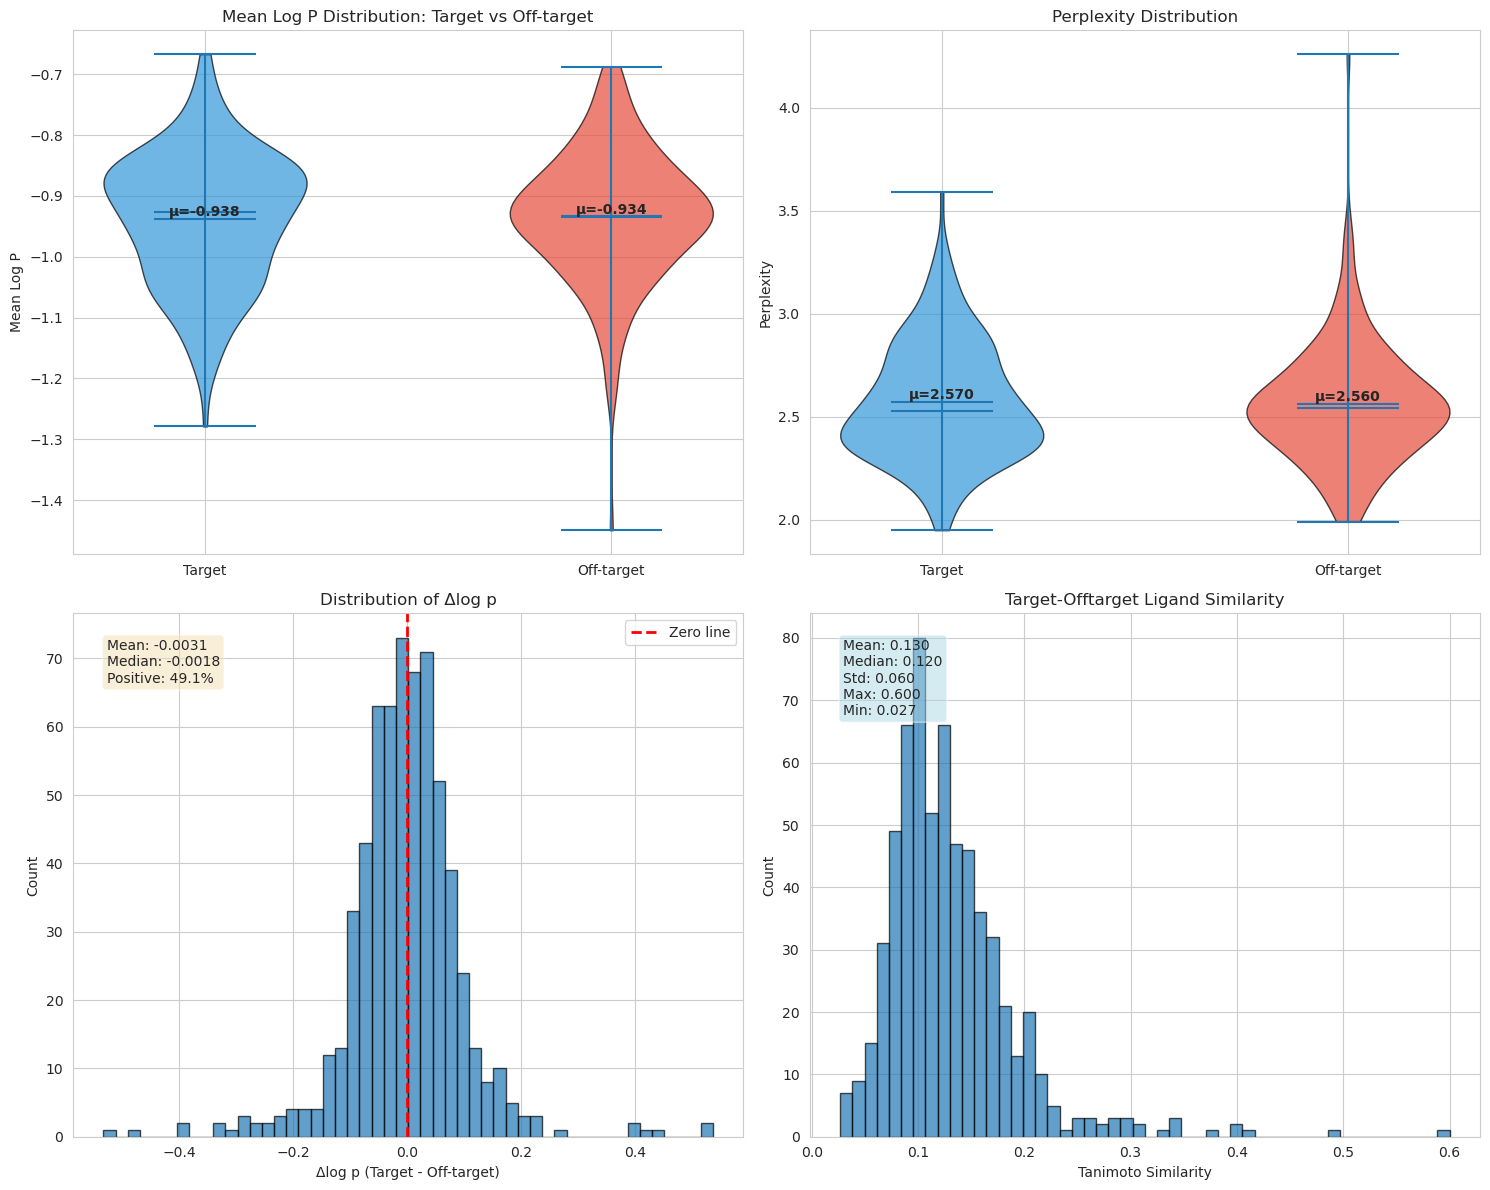

In [192]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Color palette
target_color = '#3498db'  # Blue
offtarget_color = '#e74c3c'  # Red

# 1. Log p distribution comparison with colors
violin_parts = axes[0, 0].violinplot(
    [results_df[results_df['type'] == 'target']['mean_log_p'].dropna(),
     results_df[results_df['type'] == 'off-target']['mean_log_p'].dropna()],
    positions=[0, 1],
    showmeans=True,
    showmedians=True
)
for i, (pc, color) in enumerate(zip(violin_parts['bodies'], [target_color, offtarget_color])):
    pc.set_facecolor(color)
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(['Target', 'Off-target'])
axes[0, 0].set_ylabel('Mean Log P')
axes[0, 0].set_title('Mean Log P Distribution: Target vs Off-target')

# Add mean value labels
target_mean = results_df[results_df['type'] == 'target']['mean_log_p'].mean()
off_mean = results_df[results_df['type'] == 'off-target']['mean_log_p'].mean()
axes[0, 0].text(0, target_mean, f'μ={target_mean:.3f}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0, 0].text(1, off_mean, f'μ={off_mean:.3f}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Perplexity comparison with colors
violin_parts2 = axes[0, 1].violinplot(
    [results_df[results_df['type'] == 'target']['perplexity'].dropna(),
     results_df[results_df['type'] == 'off-target']['perplexity'].dropna()],
    positions=[0, 1],
    showmeans=True,
    showmedians=True
)
for i, (pc, color) in enumerate(zip(violin_parts2['bodies'], [target_color, offtarget_color])):
    pc.set_facecolor(color)
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_xticklabels(['Target', 'Off-target'])
axes[0, 1].set_ylabel('Perplexity')
axes[0, 1].set_title('Perplexity Distribution')

# Add mean value labels
target_perp = results_df[results_df['type'] == 'target']['perplexity'].mean()
off_perp = results_df[results_df['type'] == 'off-target']['perplexity'].mean()
axes[0, 1].text(0, target_perp, f'μ={target_perp:.3f}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0, 1].text(1, off_perp, f'μ={off_perp:.3f}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')


# 3. Delta log p histogram
n, bins, patches = axes[1, 0].hist(delta_df['delta_mean_log_p'], bins=50, 
                                     edgecolor='black', alpha=0.7)
axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero line')
axes[1, 0].set_xlabel('Δlog p (Target - Off-target)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Distribution of Δlog p')

delta_mean = delta_df['delta_mean_log_p'].mean()
delta_median = delta_df['delta_mean_log_p'].median()
positive_pct = (delta_df['delta_mean_log_p'] > 0).sum() / len(delta_df) * 100

stats_text = f'Mean: {delta_mean:.4f}\nMedian: {delta_median:.4f}\nPositive: {positive_pct:.1f}%'
axes[1, 0].text(0.05, 0.95, stats_text, transform=axes[1, 0].transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 0].legend()

# 4. Tanimoto similarity histogram
n2, bins2, patches2 = axes[1, 1].hist(tanimoto_df['tanimoto_similarity'].dropna(), 
                                        bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Tanimoto Similarity')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Target-Offtarget Ligand Similarity')

tani_mean = tanimoto_df['tanimoto_similarity'].mean()
tani_median = tanimoto_df['tanimoto_similarity'].median()
tani_std = tanimoto_df['tanimoto_similarity'].std()
tani_max = tanimoto_df['tanimoto_similarity'].max()
tani_min = tanimoto_df['tanimoto_similarity'].min()

tani_text = f'Mean: {tani_mean:.3f}\nMedian: {tani_median:.3f}\nStd: {tani_std:.3f}\nMax: {tani_max:.3f}\nMin: {tani_min:.3f}'
axes[1, 1].text(0.05, 0.95, tani_text, transform=axes[1, 1].transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plots' / f'bindingdb_all_log_p_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## Correlation Analysis

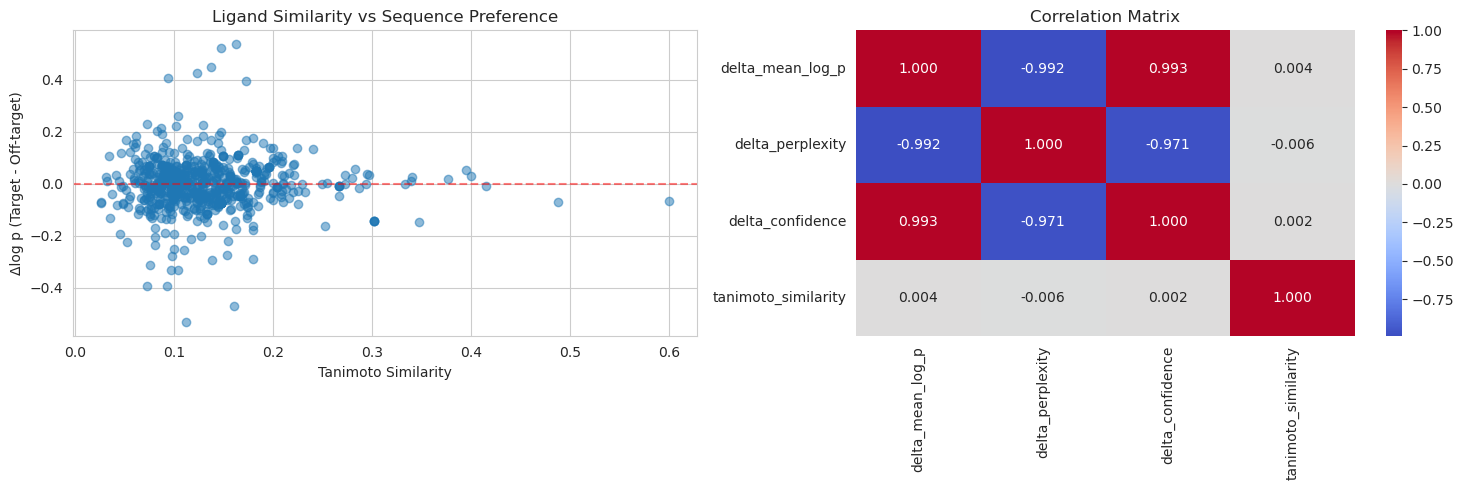

Correlation between Tanimoto similarity and Δlog p:
0.004


In [193]:
# Merge delta_df with tanimoto_df
merged_df = delta_df.merge(
    tanimoto_df[['uniprot_id', 'target_lig_id', 'offtarget_lig_id', 'tanimoto_similarity']],
    on=['uniprot_id', 'target_lig_id', 'offtarget_lig_id'],
    how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter: Tanimoto vs Delta log p
axes[0].scatter(merged_df['tanimoto_similarity'], merged_df['delta_mean_log_p'], alpha=0.5)
axes[0].set_xlabel('Tanimoto Similarity')
axes[0].set_ylabel('Δlog p (Target - Off-target)')
axes[0].set_title('Ligand Similarity vs Sequence Preference')
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)

# Correlation heatmap
corr_cols = ['delta_mean_log_p', 'delta_perplexity', 'delta_confidence', 'tanimoto_similarity']
corr_matrix = merged_df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Correlation Matrix')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plots' / f'bindingdb_all_correlation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Correlation between Tanimoto similarity and Δlog p:")
print(f"{merged_df[['tanimoto_similarity', 'delta_mean_log_p']].corr().iloc[0, 1]:.3f}")

## Per-Protein Analysis

In [194]:
# Average metrics per protein
per_protein_stats = merged_df.groupby('uniprot_id').agg({
    'delta_mean_log_p': ['mean', 'std', 'min', 'max'],
    'tanimoto_similarity': ['mean', 'std'],
    'target_mean_log_p': 'mean',
    'offtarget_mean_log_p': 'mean'
}).round(4)

per_protein_stats.columns = ['_'.join(col).strip() for col in per_protein_stats.columns]
per_protein_stats = per_protein_stats.sort_values('delta_mean_log_p_mean', ascending=False)

print("Top 10 proteins with highest Δlog p (best specificity):")
print(per_protein_stats.head(10))

print("\nBottom 10 proteins with lowest Δlog p (worst specificity):")
print(per_protein_stats.tail(10))

Top 10 proteins with highest Δlog p (best specificity):
            delta_mean_log_p_mean  delta_mean_log_p_std  delta_mean_log_p_min  \
uniprot_id                                                                      
P28482                     0.1393                0.0618                0.0436   
P47205                     0.1354                0.0797                0.0083   
P56817                     0.1153                0.0815                0.0155   
P11309                     0.0883                0.0564                0.0021   
P00523                     0.0761                0.0930               -0.0694   
P10275                     0.0745                0.0605                0.0146   
O15530                     0.0635                0.1163               -0.0538   
Q92793                     0.0581                0.1635               -0.0989   
P07949                     0.0496                   NaN                0.0496   
Q06187                     0.0485                0.01

## Sequence Recovery

### Configuration

In [195]:
from dataclasses import dataclass

BASE_DIR = Path("/scratch/yunmin/data/graph/lmpnn/bdb_pdb")
LMPNN_OUTDIR_KD = BASE_DIR / "Kd/lmpnn_out"
LMPNN_OUTDIR_IC50 = BASE_DIR / "IC50/lmpnn_out"
OUTDIR = LMPNN_OUTDIR_KD / "eval"
PLOT_DIR = LMPNN_OUTDIR_KD / "plots"
OUTDIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# If True, drop positions where either native/designed is nonstandard (X, -, etc.)
EXCLUDE_NONSTANDARD = False
EXCLUDE_CHARS = set(["X", "-", "*", "?", "U", "O", "B", "Z", "J"])

# LigandMPNN often uses ":" to separate chains in a single sequence line
STRIP_CHAIN_SEP = True
CHAIN_SEP = ":"

### Helper Functions

In [196]:
@dataclass
class FastaEntry:
    header: str
    seq: str


def read_fasta(fp: Path) -> List[FastaEntry]:
    entries: List[FastaEntry] = []
    header = None
    seq_parts: List[str] = []
    with fp.open("r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if header is not None:
                    entries.append(FastaEntry(header=header, seq="".join(seq_parts)))
                header = line[1:].strip()
                seq_parts = []
            else:
                seq_parts.append(line.strip())
        if header is not None:
            entries.append(FastaEntry(header=header, seq="".join(seq_parts)))
    return entries


def normalize_seq(s: str) -> str:
    s = s.strip().upper()
    if STRIP_CHAIN_SEP:
        s = s.replace(CHAIN_SEP, "")
    return s


def seq_recovery(native: str, designed: str) -> Tuple[float, int, int]:
    native = normalize_seq(native)
    designed = normalize_seq(designed)

    if len(native) != len(designed):
        return np.nan, 0, 0

    if not EXCLUDE_NONSTANDARD:
        denom = len(native)
        match = sum(1 for a, b in zip(native, designed) if a == b)
        return (match / denom) if denom > 0 else np.nan, match, denom

    match = 0
    denom = 0
    for a, b in zip(native, designed):
        if (a in EXCLUDE_CHARS) or (b in EXCLUDE_CHARS):
            continue
        denom += 1
        if a == b:
            match += 1
    return (match / denom) if denom > 0 else np.nan, match, denom


def parse_metadata_from_path(fp: Path, root: Path) -> Optional[Dict[str, str]]:
    # root/uniprot_id/target_type/ligand_het_id/seqs/<pdb>.fa
    try:
        rel = fp.relative_to(root)
    except ValueError:
        return None

    parts = rel.parts
    if len(parts) < 5:
        return None
    uniprot_id = parts[0]
    target_type = parts[1]
    ligand_het_id = parts[2]
    if parts[3] != "seqs":
        return None

    pdb_file = parts[4]
    pdb_id = re.sub(r"\.fa(sta)?$", "", pdb_file, flags=re.IGNORECASE)

    return {
        "uniprot_id": uniprot_id,
        "target_type": target_type,  # tar/off
        "ligand_het_id": ligand_het_id,
        "pdb_id": pdb_id,
        "fasta_path": str(fp),
    }


def collect_fasta_files(root: Path) -> List[Path]:
    return sorted(root.rglob("seqs/*.fa")) + sorted(root.rglob("seqs/*.fasta"))


def make_uniprot_tar_off_plot(df: pd.DataFrame) -> None:
    # Distribution comparison (not paired)
    for (uniprot_id, affinity_type), g in df.groupby(["uniprot_id", "affinity_type"]):
        gg = g[g["target_type"].isin(["tar", "off"])].copy()
        if gg.empty:
            continue

        tar = gg.loc[gg["target_type"] == "tar", "recovery"].dropna().values
        off = gg.loc[gg["target_type"] == "off", "recovery"].dropna().values
        if len(tar) == 0 and len(off) == 0:
            continue

        fig = plt.figure(figsize=(6, 4))
        ax = fig.add_subplot(111)

        data = []
        labels = []
        if len(tar) > 0:
            data.append(tar)
            labels.append("tar")
        if len(off) > 0:
            data.append(off)
            labels.append("off")

        ax.boxplot(data, tick_labels=labels, showfliers=False)

        rng = np.random.default_rng(0)
        for i, arr in enumerate(data, start=1):
            x = rng.normal(loc=i, scale=0.05, size=len(arr))
            ax.scatter(x, arr, s=10, alpha=0.5)

        ax.set_title(f"{uniprot_id} ({affinity_type}): sequence recovery (tar vs off)")
        ax.set_ylabel("Sequence recovery")
        ax.set_ylim(0.0, 1.0)
        ax.text(
            0.02, 0.02,
            f"n_tar={len(tar)}, n_off={len(off)}\n(note: different ligands, unpaired)",
            transform=ax.transAxes,
            fontsize=8,
            va="bottom",
        )

        fig.tight_layout()
        fig.savefig(PLOT_DIR / f"{affinity_type}_{uniprot_id}_sequence_recovery.png", dpi=200)
        print(f"[OK] Plot saved: {affinity_type}_{uniprot_id}_sequence_recovery.png")
        plt.close(fig)


### Calculate sequence recovery

In [197]:
fasta_files = []

rows = []
bad_files = []

for fp in collect_fasta_files(LMPNN_OUTDIR_KD):
    meta = parse_metadata_from_path(fp, LMPNN_OUTDIR_KD)
    if meta is None:
        continue
    fasta_files.append((fp, "Kd", meta))
for fp in collect_fasta_files(LMPNN_OUTDIR_IC50):
    meta = parse_metadata_from_path(fp, LMPNN_OUTDIR_IC50)
    if meta is None:
        continue
    fasta_files.append((fp, "IC50", meta))

for fp, affinity_type, meta in fasta_files:
    entries = read_fasta(fp)
    if len(entries) < 2:
        bad_files.append((str(fp), "fasta_has_less_than_2_sequences"))
        continue

    native = entries[0].seq
    n_native = normalize_seq(native)

    for j, ent in enumerate(entries[1:], start=1):
        designed = ent.seq
        rec, match, denom = seq_recovery(native, designed)

        # (optional) store lengths after normalization too
        n_designed = normalize_seq(designed)

        rows.append({
            **meta,
            "affinity_type": affinity_type,
            "designed_idx": j,
            "native_len_raw": len(native),
            "designed_len_raw": len(designed),
            "native_len_norm": len(n_native),
            "designed_len_norm": len(n_designed),
            "match": match,
            "denom": denom,
            "recovery": rec,
            "native_header": entries[0].header,
            "designed_header": ent.header,
        })

sequence_recovery_df = pd.DataFrame(rows)
out_csv = OUTDIR / "lmpnn_sequence_recovery.csv"
sequence_recovery_df.to_csv(out_csv, index=False)

# Summary
if not sequence_recovery_df.empty:
    summary = (
        sequence_recovery_df[sequence_recovery_df["target_type"].isin(["tar", "off"])]
        .groupby(["uniprot_id", "target_type"], as_index=False)
        .agg(
            n=("recovery", lambda x: int(np.isfinite(x).sum())),
            mean=("recovery", "mean"),
            std=("recovery", "std"),
            median=("recovery", "median"),
        )
    )
    summary.to_csv(OUTDIR / "lmpnn_sequence_recovery_summary.csv", index=False)
    make_uniprot_tar_off_plot(sequence_recovery_df)

if bad_files:
    with (OUTDIR / "lmpnn_sequence_recovery_bad_fasta_files.csv").open("w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["path", "reason"])
        w.writerows(bad_files)

print(f"[OK] CSV: {out_csv}")
print(f"[OK] Outputs in: {OUTDIR}")

display(sequence_recovery_df.head(10))


[OK] Plot saved: IC50_O14757_sequence_recovery.png
[OK] Plot saved: IC50_O15530_sequence_recovery.png
[OK] Plot saved: IC50_O60674_sequence_recovery.png
[OK] Plot saved: Kd_O60674_sequence_recovery.png
[OK] Plot saved: IC50_O60885_sequence_recovery.png
[OK] Plot saved: Kd_O60885_sequence_recovery.png
[OK] Plot saved: IC50_O75530_sequence_recovery.png
[OK] Plot saved: IC50_P00523_sequence_recovery.png
[OK] Plot saved: IC50_P00746_sequence_recovery.png
[OK] Plot saved: IC50_P00797_sequence_recovery.png
[OK] Plot saved: IC50_P00918_sequence_recovery.png
[OK] Plot saved: Kd_P00918_sequence_recovery.png
[OK] Plot saved: Kd_P01375_sequence_recovery.png
[OK] Plot saved: IC50_P04629_sequence_recovery.png
[OK] Plot saved: IC50_P07900_sequence_recovery.png
[OK] Plot saved: Kd_P07900_sequence_recovery.png
[OK] Plot saved: IC50_P07949_sequence_recovery.png
[OK] Plot saved: Kd_P08581_sequence_recovery.png
[OK] Plot saved: IC50_P0A0K8_sequence_recovery.png
[OK] Plot saved: IC50_P10275_sequence_recov

,uniprot_id,target_type,ligand_het_id,pdb_id,fasta_path,affinity_type,designed_idx,native_len_raw,designed_len_raw,native_len_norm,designed_len_norm,match,denom,recovery,native_header,designed_header
0,O60674,off,8MY,5UT6,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lm...,Kd,1,272,272,272,272,147,272,0.540441,"5UT6, T=0.3, seed=111, num_res=272, num_ligand...","5UT6, id=1, T=0.3, seed=111, overall_confidenc..."
1,O60674,off,8MY,5UT6,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lm...,Kd,2,272,272,272,272,146,272,0.536765,"5UT6, T=0.3, seed=111, num_res=272, num_ligand...","5UT6, id=2, T=0.3, seed=111, overall_confidenc..."
2,O60674,off,8MY,5UT6,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lm...,Kd,3,272,272,272,272,135,272,0.496324,"5UT6, T=0.3, seed=111, num_res=272, num_ligand...","5UT6, id=3, T=0.3, seed=111, overall_confidenc..."
3,O60674,off,8MY,5UT6,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lm...,Kd,4,272,272,272,272,142,272,0.522059,"5UT6, T=0.3, seed=111, num_res=272, num_ligand...","5UT6, id=4, T=0.3, seed=111, overall_confidenc..."
4,O60674,off,8MY,5UT6,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lm...,Kd,5,272,272,272,272,145,272,0.533088,"5UT6, T=0.3, seed=111, num_res=272, num_ligand...","5UT6, id=5, T=0.3, seed=111, overall_confidenc..."
5,O60674,off,8MY,5UT6,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lm...,Kd,6,272,272,272,272,143,272,0.525735,"5UT6, T=0.3, seed=111, num_res=272, num_ligand...","5UT6, id=6, T=0.3, seed=111, overall_confidenc..."
6,O60674,off,8MY,5UT6,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lm...,Kd,7,272,272,272,272,137,272,0.503676,"5UT6, T=0.3, seed=111, num_res=272, num_ligand...","5UT6, id=7, T=0.3, seed=111, overall_confidenc..."
7,O60674,off,8MY,5UT6,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lm...,Kd,8,272,272,272,272,141,272,0.518382,"5UT6, T=0.3, seed=111, num_res=272, num_ligand...","5UT6, id=8, T=0.3, seed=111, overall_confidenc..."
8,O60674,off,8MY,5UT6,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lm...,Kd,9,272,272,272,272,135,272,0.496324,"5UT6, T=0.3, seed=111, num_res=272, num_ligand...","5UT6, id=9, T=0.3, seed=111, overall_confidenc..."
9,O60674,off,8MY,5UT6,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lm...,Kd,10,272,272,272,272,132,272,0.485294,"5UT6, T=0.3, seed=111, num_res=272, num_ligand...","5UT6, id=10, T=0.3, seed=111, overall_confiden..."


### Protein-wise sequence recovery

In [198]:
sequence_recovery_df = sequence_recovery_df[sequence_recovery_df["target_type"].isin(["tar", "off"])].copy()
sequence_recovery_df = sequence_recovery_df[np.isfinite(sequence_recovery_df["recovery"])]

# uniprot-wise tar/off average recovery
mean_tbl = (
    sequence_recovery_df.groupby(["uniprot_id", "target_type"], as_index=False)["recovery"]
      .mean()
      .pivot(index="uniprot_id", columns="target_type", values="recovery")
)

# Δ = tar - off
mean_tbl["delta_tar_minus_off"] = mean_tbl["tar"] - mean_tbl["off"]

# Keep only uniprot IDs with both tar and off, and sort by delta descending
rank = (
    mean_tbl.dropna(subset=["tar", "off"])
            .sort_values("delta_tar_minus_off", ascending=False)
            .reset_index()
)

# (optional) also attach sample sizes: n for tar/off respectively
n_tbl = (
    sequence_recovery_df.groupby(["uniprot_id", "target_type"])["recovery"]
      .size()
      .unstack("target_type")
      .rename(columns={"tar": "n_tar", "off": "n_off"})
)

rank = rank.merge(n_tbl, on="uniprot_id", how="left")

# Top K entries
K = 30
print(rank[["uniprot_id", "tar", "off", "delta_tar_minus_off", "n_tar", "n_off"]].head(K))

out_path = OUTDIR / "delta_mean_recovery_tar_minus_off_ranked.csv"
rank.to_csv(out_path, index=False)
print("saved:", out_path)


target_type uniprot_id       tar       off  delta_tar_minus_off  n_tar  n_off
0               P07949  0.497755  0.439929             0.057825   10.0   10.0
1               P47205  0.598077  0.541473             0.056604   30.0   30.0
2               Q92793  0.559920  0.503789             0.056131   60.0   60.0
3               P28482  0.582993  0.528950             0.054044   30.0   30.0
4               P56817  0.549800  0.506287             0.043514   30.0   30.0
5               P11309  0.580220  0.540577             0.039643   30.0   30.0
6               P00523  0.538147  0.501493             0.036654   30.0   20.0
7               Q96RI1  0.478668  0.442874             0.035794   30.0   30.0
8               P12931  0.528116  0.497460             0.030656   20.0   30.0
9               P37231  0.498807  0.470236             0.028570   20.0   30.0
10              Q6P988  0.589355  0.561711             0.027644   30.0   30.0
11              P04629  0.528809  0.504052             0.024757 

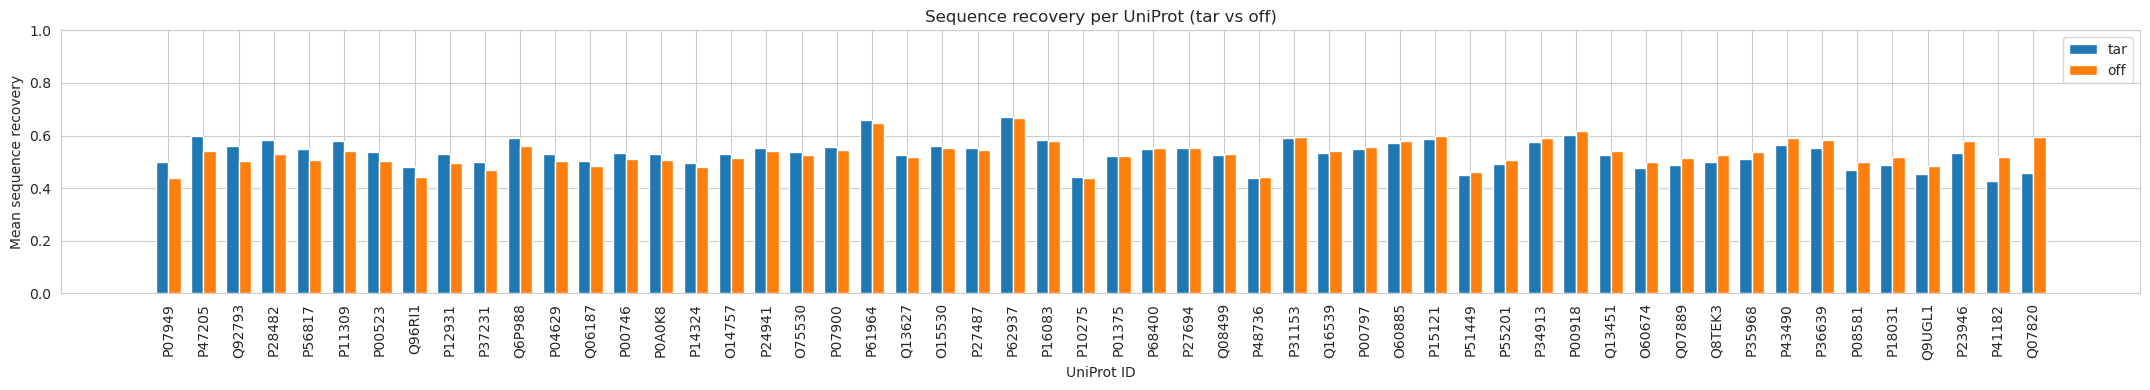

saved: /scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lmpnn_out/plots/sequence_recovery_per_uniprot.png


In [199]:
mean_tbl = (
    sequence_recovery_df.groupby(["uniprot_id", "target_type"])["recovery"]
      .mean()
      .unstack("target_type")
)

mean_tbl = mean_tbl.dropna(subset=["tar", "off"])

mean_tbl["delta"] = mean_tbl["tar"] - mean_tbl["off"]
mean_tbl = mean_tbl.sort_values("delta", ascending=False)

# Bar plot: tar vs off per uniprot
uniprots = mean_tbl.index.tolist()
x = np.arange(len(uniprots))
width = 0.35

fig, ax = plt.subplots(figsize=(max(8, len(uniprots) * 0.4), 4))

ax.bar(x - width/2, mean_tbl["tar"], width, label="tar")
ax.bar(x + width/2, mean_tbl["off"], width, label="off")

ax.set_xlabel("UniProt ID")
ax.set_ylabel("Mean sequence recovery")
ax.set_title("Sequence recovery per UniProt (tar vs off)")
ax.set_ylim(0.0, 1.0)

ax.set_xticks(x)
ax.set_xticklabels(uniprots, rotation=90)

ax.legend()

fig.tight_layout()
plt.show()

out_png  = PLOT_DIR / "sequence_recovery_per_uniprot.png"
fig.savefig(out_png, dpi=200)
plt.close(fig)
print("saved:", out_png)

### Overall Sequence Recovery

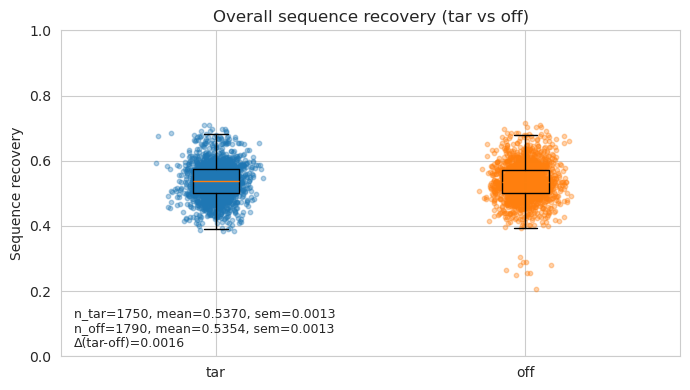

saved: /scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lmpnn_out/plots/overall_tar_vs_off_recovery.png


In [200]:
tar = sequence_recovery_df.loc[sequence_recovery_df["target_type"] == "tar", "recovery"].to_numpy()
off = sequence_recovery_df.loc[sequence_recovery_df["target_type"] == "off", "recovery"].to_numpy()

def mean_sem(x: np.ndarray):
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan, np.nan
    m = float(np.mean(x))
    sem = float(np.std(x, ddof=1) / np.sqrt(len(x))) if len(x) > 1 else 0.0
    return m, sem

m_tar, sem_tar = mean_sem(tar)
m_off, sem_off = mean_sem(off)

# boxplot
fig = plt.figure(figsize=(7, 4))
ax = fig.add_subplot(111)

data = []
tick_labels = []
if len(tar) > 0:
    data.append(tar)
    tick_labels.append("tar")
if len(off) > 0:
    data.append(off)
    tick_labels.append("off")

ax.boxplot(data, tick_labels=tick_labels, showfliers=False)

# jitter scatter
rng = np.random.default_rng(0)
for i, arr in enumerate(data, start=1):
    x = rng.normal(loc=i, scale=0.05, size=len(arr))
    ax.scatter(x, arr, s=10, alpha=0.35)

ax.set_title("Overall sequence recovery (tar vs off)")
ax.set_ylabel("Sequence recovery")
ax.set_ylim(0.0, 1.0)

txt = (
    f"n_tar={len(tar)}, mean={m_tar:.4f}, sem={sem_tar:.4f}\n"
    f"n_off={len(off)}, mean={m_off:.4f}, sem={sem_off:.4f}\n"
    f"Δ(tar-off)={(m_tar-m_off):.4f}"
)
ax.text(0.02, 0.02, txt, transform=ax.transAxes, fontsize=9, va="bottom")

fig.tight_layout()
plt.show()

out_png  = PLOT_DIR / "overall_tar_vs_off_recovery.png"
fig.savefig(out_png, dpi=200)
plt.close(fig)
print("saved:", out_png)


## Save Results

In [201]:
# Save all dataframes
HEADER=f'bindingdb_{ASSAY_TYPE}'
results_df.to_csv(OUTPUT_DIR / f'{HEADER}_all_lmpnn_metrics.csv', index=False)
delta_df.to_csv(OUTPUT_DIR / f'{HEADER}_delta_metrics.csv', index=False)
tanimoto_df.to_csv(OUTPUT_DIR / f'{HEADER}_tanimoto_similarities.csv', index=False)
merged_df.to_csv(OUTPUT_DIR / f'{HEADER}_merged_analysis.csv', index=False)
per_protein_stats.to_csv(OUTPUT_DIR / f'{HEADER}_per_protein_statistics.csv', index=False)

print(f"All results saved to {OUTPUT_DIR}")

All results saved to /scratch/yunmin/data/graph/lmpnn/bdb_pdb/all/eval


## Summary Report

In [202]:
summary = f"""
=== LigandMPNN Evaluation Summary ===

Total Proteins: {len(results_df['uniprot_id'].unique())}
Total Target Designs: {len(results_df[results_df['type'] == 'target'])}
Total Off-target Designs: {len(results_df[results_df['type'] == 'off-target'])}

Mean Log P:
  Target: {results_df[results_df['type'] == 'target']['mean_log_p'].mean():.4f}
  Off-target: {results_df[results_df['type'] == 'off-target']['mean_log_p'].mean():.4f}
  Δlog p: {delta_df['delta_mean_log_p'].mean():.4f} ± {delta_df['delta_mean_log_p'].std():.4f}

Perplexity:
  Target: {results_df[results_df['type'] == 'target']['perplexity'].mean():.4f}
  Off-target: {results_df[results_df['type'] == 'off-target']['perplexity'].mean():.4f}

Tanimoto Similarity (Target-Off-target Ligands):
  Mean: {tanimoto_df['tanimoto_similarity'].mean():.3f}
  Median: {tanimoto_df['tanimoto_similarity'].median():.3f}
  Range: [{tanimoto_df['tanimoto_similarity'].min():.3f}, {tanimoto_df['tanimoto_similarity'].max():.3f}]

Specificity:
  Proteins with positive Δlog p: {(per_protein_stats['delta_mean_log_p_mean'] > 0).sum()} / {len(per_protein_stats)}
  Best Δlog p: {per_protein_stats['delta_mean_log_p_mean'].max():.4f}
  Worst Δlog p: {per_protein_stats['delta_mean_log_p_mean'].min():.4f}

Sequence Recovery:
  Overall Mean Recovery (tar): {mean_tbl['tar'].mean():.4f}
  Overall Mean Recovery (off): {mean_tbl['off'].mean():.4f}
  Δ Recovery (tar - off): {(mean_tbl['tar'].mean() - mean_tbl['off'].mean()):.4f}
"""

print(summary)

with open(OUTPUT_DIR / f'{HEADER}_summary_report.txt', 'w') as f:
    f.write(summary)


=== LigandMPNN Evaluation Summary ===

Total Proteins: 55
Total Target Designs: 175
Total Off-target Designs: 179

Mean Log P:
  Target: -0.9377
  Off-target: -0.9338
  Δlog p: -0.0031 ± 0.1006

Perplexity:
  Target: 2.5697
  Off-target: 2.5595

Tanimoto Similarity (Target-Off-target Ligands):
  Mean: 0.130
  Median: 0.120
  Range: [0.027, 0.600]

Specificity:
  Proteins with positive Δlog p: 27 / 54
  Best Δlog p: 0.1393
  Worst Δlog p: -0.3316

Sequence Recovery:
  Overall Mean Recovery (tar): 0.5325
  Overall Mean Recovery (off): 0.5320
  Δ Recovery (tar - off): 0.0004



---
# Part 2: Boltz-2 Evaluation
Input: Boltz-2 outputs (predictions/<confidence, plddt, pae, pde>.json, model.pdb)
Output: 
  - Structure prediction RMSD
  - Binding affinity predictions comparison

## Check # of Atoms in Ligand
The official Boltz-2 documentation notes that ligands with more than 56 heavy atoms may show lower accuracy due to training set limitations.

This script counts how many molecules exceed this atom limit.

LIGAND ATOM COUNT ANALYSIS

Valid SMILES: 354 / 354

ATOM COUNT STATISTICS
Mean: 25.9 atoms
Median: 26 atoms
Range: 6-78 atoms
Std: 10.5 atoms

⚠️  LIGANDS EXCEEDING BOLTZ-2 LIMIT (>56 atoms)
Count: 3 / 354 (0.8%)

Top violators:
    uniprot_id ligand_het_id  n_heavy_atoms        type
40      P62937           SFA             78      target
51      Q13451           RAP             65      target
268     Q07820           70R             57  off-target

By target type:
type
target        2
off-target    1
Name: count, dtype: int64


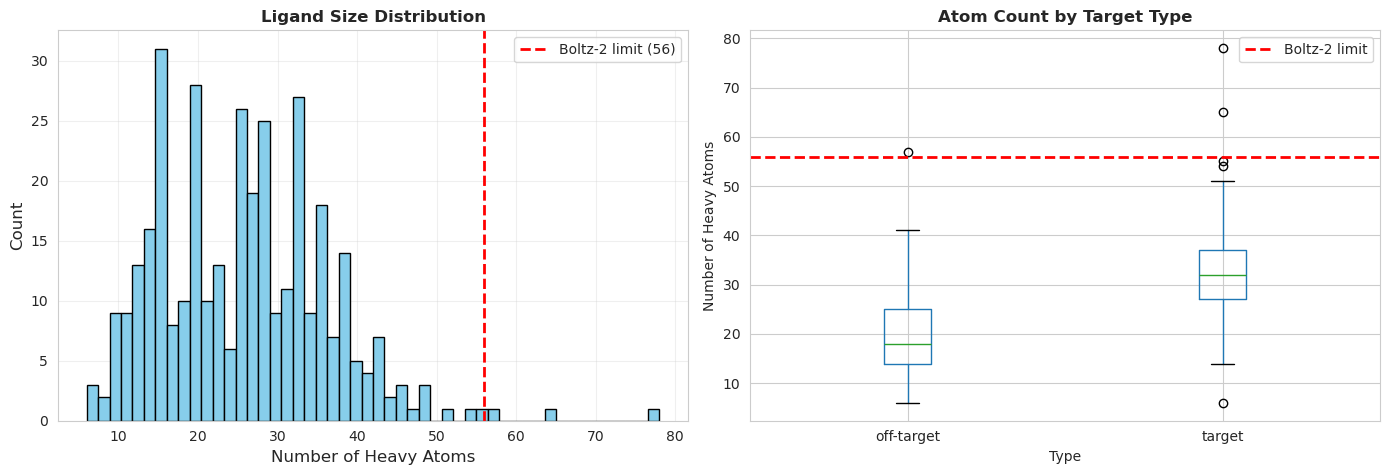


✅ Saved plot to /scratch/yunmin/data/graph/lmpnn/bdb_pdb/all/eval/plots/bindingdb_all_ligand_atom_counts.png

RECOMMENDATION
Consider excluding 3 ligands (>56 atoms) before Boltz-2 run
These predictions will be unreliable according to Boltz-2 docs

Filtered dataset: 351 / 354 entries


In [203]:
def count_heavy_atoms(smiles: str) -> int:
    """Count heavy (non-hydrogen) atoms in molecule."""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return -1
        return mol.GetNumHeavyAtoms()
    except:
        return -1

print("="*60)
print("LIGAND ATOM COUNT ANALYSIS")
print("="*60)

# Calculate atom counts
results_df['n_heavy_atoms'] = results_df['ligand_smiles'].apply(count_heavy_atoms)

# Remove invalid SMILES
valid_mask = results_df['n_heavy_atoms'] > 0
print(f"\nValid SMILES: {valid_mask.sum()} / {len(results_df)}")

if (~valid_mask).sum() > 0:
    print(f"\n⚠️  Invalid SMILES found: {(~valid_mask).sum()}")
    print(results_df[~valid_mask][['uniprot_id', 'ligand_het_id', 'ligand_smiles']].head())

# Statistics
atom_counts = results_df[valid_mask]['n_heavy_atoms']
print(f"\n{'='*60}")
print("ATOM COUNT STATISTICS")
print(f"{'='*60}")
print(f"Mean: {atom_counts.mean():.1f} atoms")
print(f"Median: {atom_counts.median():.0f} atoms")
print(f"Range: {atom_counts.min()}-{atom_counts.max()} atoms")
print(f"Std: {atom_counts.std():.1f} atoms")

# Check Boltz-2 limit (56 atoms)
over_limit = results_df[results_df['n_heavy_atoms'] > 56]
print(f"\n{'='*60}")
print(f"⚠️  LIGANDS EXCEEDING BOLTZ-2 LIMIT (>56 atoms)")
print(f"{'='*60}")
print(f"Count: {len(over_limit)} / {len(results_df)} ({len(over_limit)/len(results_df)*100:.1f}%)")

if len(over_limit) > 0:
    print(f"\nTop violators:")
    print(over_limit.nlargest(10, 'n_heavy_atoms')[['uniprot_id', 'ligand_het_id', 'n_heavy_atoms', 'type']])
    
    print(f"\nBy target type:")
    print(over_limit['type'].value_counts())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(atom_counts[atom_counts <= 100], bins=50, color='skyblue', edgecolor='black')
axes[0].axvline(56, color='red', linestyle='--', linewidth=2, label='Boltz-2 limit (56)')
axes[0].set_xlabel('Number of Heavy Atoms', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Ligand Size Distribution', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot by target type
results_df[valid_mask].boxplot(column='n_heavy_atoms', by='type', ax=axes[1])
axes[1].axhline(56, color='red', linestyle='--', linewidth=2, label='Boltz-2 limit')
axes[1].set_title('Atom Count by Target Type', fontweight='bold')
axes[1].set_xlabel('Type')
axes[1].set_ylabel('Number of Heavy Atoms')
axes[1].legend()
plt.suptitle('')  # Remove default title

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plots' / f'bindingdb_all_ligand_atom_counts.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Saved plot to {OUTPUT_DIR / 'plots' / f'bindingdb_all_ligand_atom_counts.png'}")

# Create filtered dataset (optional: exclude >56 atoms)
if len(over_limit) > 0:
    print(f"\n{'='*60}")
    print("RECOMMENDATION")
    print(f"{'='*60}")
    print(f"Consider excluding {len(over_limit)} ligands (>56 atoms) before Boltz-2 run")
    print(f"These predictions will be unreliable according to Boltz-2 docs")
    
    # Create filtered version
    results_df_filtered = results_df[results_df['n_heavy_atoms'] <= 56].copy()
    print(f"\nFiltered dataset: {len(results_df_filtered)} / {len(results_df)} entries")

## Run Boltz-2

``` /home/yunmin/proj/LigandMPNN/sh/run_boltz2.sh ```

## Configuration

In [204]:
BOLTZ_INPUT_DIR_KD = "/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/boltz2/inputs"
BOLTZ_INPUT_DIR_IC50 = "/scratch/yunmin/data/graph/lmpnn/bdb_pdb/IC50/boltz2/inputs"

BOLTZ_OUTPUT_DIR_KD = Path('/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/boltz2/outputs')
BOLTZ_OUTPUT_DIR_IC50 = Path('/scratch/yunmin/data/graph/lmpnn/bdb_pdb/IC50/boltz2/outputs')
# boltz_results_<uniprot_id>_<target_type>_<ligand_het_id>_seq[00-09] 
# (e.g. boltz_results_O60674_off_DQX_seq09/)

BOLTZ_EVAL_DIR = Path('/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/boltz2/eval')
os.makedirs(BOLTZ_EVAL_DIR, exist_ok=True)
os.makedirs(BOLTZ_EVAL_DIR / 'plots', exist_ok=True)

## Load Boltz-2 Results

In [206]:
def parse_boltz2_prediction_dir(pred_dir: Path, assay_type: str) -> List[Dict]:
    # boltz_results_<uniprot_id>_<target_type>_<ligand_het_id>_seq<seq_num>
    m = re.match(r'([^_]+)_([^_]+)_([^_]+)_seq(\d+)', pred_dir.name)
    if not m:
        return []
    uniprot_id, target_type, ligand_het_id, seq_num = m.groups()
    records = []
    aff_path = pred_dir / f"affinity_{uniprot_id}_{target_type}_{ligand_het_id}_seq{seq_num}.json"
    if not aff_path.exists():
        return []
    try:
        with open(aff_path) as f:
            aff_json = json.load(f)
    except Exception:
        return []
    for model_num in range(3):
        # affinity pred values
        aff = aff_json.get("affinity_pred_value", np.nan)
        prob = aff_json.get("affinity_probability_binary", np.nan)
        # confidence
        conf_path = pred_dir / f"confidence_{uniprot_id}_{target_type}_{ligand_het_id}_seq{seq_num}_model_{model_num}.json"
        try:
            with open(conf_path) as f:
                conf_json = json.load(f)
            confidence_score = conf_json.get("confidence_score", np.nan)
            ptm = conf_json.get("ptm", np.nan)
            iptm = conf_json.get("iptm", np.nan)
            ligand_iptm = conf_json.get("ligand_iptm", np.nan)
            complex_plddt = conf_json.get("complex_plddt", np.nan)
            complex_iplddt = conf_json.get("complex_iplddt", np.nan)
            complex_pde = conf_json.get("complex_pde", np.nan)
            complex_ipde = conf_json.get("complex_ipde", np.nan)
        except Exception:
            confidence_score = ptm = iptm = ligand_iptm = complex_plddt = complex_iplddt = complex_pde = complex_ipde = np.nan
        # pae
        pae_path = pred_dir / f"pae_{uniprot_id}_{target_type}_{ligand_het_id}_seq{seq_num}_model_{model_num}.npz"
        try:
            pae = np.load(pae_path)
            pae_mean = float(np.mean(pae[pae.files[0]]))
        except Exception:
            pae_mean = np.nan
        # pde
        pde_path = pred_dir / f"pde_{uniprot_id}_{target_type}_{ligand_het_id}_seq{seq_num}_model_{model_num}.npz"
        try:
            pde = np.load(pde_path)
            pde_mean = float(np.mean(pde[pde.files[0]]))
        except Exception:
            pde_mean = np.nan
        # plddt
        plddt_path = pred_dir / f"plddt_{uniprot_id}_{target_type}_{ligand_het_id}_seq{seq_num}_model_{model_num}.npz"
        try:
            plddt = np.load(plddt_path)
            plddt_mean = float(np.mean(plddt[plddt.files[0]]))
        except Exception:
            plddt_mean = np.nan
        records.append({
            "uniprot_id": uniprot_id,
            "target_type": target_type,
            "ligand_het_id": ligand_het_id,
            "seq_num": int(seq_num),
            "model_num": model_num,
            "assay_type": assay_type,
            "affinity_pred_value": aff,
            "affinity_probability_binary": prob,
            "confidence_score": confidence_score,
            "ptm": ptm,
            "iptm": iptm,
            "ligand_iptm": ligand_iptm,
            "complex_plddt": complex_plddt,
            "complex_iplddt": complex_iplddt,
            "complex_pde": complex_pde,
            "complex_ipde": complex_ipde,
            "pae_mean": pae_mean,
            "pde_mean": pde_mean,
            "plddt_mean": plddt_mean,
            "pred_path": str(pred_dir)
        })
    return records

boltz_pred_dirs_kd = list(BOLTZ_OUTPUT_DIR_KD.glob("boltz_results_*_seq*"))
boltz_pred_dirs_ic50 = list(BOLTZ_OUTPUT_DIR_IC50.glob("boltz_results_*_seq*"))

all_records = []
print("Processing Kd Boltz-2 predictions...")
for pred_dir in tqdm(boltz_pred_dirs_kd):
    m = re.match(r'boltz_results_([^_]+)_([^_]+)_([^_]+)_seq(\d+)', pred_dir.name)
    if not m:
        continue
    uniprot_id, target_type, ligand_het_id, seq_num = m.groups()
    pred_subdir = pred_dir / "predictions" / f"{uniprot_id}_{target_type}_{ligand_het_id}_seq{seq_num}"
    if pred_subdir.exists():
        all_records.extend(parse_boltz2_prediction_dir(pred_subdir, 'Kd'))

print("Processing IC50 Boltz-2 predictions...")
for pred_dir in tqdm(boltz_pred_dirs_ic50):
    m = re.match(r'boltz_results_([^_]+)_([^_]+)_([^_]+)_seq(\d+)', pred_dir.name)
    if not m:
        continue
    uniprot_id, target_type, ligand_het_id, seq_num = m.groups()
    pred_subdir = pred_dir / "predictions" / f"{uniprot_id}_{target_type}_{ligand_het_id}_seq{seq_num}"
    if pred_subdir.exists():
        all_records.extend(parse_boltz2_prediction_dir(pred_subdir, 'IC50'))

boltz2_stats_df = pd.DataFrame(all_records)
print(boltz2_stats_df.shape)
print(boltz2_stats_df.columns.tolist())
print(
    "Assay types:", 
    len(boltz2_stats_df[boltz2_stats_df['assay_type'] == 'Kd']), 
    len(boltz2_stats_df[boltz2_stats_df['assay_type'] == 'IC50'])
    )
print(
    "Target types:", 
    len(boltz2_stats_df[boltz2_stats_df['target_type'] == 'tar']), 
    len(boltz2_stats_df[boltz2_stats_df['target_type'] == 'off'])
    )
display(boltz2_stats_df.head())

boltz2_stats_df.to_csv(BOLTZ_EVAL_DIR / f"total_boltz2_all_stats.csv", index=False)

Processing Kd Boltz-2 predictions...


100%|██████████| 890/890 [00:25<00:00, 35.33it/s]


Processing IC50 Boltz-2 predictions...


100%|██████████| 2650/2650 [01:16<00:00, 34.74it/s]

(10350, 20)
['uniprot_id', 'target_type', 'ligand_het_id', 'seq_num', 'model_num', 'assay_type', 'affinity_pred_value', 'affinity_probability_binary', 'confidence_score', 'ptm', 'iptm', 'ligand_iptm', 'complex_plddt', 'complex_iplddt', 'complex_pde', 'complex_ipde', 'pae_mean', 'pde_mean', 'plddt_mean', 'pred_path']
Assay types: 2670 7680
Target types: 5070 5280


,uniprot_id,target_type,ligand_het_id,seq_num,model_num,assay_type,affinity_pred_value,affinity_probability_binary,confidence_score,ptm,iptm,ligand_iptm,complex_plddt,complex_iplddt,complex_pde,complex_ipde,pae_mean,pde_mean,plddt_mean,pred_path
0,Q07889,off,QTG,8,0,Kd,1.630776,0.110000,0.493119,0.307234,0.374540,0.374540,0.522764,0.400837,3.433549,11.820915,25.874355,12.611746,0.522764,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/bo...
1,Q07889,off,QTG,8,1,Kd,1.630776,0.110000,0.488485,0.305038,0.337438,0.337438,0.526247,0.405348,3.529146,13.210999,26.073168,12.717293,0.526247,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/bo...
2,Q07889,off,QTG,8,2,Kd,1.630776,0.110000,0.484590,0.301075,0.322768,0.322768,0.525045,0.395679,3.487561,12.688292,26.098070,12.492831,0.525045,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/bo...
3,Q92793,tar,YF2,7,0,Kd,-0.754593,0.490751,0.716558,0.341525,0.666075,0.666075,0.729179,0.626461,2.076877,10.348988,23.538967,10.457597,0.729179,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/bo...
4,Q92793,tar,YF2,7,1,Kd,-0.754593,0.490751,0.713991,0.315289,0.665819,0.665819,0.726034,0.621812,2.135687,10.674129,23.824492,10.683431,0.726034,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/bo...


## Basic Statistics

In [207]:
df = boltz2_stats_df

# Target type Distribution
print("=" * 60)
print("Distribution of Target Type")
print("=" * 60)
print(df['target_type'].value_counts())
print(f"\nTotal samples: {len(df)}")

# Uniprot ID Distribution
print("\n" + "=" * 60)
print("Distribution of Uniprot ID")
print("=" * 60)
print(df.groupby(['uniprot_id', 'target_type']).size().unstack(fill_value=0))

Distribution of Target Type
target_type
off    5280
tar    5070
Name: count, dtype: int64

Total samples: 10350

Distribution of Uniprot ID
target_type  off  tar
uniprot_id           
O14757        90   90
O15530        60   90
O60674       180  150
O60885       150  150
O75530        90   90
P00523        60   90
P00746        90   60
P00797        90   90
P00918       180  180
P01375        90   90
P04629        90   90
P07900       180  120
P07949        30   30
P08581        90   60
P0A0K8        90   90
P10275        90   90
P11309        90   90
P12931        90   30
P14324        90   90
P15121        90   90
P16083        90   90
P18031        90   90
P23946        90   90
P24941       120  180
P27694        60   30
P28482        90   90
P31153        90   90
P34913        90   90
P35968        90   90
P36639       180  180
P37231        90   60
P41182        30   30
P43490        90   30
P47205        90   90
P48736        90   90
P51449        90   90
P55201        90   90
P5

In [209]:
# Target vs Off-target Statistics
print("=" * 80)
print("Target vs Off-target Statistics")
print("=" * 80)

metrics = ['confidence_score', 'ptm', 'iptm', 'ligand_iptm', 
           'complex_plddt', 'complex_iplddt', 'complex_pde', 'complex_ipde',
           'pae_mean', 'pde_mean', 'plddt_mean', 
           'affinity_pred_value', 'affinity_probability_binary']

comparison = df.groupby('target_type')[metrics].agg(['mean', 'std', 'median', 'min', 'max'])
comparison

Target vs Off-target Statistics


confidence_score                                          \
                        mean       std    median       min       max   
target_type                                                            
off                 0.769201  0.175430  0.832427  0.292643  0.983584   
tar                 0.781167  0.173828  0.856268  0.253857  0.980632   

                  ptm                                          ...  \
                 mean       std    median       min       max  ...   
target_type                                                    ...   
off          0.715948  0.231421  0.744916  0.197278  0.986002  ...   
tar          0.710639  0.224907  0.709061  0.191604  0.983599  ...   

            affinity_pred_value                                          \
                           mean       std    median       min       max   
target_type                                                               
off                    0.989496  0.831363  1.085226 -2.676682  2.903288   
tar                   -0.278637  0.967233 -0.269509 -3.112176  2.990460   

            affinity_probability_binary                                \
                                   mean       std    median       min   
target_type                                                             
off                            0.440366  0.178433  0.419486  0.052029   
tar                            0.615870  0.201405  0.622278  0.066915   

                       
                  max  
target_type            
off          0.991978  
tar          0.988016  

[2 rows x 65 columns]

In [210]:
# Statistical Significance Test Between Target and Off-target (Mann-Whitney U test)
from scipy.stats import mannwhitneyu

def perform_statistical_tests(df, metrics):
    results = []
    
    target_data = df[df['target_type'] == 'tar']
    offtarget_data = df[df['target_type'] == 'off']
    
    for metric in metrics:
        target_values = target_data[metric].dropna()
        offtarget_values = offtarget_data[metric].dropna()
        
        if len(target_values) > 0 and len(offtarget_values) > 0:
            # Mann-Whitney U test (non-parametric)
            statistic, p_value = stats.mannwhitneyu(target_values, offtarget_values, alternative='two-sided')
            
            # Effect size (Cohen's d)
            effect_size = (target_values.mean() - offtarget_values.mean()) / np.sqrt(
                ((len(target_values) - 1) * target_values.std()**2 + 
                 (len(offtarget_values) - 1) * offtarget_values.std()**2) / 
                (len(target_values) + len(offtarget_values) - 2)
            )
            
            results.append({
                'Metric': metric,
                'Target Mean': target_values.mean(),
                'Off-target Mean': offtarget_values.mean(),
                'Difference': target_values.mean() - offtarget_values.mean(),
                'P-value': p_value,
                'Significant': '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns',
                'Effect Size (Cohen\'s d)': effect_size
            })
    
    return pd.DataFrame(results)

stat_results = perform_statistical_tests(df, metrics)
print("\nStatistical significance test result: \n(*** p<0.001, ** p<0.01, * p<0.05, ns: not significant)")
stat_results


Statistical significance test result: 
(*** p<0.001, ** p<0.01, * p<0.05, ns: not significant)


,Metric,Target Mean,Off-target Mean,Difference,P-value,Significant,Effect Size (Cohen's d)
0,confidence_score,0.781167,0.769201,0.011966,1.053671e-03,**,0.068515
1,ptm,0.710639,0.715948,-0.005309,7.819859e-02,ns,-0.023259
2,iptm,0.806200,0.778227,0.027973,4.718737e-21,***,0.134543
3,ligand_iptm,0.806200,0.778227,0.027973,4.718737e-21,***,0.134543
4,complex_plddt,0.774909,0.766944,0.007964,1.427861e-01,ns,0.045925
5,complex_iplddt,0.716165,0.700553,0.015612,4.884310e-07,***,0.074503
6,complex_pde,1.295038,1.308272,-0.013235,1.727224e-01,ns,-0.012646
7,complex_ipde,4.289905,4.254587,0.035319,1.205020e-01,ns,0.008739
8,pae_mean,11.724927,11.151451,0.573476,8.596079e-11,***,0.080845
9,pde_mean,4.021765,3.853116,0.168649,3.217383e-06,***,0.048383


## Visualization

### Confidence Scores

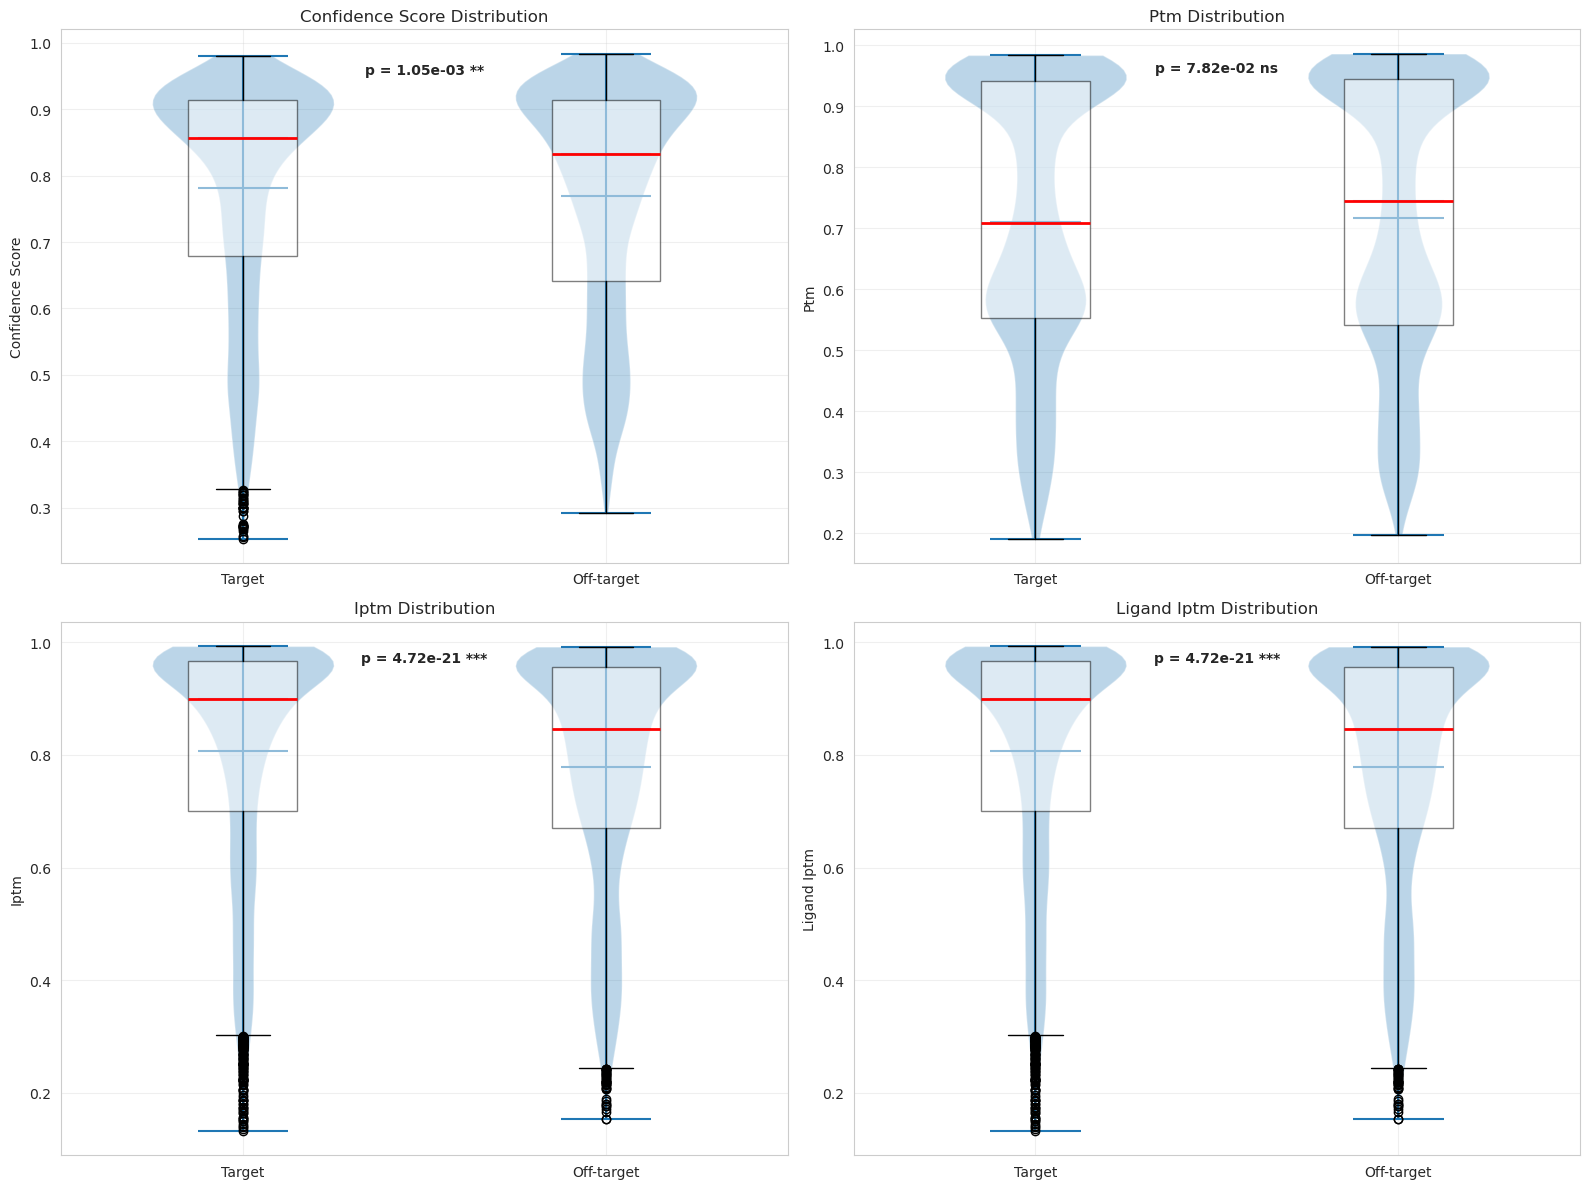

Confidence scores comparison violin plot saved: confidence_scores_comparison.png


In [211]:
confidence_metrics = ['confidence_score', 'ptm', 'iptm', 'ligand_iptm']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, metric in enumerate(confidence_metrics):
    ax = axes[idx]
    
    # Violin plot with box plot overlay
    parts = ax.violinplot(
        [df[df['target_type'] == 'tar'][metric].dropna(),
         df[df['target_type'] == 'off'][metric].dropna()],
        positions=[0, 1],
        showmeans=True,
        showmedians=True
    )
    
    # Box plot overlay
    bp = ax.boxplot(
        [df[df['target_type'] == 'tar'][metric].dropna(),
         df[df['target_type'] == 'off'][metric].dropna()],
        positions=[0, 1],
        widths=0.3,
        patch_artist=True,
        boxprops=dict(facecolor='white', alpha=0.5),
        medianprops=dict(color='red', linewidth=2)
    )
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Target', 'Off-target'])
    ax.set_ylabel(metric.replace('_', ' ').title())
    ax.set_title(f'{metric.replace("_", " ").title()} Distribution')
    ax.grid(True, alpha=0.3)
    
    # Add statistical annotation
    sig = stat_results[stat_results['Metric'] == metric]['Significant'].values[0]
    p_val = stat_results[stat_results['Metric'] == metric]['P-value'].values[0]
    ax.text(0.5, ax.get_ylim()[1] * 0.95, f'p = {p_val:.2e} {sig}', 
            ha='center', va='top', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(BOLTZ_EVAL_DIR / 'plots' / 'confidence_scores_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confidence scores comparison violin plot saved: confidence_scores_comparison.png")

### Quality Metrics

/tmp/ipykernel_39518/1115840478.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target_type', y=metric, ax=ax, palette='Set2')
/tmp/ipykernel_39518/1115840478.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target_type', y=metric, ax=ax, palette='Set2')
/tmp/ipykernel_39518/1115840478.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target_type', y=metric, ax=ax, palette='Set2')
/tmp/ipykernel_39518/1115840478.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and

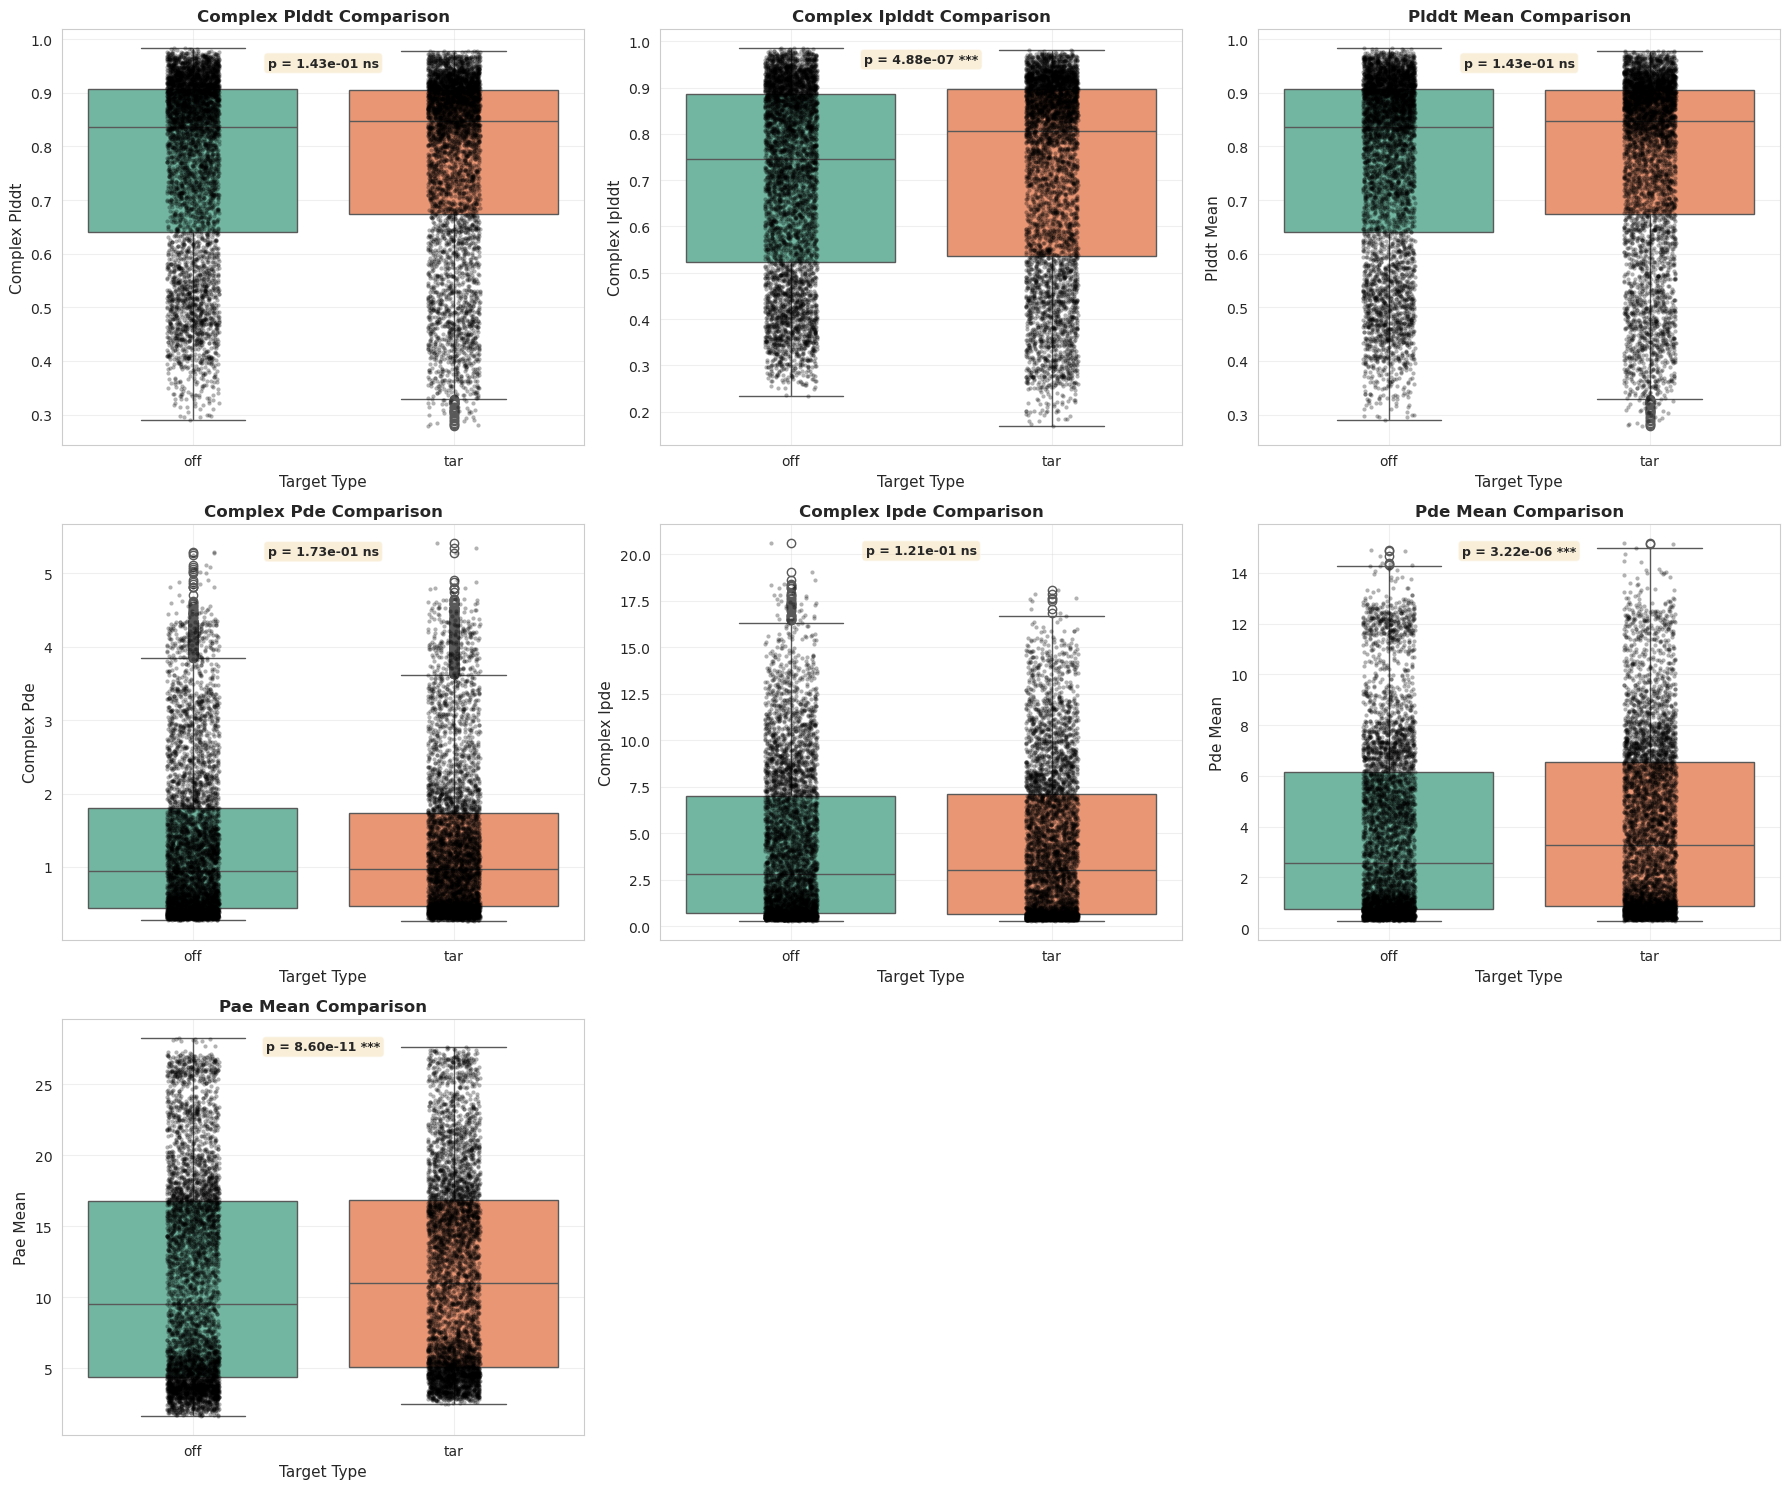

Quality metrics comparison plot saved: quality_metrics_comparison.png


In [212]:
quality_metrics = ['complex_plddt', 'complex_iplddt', 'plddt_mean', 
                   'complex_pde', 'complex_ipde', 'pde_mean', 'pae_mean']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for idx, metric in enumerate(quality_metrics):
    if idx < len(axes):
        ax = axes[idx]
        
        # Box plot with scatter overlay
        sns.boxplot(data=df, x='target_type', y=metric, ax=ax, palette='Set2')
        sns.stripplot(data=df, x='target_type', y=metric, ax=ax, 
                     color='black', alpha=0.3, size=3)
        
        ax.set_xlabel('Target Type', fontsize=11)
        ax.set_ylabel(metric.replace('_', ' ').title(), fontsize=11)
        ax.set_title(f'{metric.replace("_", " ").title()} Comparison', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Add statistical annotation
        sig = stat_results[stat_results['Metric'] == metric]['Significant'].values[0]
        p_val = stat_results[stat_results['Metric'] == metric]['P-value'].values[0]
        ax.text(0.5, ax.get_ylim()[1] * 0.95, f'p = {p_val:.2e} {sig}', 
                ha='center', va='top', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Remove extra subplots
for idx in range(len(quality_metrics), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig(BOLTZ_EVAL_DIR / 'plots' / 'quality_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Quality metrics comparison plot saved: quality_metrics_comparison.png")

### Binding Affinity

/tmp/ipykernel_39518/1322147978.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='target_type', y='affinity_pred_value', ax=ax, palette='muted')
/tmp/ipykernel_39518/1322147978.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='target_type', y='affinity_probability_binary', ax=ax, palette='muted')


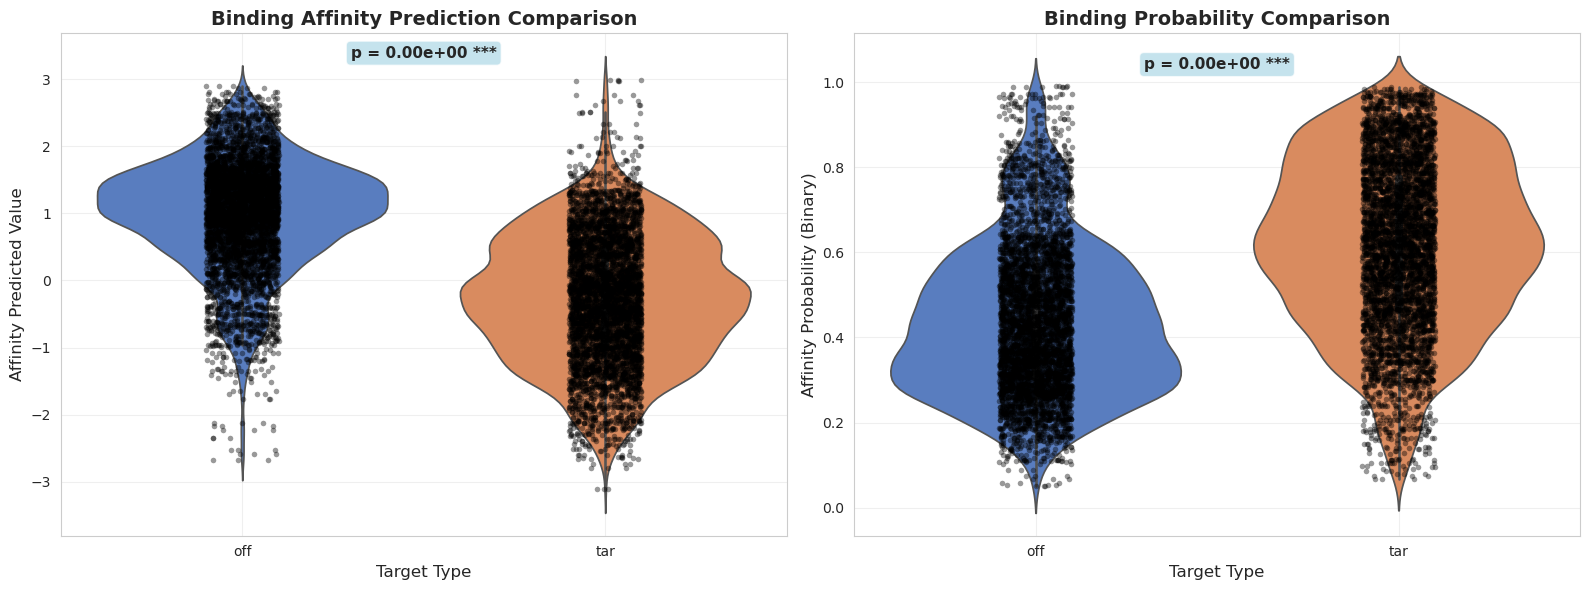

Binding affinity comparison plot saved: binding_affinity_comparison.png


In [213]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Affinity predicted value
ax = axes[0]
sns.violinplot(data=df, x='target_type', y='affinity_pred_value', ax=ax, palette='muted')
sns.stripplot(data=df, x='target_type', y='affinity_pred_value', ax=ax,
             color='black', alpha=0.4, size=4)
ax.set_xlabel('Target Type', fontsize=12)
ax.set_ylabel('Affinity Predicted Value', fontsize=12)
ax.set_title('Binding Affinity Prediction Comparison', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

sig = stat_results[stat_results['Metric'] == 'affinity_pred_value']['Significant'].values[0]
p_val = stat_results[stat_results['Metric'] == 'affinity_pred_value']['P-value'].values[0]
ax.text(0.5, ax.get_ylim()[1] * 0.95, f'p = {p_val:.2e} {sig}', 
        ha='center', va='top', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# Affinity probability (binary)
ax = axes[1]
sns.violinplot(data=df, x='target_type', y='affinity_probability_binary', ax=ax, palette='muted')
sns.stripplot(data=df, x='target_type', y='affinity_probability_binary', ax=ax,
             color='black', alpha=0.4, size=4)
ax.set_xlabel('Target Type', fontsize=12)
ax.set_ylabel('Affinity Probability (Binary)', fontsize=12)
ax.set_title('Binding Probability Comparison', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

sig = stat_results[stat_results['Metric'] == 'affinity_probability_binary']['Significant'].values[0]
p_val = stat_results[stat_results['Metric'] == 'affinity_probability_binary']['P-value'].values[0]
ax.text(0.5, ax.get_ylim()[1] * 0.95, f'p = {p_val:.2e} {sig}', 
        ha='center', va='top', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

plt.tight_layout()
plt.savefig(BOLTZ_EVAL_DIR / 'plots' / 'binding_affinity_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Binding affinity comparison plot saved: binding_affinity_comparison.png")

### Overall Metrics Heatmap

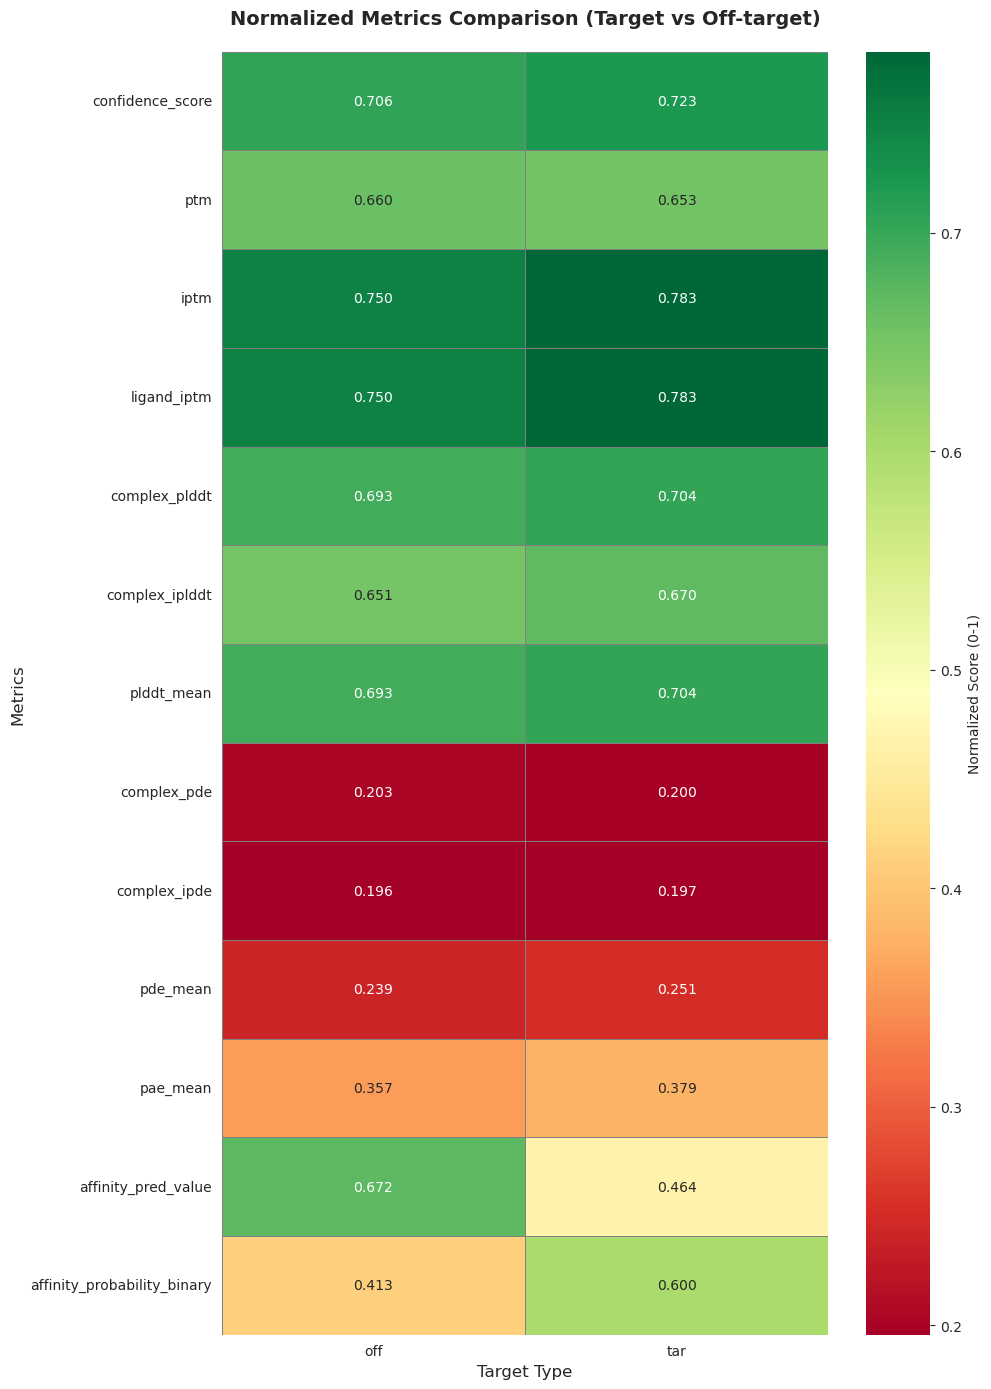

Metrics heatmap saved: metrics_heatmap.png


In [214]:
metrics_for_heatmap = ['confidence_score', 'ptm', 'iptm', 'ligand_iptm',
                       'complex_plddt', 'complex_iplddt', 'plddt_mean',
                       'complex_pde', 'complex_ipde', 'pde_mean', 'pae_mean',
                       'affinity_pred_value', 'affinity_probability_binary']

# Normalize metrics to 0-1 scale for better visualization
df_normalized = df.copy()
for metric in metrics_for_heatmap:
    min_val = df[metric].min()
    max_val = df[metric].max()
    if max_val > min_val:
        df_normalized[metric] = (df[metric] - min_val) / (max_val - min_val)

heatmap_data = df_normalized.groupby('target_type')[metrics_for_heatmap].mean().T

fig, ax = plt.subplots(figsize=(10, 14))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', 
            cbar_kws={'label': 'Normalized Score (0-1)'}, ax=ax,
            linewidths=0.5, linecolor='gray')
ax.set_title('Normalized Metrics Comparison (Target vs Off-target)', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Target Type', fontsize=12)
ax.set_ylabel('Metrics', fontsize=12)
plt.tight_layout()
plt.savefig(BOLTZ_EVAL_DIR / 'plots' / 'metrics_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Metrics heatmap saved: metrics_heatmap.png")

### Correlation Analysis

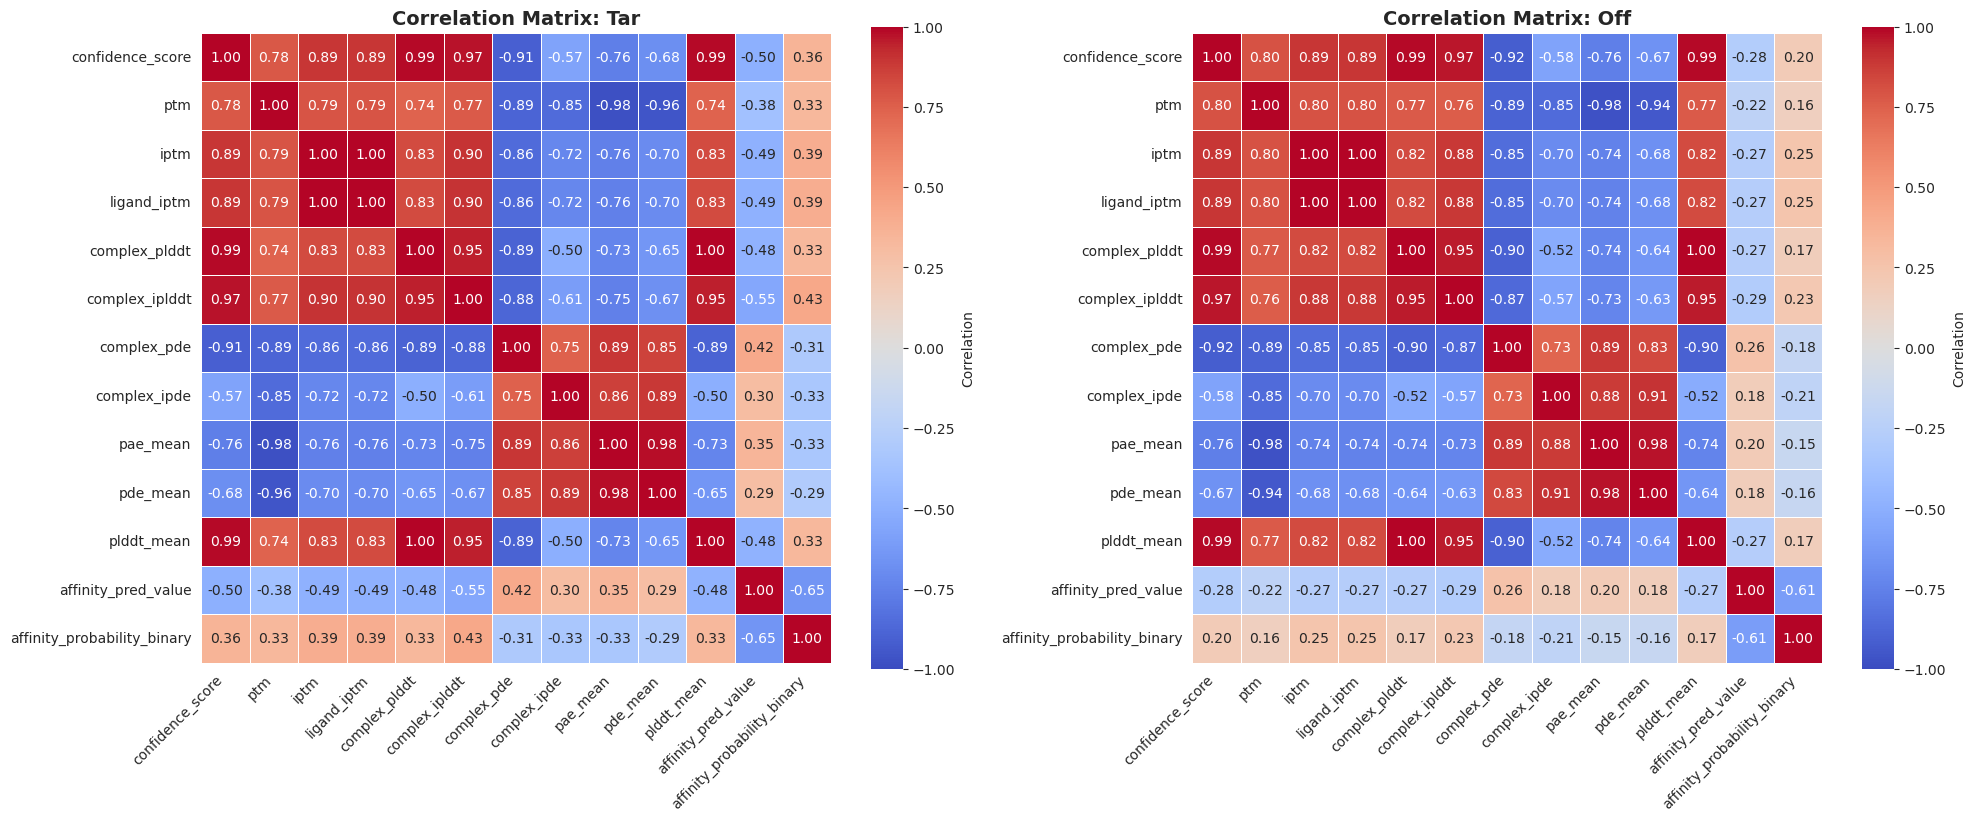

Correlation matrices saved: correlation_matrices.png


In [215]:
# Correlation matrix for target and off-target separately
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for idx, target_type in enumerate(['tar', 'off']):
    ax = axes[idx]
    subset = df[df['target_type'] == target_type][metrics]
    corr = subset.corr()
    
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, ax=ax, cbar_kws={'label': 'Correlation'},
                vmin=-1, vmax=1, linewidths=0.5)
    ax.set_title(f'Correlation Matrix: {target_type.title()}', fontsize=14, fontweight='bold')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    plt.setp(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(BOLTZ_EVAL_DIR / 'plots' / 'correlation_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("Correlation matrices saved: correlation_matrices.png")

### Scatter Plots

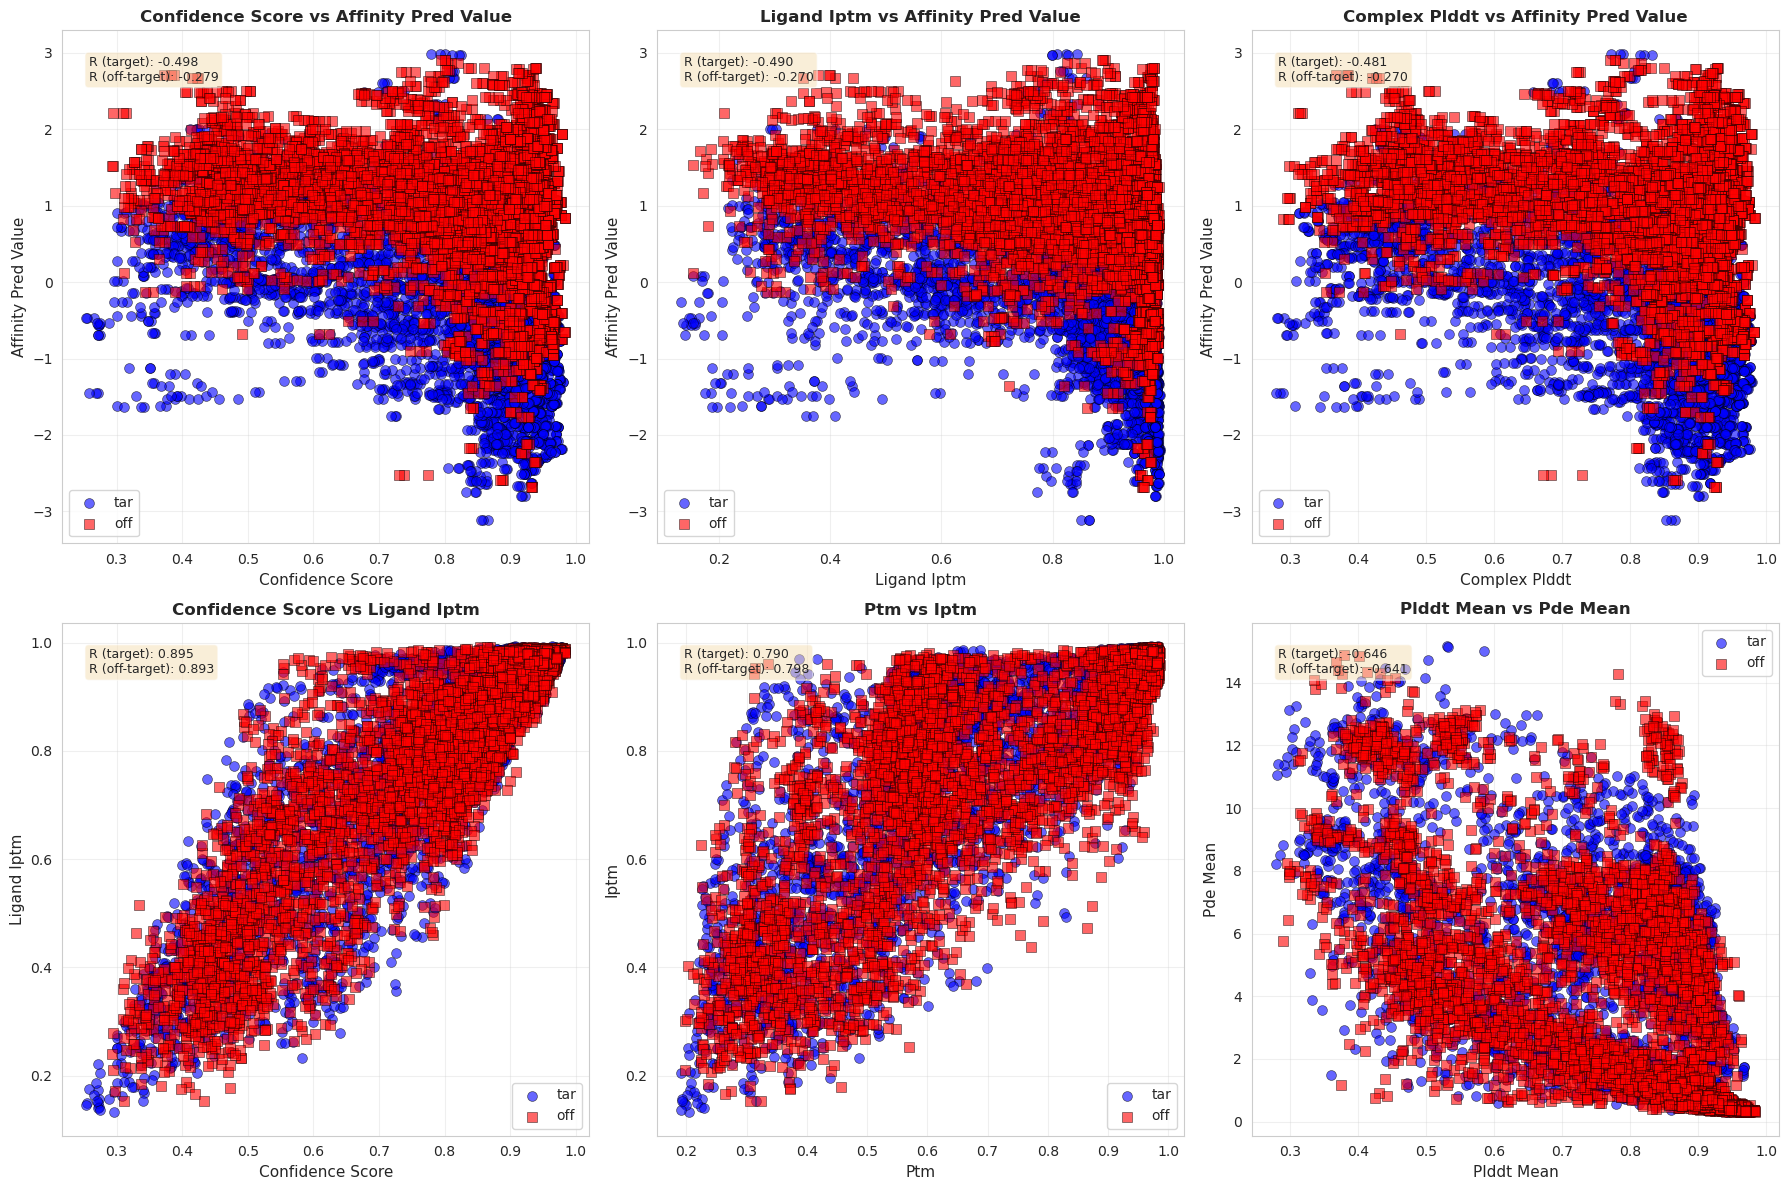

Major relationship scatter plots saved: scatter_relationships.png


In [216]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

scatter_pairs = [
    ('confidence_score', 'affinity_pred_value'),
    ('ligand_iptm', 'affinity_pred_value'),
    ('complex_plddt', 'affinity_pred_value'),
    ('confidence_score', 'ligand_iptm'),
    ('ptm', 'iptm'),
    ('plddt_mean', 'pde_mean')
]

for idx, (x_metric, y_metric) in enumerate(scatter_pairs):
    ax = axes[idx]
    
    for target_type, color, marker in [('tar', 'blue', 'o'), ('off', 'red', 's')]:
        subset = df[df['target_type'] == target_type]
        ax.scatter(subset[x_metric], subset[y_metric], 
                  alpha=0.6, s=50, c=color, marker=marker, label=target_type,
                  edgecolors='black', linewidth=0.5)
    
    ax.set_xlabel(x_metric.replace('_', ' ').title(), fontsize=11)
    ax.set_ylabel(y_metric.replace('_', ' ').title(), fontsize=11)
    ax.set_title(f'{x_metric.replace("_", " ").title()} vs {y_metric.replace("_", " ").title()}', 
                fontsize=12, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    # Add correlation coefficient
    corr_target = df[df['target_type'] == 'tar'][[x_metric, y_metric]].corr().iloc[0, 1]
    corr_off = df[df['target_type'] == 'off'][[x_metric, y_metric]].corr().iloc[0, 1]
    ax.text(0.05, 0.95, f'R (target): {corr_target:.3f}\nR (off-target): {corr_off:.3f}',
           transform=ax.transAxes, fontsize=9, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(BOLTZ_EVAL_DIR / 'plots' / 'scatter_relationships.png', dpi=300, bbox_inches='tight')
plt.show()

print("Major relationship scatter plots saved: scatter_relationships.png")

### Distribution Plots for All Metrics

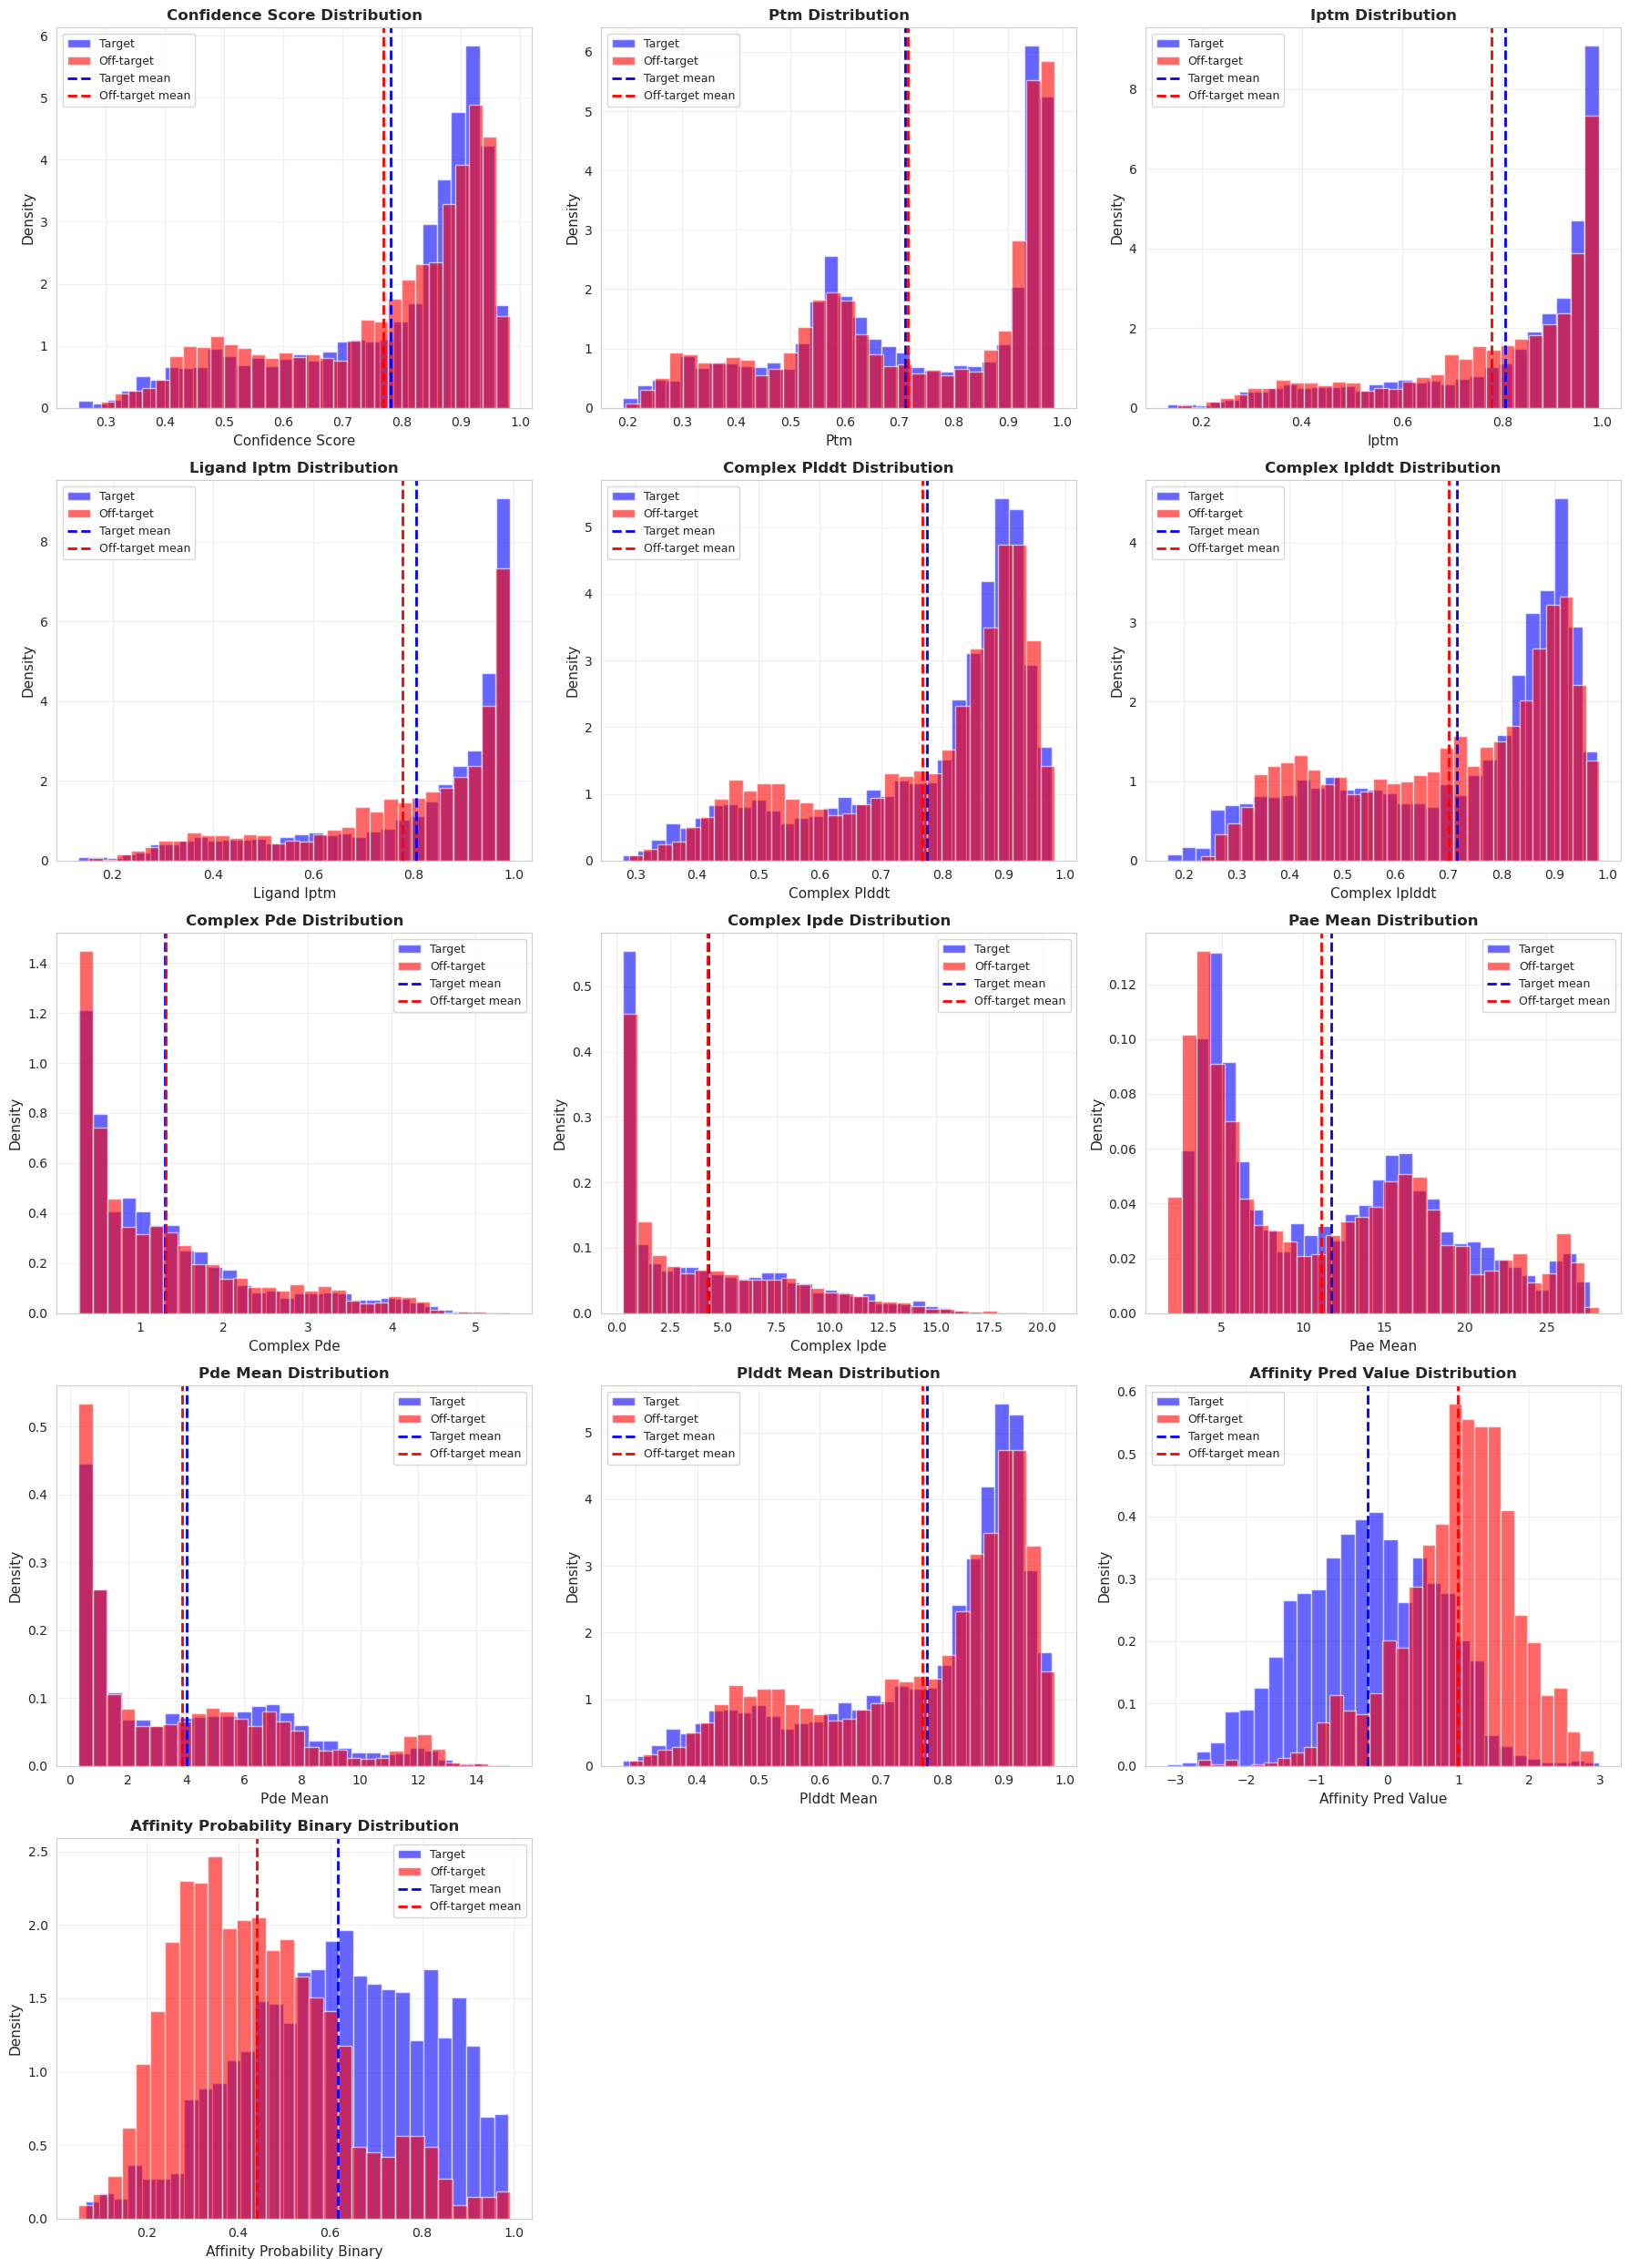

All metrics distribution plots saved: distributions_all_metrics.png


In [217]:
# Distribution comparison for all metrics
n_metrics = len(metrics)
n_cols = 3
n_rows = (n_metrics + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    if idx < len(axes):
        ax = axes[idx]
        
        target_data = df[df['target_type'] == 'tar'][metric].dropna()
        offtarget_data = df[df['target_type'] == 'off'][metric].dropna()
        
        ax.hist(target_data, bins=30, alpha=0.6, label='Target', color='blue', density=True)
        ax.hist(offtarget_data, bins=30, alpha=0.6, label='Off-target', color='red', density=True)
        
        ax.axvline(target_data.mean(), color='blue', linestyle='--', linewidth=2, label='Target mean')
        ax.axvline(offtarget_data.mean(), color='red', linestyle='--', linewidth=2, label='Off-target mean')
        
        ax.set_xlabel(metric.replace('_', ' ').title(), fontsize=11)
        ax.set_ylabel('Density', fontsize=11)
        ax.set_title(f'{metric.replace("_", " ").title()} Distribution', fontsize=12, fontweight='bold')
        ax.legend(loc='best', fontsize=9)
        ax.grid(True, alpha=0.3)

# Remove extra subplots
for idx in range(len(metrics), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig(BOLTZ_EVAL_DIR / 'plots' / 'distributions_all_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("All metrics distribution plots saved: distributions_all_metrics.png")

### ROC-curve Analysis

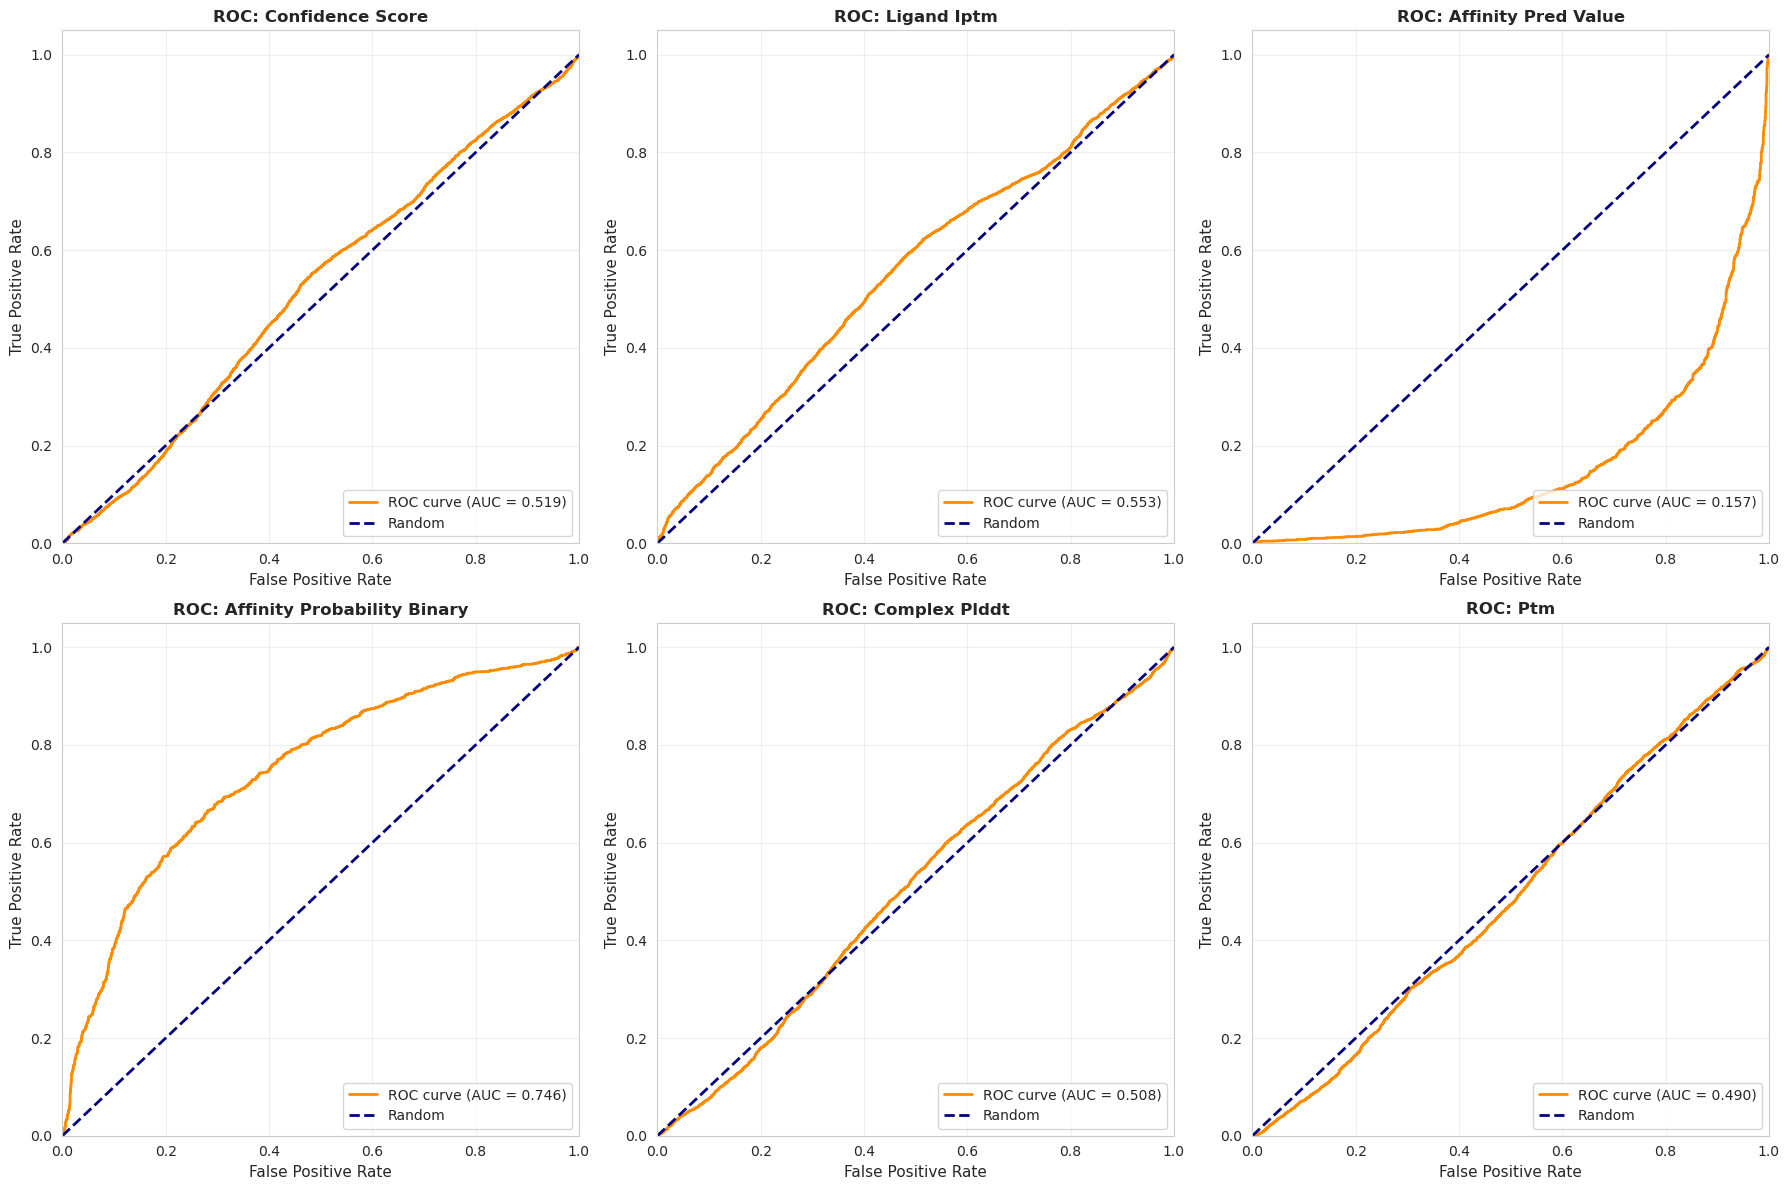


ROC-AUC Scores (Sorted):
                        Metric       AUC
3  affinity_probability_binary  0.745783
1                  ligand_iptm  0.553446
0             confidence_score  0.518595
4                complex_plddt  0.508319
5                          ptm  0.490002
2          affinity_pred_value  0.157072

ROC curves saved: roc_curves.png


In [218]:
# ROC curves for different metrics as classifiers
# Convert target_type to binary (1 for target, 0 for off-target)
df['target_binary'] = (df['target_type'] == 'tar').astype(int)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

roc_metrics = ['confidence_score', 'ligand_iptm', 'affinity_pred_value', 
               'affinity_probability_binary', 'complex_plddt', 'ptm']

roc_results = []

for idx, metric in enumerate(roc_metrics):
    if idx < len(axes):
        ax = axes[idx]
        
        # Remove NaN values
        mask = ~df[metric].isna()
        y_true = df[mask]['target_binary']
        y_score = df[mask][metric]
        
        # Calculate ROC curve
        fpr, tpr, thresholds = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)
        
        # Plot ROC curve
        ax.plot(fpr, tpr, color='darkorange', lw=2, 
               label=f'ROC curve (AUC = {roc_auc:.3f})')
        ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('False Positive Rate', fontsize=11)
        ax.set_ylabel('True Positive Rate', fontsize=11)
        ax.set_title(f'ROC: {metric.replace("_", " ").title()}', fontsize=12, fontweight='bold')
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.3)
        
        roc_results.append({
            'Metric': metric,
            'AUC': roc_auc
        })

plt.tight_layout()
plt.savefig(BOLTZ_EVAL_DIR / 'plots' / 'roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

roc_results_df = pd.DataFrame(roc_results).sort_values('AUC', ascending=False)
print("\nROC-AUC Scores (Sorted):")
print(roc_results_df)

print("\nROC curves saved: roc_curves.png")

## Structure RMSD & ligRMSD

### Helper Functions

In [69]:
# BioPython for PDB parsing and alignment
from Bio import PDB, pairwise2
from Bio.PDB import PDBParser, Selection
from Bio.Seq import Seq
from Bio.PDB.Polypeptide import PPBuilder
from Bio.PDB import Superimposer
import yaml

three_to_one = {
    "ALA": "A", "CYS": "C", "ASP": "D", "GLU": "E", "PHE": "F",
    "GLY": "G", "HIS": "H", "ILE": "I", "LYS": "K", "LEU": "L",
    "MET": "M", "ASN": "N", "PRO": "P", "GLN": "Q", "ARG": "R",
    "SER": "S", "THR": "T", "VAL": "V", "TRP": "W", "TYR": "Y",
    "SEC": "U", "PYL": "O",
}

def extract_chain_ca_and_seq(structure, chain_id):
    ca_atoms = []
    seq = []

    for model in structure:
        for chain in model:
            if chain.id != chain_id:
                continue
            for residue in chain:
                if residue.id[0] != ' ':
                    continue
                if residue.resname not in three_to_one:
                    continue
                if 'CA' not in residue:
                    continue

                seq.append(three_to_one[residue.resname])
                ca_atoms.append(residue['CA'])
        break
    return ''.join(seq), ca_atoms


# Complex RMSD calculation helpers
def align_ca_by_sequence(ref_seq, ref_ca, pred_seq, pred_ca):
    aln = pairwise2.align.globalxx(ref_seq, pred_seq, one_alignment_only=True)[0]

    ref_aln, pred_aln = aln.seqA, aln.seqB

    ref_idx = pred_idx = 0
    ref_atoms = []
    pred_atoms = []

    for r, p in zip(ref_aln, pred_aln):
        if r != '-' and p != '-':
            ref_atoms.append(ref_ca[ref_idx])
            pred_atoms.append(pred_ca[pred_idx])
        if r != '-':
            ref_idx += 1
        if p != '-':
            pred_idx += 1

    return ref_atoms, pred_atoms

def find_best_matching_chain(pdb_path: str, reference_seq: str) -> Tuple[str, str]:
    """
    Find the chain in PDB that best matches the reference sequence.
    
    Returns:
        tuple: (chain_id, chain_sequence)
    """
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure('protein', pdb_path)
    # print("Reference sequence length:", len(reference_seq))

    best_chain_id = None
    best_chain_seq = ""
    best_score = -1
    
    for model in structure:
        for chain in model:
            seq = []
            for residue in chain:
                if residue.id[0] == ' ':
                    try:
                        seq.append(three_to_one[residue.resname])
                    except:
                        pass
            
            if not seq:
                continue
            
            chain_seq = ''.join(seq)
            
            # Calculate alignment score
            alignments = pairwise2.align.globalxx(reference_seq, chain_seq)
            # print("Checking chain", chain.id, "length", len(chain_seq))
            if alignments:
                score = alignments[0].score
                if score > best_score:
                    best_score = score
                    best_chain_id = chain.id
                    best_chain_seq = chain_seq
        break
    
    # print("Best chain:", best_chain_id, "score:", best_score)
    return best_chain_id, best_chain_seq


# Ligand RMSD calculation helpers
def get_ligand_heavy_atoms(structure, resname):
    atoms = []
    for model in structure:
        for chain in model:
            for residue in chain:
                if residue.resname == resname:
                    for atom in residue:
                        elem = (atom.element or "").strip().upper()
                        if elem == "H":
                            continue
                        altloc = atom.get_altloc()
                        if altloc not in (" ", "A"):
                            continue
                        atoms.append(atom)
        break
    return atoms


def atom_elem(atom):
    e = (atom.element or "").strip().upper()
    if e:
        return e
    name = atom.get_name().strip()
    if len(name) >= 2 and name[:2].upper() in {"CL","BR","NA","CA","MG","ZN","FE","MN","CU"}:
        return name[:2].upper()
    return name[0].upper()


def rmsd_with_hungarian_by_element(ref_atoms, pred_atoms):
    from scipy.optimize import linear_sum_assignment

    def group(atoms):
        d = {}
        for a in atoms:
            d.setdefault(atom_elem(a), []).append(a)
        return d

    rg = group(ref_atoms)
    pg = group(pred_atoms)
    if set(rg.keys()) != set(pg.keys()):
        return None

    diffs = []
    for elem in rg:
        r = rg[elem]; p = pg[elem]
        if len(r) != len(p):
            return None

        R = np.array([a.coord for a in r])
        P = np.array([a.coord for a in p])
        cost = ((R[:, None, :] - P[None, :, :])**2).sum(axis=2)
        ri, ci = linear_sum_assignment(cost)
        diffs.append(R[ri] - P[ci])

    D = np.vstack(diffs)
    return float(np.sqrt(np.mean(np.sum(D**2, axis=1))))


def calculate_protein_rmsd(input_pdb_path, output_pdb_path, reference_seq):
    parser = PDBParser(QUIET=True)

    ref_struct = parser.get_structure('ref', input_pdb_path)
    pred_struct = parser.get_structure('pred', output_pdb_path)

    # best chain in reference
    ref_chain_id, _ = find_best_matching_chain(output_pdb_path, reference_seq)
    if not ref_chain_id:
        print("No matching chain found in reference structure.")
        return None
    
    # best chain in prediction
    pred_chain_id, _ = find_best_matching_chain(output_pdb_path, reference_seq)
    if not pred_chain_id:
        print("No matching chain found in predicted structure.")
        return None
    
    # extract CA and sequences
    ref_chain_seq, ref_ca = extract_chain_ca_and_seq(ref_struct, ref_chain_id)
    pred_chain_seq, pred_ca = extract_chain_ca_and_seq(pred_struct, pred_chain_id)

    # sequence-based CA mapping
    ref_atoms, pred_atoms = align_ca_by_sequence(
        ref_chain_seq, ref_ca, 
        pred_chain_seq, pred_ca
    )

    # print("Aligned CA:", len(ref_atoms))

    if len(ref_atoms) < 10:
        return None
    
    sup = Superimposer()
    sup.set_atoms(ref_atoms, pred_atoms)

    return sup.rms

def calculate_ligand_rmsd(ref_pdb, pred_pdb, ligand_ccd, reference_seq,
                                 pred_lig_resname="LIG"):
    parser = PDBParser(QUIET=True)
    ref_struct = parser.get_structure("ref", ref_pdb)
    pred_struct = parser.get_structure("pred", pred_pdb)

    # 1) Chain selection based on sequence (chain ID doesn't matter)
    ref_chain_id, _  = find_best_matching_chain(ref_pdb, reference_seq)
    pred_chain_id, _ = find_best_matching_chain(pred_pdb, reference_seq)
    if not ref_chain_id or not pred_chain_id:
        return None

    # 2) Align by sequence-based Ca mapping
    ref_chain_seq, ref_ca = extract_chain_ca_and_seq(ref_struct, ref_chain_id)
    pred_chain_seq, pred_ca = extract_chain_ca_and_seq(pred_struct, pred_chain_id)

    ref_atoms, pred_atoms = align_ca_by_sequence(ref_chain_seq, ref_ca, pred_chain_seq, pred_ca)
    if len(ref_atoms) < 10:
        return None

    # Apply transformation to the entire predicted structure (protein + ligand) to the reference frame
    sup = Superimposer()
    sup.set_atoms(ref_atoms, pred_atoms)
    sup.apply(pred_struct.get_atoms())

    # 3) Extract Ligands (ref: CCD, pred: LIG)
    ref_lig = get_ligand_heavy_atoms(ref_struct, ligand_ccd)
    pred_lig = get_ligand_heavy_atoms(pred_struct, pred_lig_resname)

    if len(pred_lig) == 0:
        pred_lig = get_ligand_heavy_atoms(pred_struct, ligand_ccd)

    if len(ref_lig) == 0 or len(pred_lig) == 0:
        return None
    if len(ref_lig) != len(pred_lig):
        return None

    # print("protein aligned CA:", len(ref_atoms))
    # print("lig centroid dist:", np.linalg.norm(
    # np.mean([a.coord for a in ref_lig], axis=0) - np.mean([a.coord for a in pred_lig], axis=0)
    # ))

    # 4) Hungarian matching for RMSD (since atom names may not match)
    return rmsd_with_hungarian_by_element(ref_lig, pred_lig)


def parse_complex_name(complex_name: str) -> Dict[str, str]:
    """
    Parse complex name into components.
    Format: <uniprot_id>_<target_type>_<ligand_id>_seq<XX>
    Example: O60674_tar_2TA_seq00
    """
    parts = complex_name.split('_')
    return {
        'uniprot_id': parts[0],
        'target_type': parts[1],  # 'tar' or 'off'
        'ligand_id': parts[2],
        'seq_id': parts[3] if len(parts) > 3 else 'seq00'
    }


def load_reference_sequence(yaml_path: str) -> Tuple[str, str]:
    """
    Load reference protein sequence and ligand CCD from YAML file.
    
    Returns:
        tuple: (protein_sequence, ligand_ccd)
    """
    with open(yaml_path, 'r') as f:
        data = yaml.safe_load(f)
    
    protein_seq = None
    ligand_ccd = None
    
    for item in data['sequences']:
        if 'protein' in item:
            protein_seq = item['protein']['sequence']
        if 'ligand' in item:
            ligand_ccd = item['ligand']['ccd']
    
    return protein_seq, ligand_ccd


### RMSD Data Collection

In [70]:
def proceed_rmsd(lmpnn_output_dir, boltz_output_dir, boltz_input_dir, assay_type):
    print("Calculating RMSD...")
    print(f"  LigandMPNN output dir: {lmpnn_output_dir}")
    print(f"  Boltz output dir: {boltz_output_dir}")
    print(f"  Boltz input dir: {boltz_input_dir}")
    print(f"  Assay type: {assay_type}\n")

    rmsd_results = []
    boltz_dirs = sorted(glob.glob(os.path.join(boltz_output_dir, "boltz_results_*")))

    for boltz_dir in tqdm(boltz_dirs, desc=f"Processing {assay_type} Boltz directories", unit="complex"):
        dir_name = os.path.basename(boltz_dir)
        complex_name = dir_name.replace('boltz_results_', '')
        info = parse_complex_name(complex_name)
        
        uniprot_id = info['uniprot_id']
        target_type = info['target_type']
        ligand_id = info['ligand_id']
        seq_id = info['seq_id']
        
        # Paths
        yaml_path = os.path.join(boltz_input_dir, f"{complex_name}.yaml")
        predictions_dir = os.path.join(boltz_dir, "predictions", complex_name)
        
        if not os.path.exists(yaml_path) or not os.path.exists(predictions_dir):
            continue
        
        try:
            reference_seq, ligand_ccd = load_reference_sequence(yaml_path)
            if not reference_seq:
                continue
        except:
            print("Failed to load YAML for", complex_name)
            continue
        
        # Input PDB
        # packed pdbs: <uniprot_id>/<target_type>/<ligand_het_id>/packed/<pdb_id>_packed_[1-10]_1.pdb
        seq_idx = int(seq_id.replace('seq', '')) + 1  # e.g., 'seq00' -> '00'
        input_pdb_pattern = os.path.join(
            lmpnn_output_dir, 
            uniprot_id, target_type, ligand_id, 
            'packed', 
            f"*_packed_{seq_idx}_1.pdb"
        )
        input_pdbs = glob.glob(input_pdb_pattern)
        
        if not input_pdbs:
            print("No input PDB found for", complex_name)
            continue
        
        input_pdb_path = input_pdbs[0]
        
        # Process each model
        model_protein_rmsds = []
        model_ligand_rmsds = []


        for model_idx in [0, 1, 2]:
            model_pdb_pattern = os.path.join(predictions_dir, f"*_model_{model_idx}.pdb")
            model_pdbs = glob.glob(model_pdb_pattern)
            if not model_pdbs:
                continue
            
            model_pdb_path = model_pdbs[0]
            try:
                # Calculate protein RMSD
                protein_rmsd = calculate_protein_rmsd(input_pdb_path, model_pdb_path, reference_seq)
                if protein_rmsd is not None:
                    model_protein_rmsds.append(protein_rmsd)
                
                # Calculate ligand RMSD
                ligand_rmsd = calculate_ligand_rmsd(input_pdb_path, model_pdb_path, ligand_ccd, reference_seq)
                if ligand_rmsd is not None:
                    model_ligand_rmsds.append(ligand_rmsd)
            
            except Exception as e:
                continue
    
        # Store results
        if model_protein_rmsds:
            rmsd_results.append({
                'complex_name': complex_name,
                'uniprot_id': uniprot_id,
                'target_type': target_type,
                'ligand_id': ligand_id,
                'seq_id': seq_id,
                'assay_type': assay_type,
                'protein_rmsd': np.mean(model_protein_rmsds),
                'protein_rmsd_std': np.std(model_protein_rmsds) if len(model_protein_rmsds) > 1 else 0.0,
                'ligand_rmsd': np.mean(model_ligand_rmsds) if model_ligand_rmsds else None,
                'ligand_rmsd_std': np.std(model_ligand_rmsds) if len(model_ligand_rmsds) > 1 else 0.0,
                'n_models': len(model_protein_rmsds)
            })

    # Convert to DataFrame
    return pd.DataFrame(rmsd_results)

rmsd_results_Kd = proceed_rmsd(LMPNN_OUTDIR_KD, BOLTZ_OUTPUT_DIR_KD, BOLTZ_INPUT_DIR_KD, 'Kd')
rmsd_results_IC50 = proceed_rmsd(LMPNN_OUTDIR_IC50, BOLTZ_OUTPUT_DIR_IC50, BOLTZ_INPUT_DIR_IC50, 'IC50')

# Combine results
rmsd_df = pd.concat([rmsd_results_Kd, rmsd_results_IC50], ignore_index=True)

dup_key = rmsd_df.duplicated(subset=["complex_name"]).sum()
print("# of duplicated complexes:", dup_key)

print(f"\n✓ RMSD calculation complete!")
print(f"  - Complexes with protein RMSD: {len(rmsd_df)}")
print(f"  - Complexes with ligand RMSD: {rmsd_df['ligand_rmsd'].notna().sum()}")

rmsd_csv_path = os.path.join(BOLTZ_EVAL_DIR, 'rmsd_summary.csv')
rmsd_df.to_csv(rmsd_csv_path, index=False)
print(f"RMSD results saved to {rmsd_csv_path}")

rmsd_df.head(10)

Calculating RMSD...
  LigandMPNN output dir: /scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/lmpnn_out
  Boltz output dir: /scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/boltz2/outputs
  Boltz input dir: /scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/boltz2/inputs
  Assay type: Kd



Processing Kd Boltz directories: 100%|██████████| 890/890 [10:22<00:00,  1.43complex/s]


Calculating RMSD...
  LigandMPNN output dir: /scratch/yunmin/data/graph/lmpnn/bdb_pdb/IC50/lmpnn_out
  Boltz output dir: /scratch/yunmin/data/graph/lmpnn/bdb_pdb/IC50/boltz2/outputs
  Boltz input dir: /scratch/yunmin/data/graph/lmpnn/bdb_pdb/IC50/boltz2/inputs
  Assay type: IC50



Processing IC50 Boltz directories: 100%|██████████| 2650/2650 [33:21<00:00,  1.32complex/s] 

# of duplicated complexes: 90

✓ RMSD calculation complete!
  - Complexes with protein RMSD: 3450
  - Complexes with ligand RMSD: 2200
RMSD results saved to /scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/boltz2/eval/rmsd_summary.csv


,complex_name,uniprot_id,target_type,ligand_id,seq_id,assay_type,protein_rmsd,protein_rmsd_std,ligand_rmsd,ligand_rmsd_std,n_models
0,O60674_off_8MY_seq00,O60674,off,8MY,seq00,Kd,1.230771,0.035290,4.144831,0.087635,3
1,O60674_off_8MY_seq01,O60674,off,8MY,seq01,Kd,1.351677,0.060950,1.130190,0.074191,3
2,O60674_off_8MY_seq02,O60674,off,8MY,seq02,Kd,1.778461,0.061906,4.797635,0.030969,3
3,O60674_off_8MY_seq03,O60674,off,8MY,seq03,Kd,1.864004,0.284329,4.504935,0.078178,3
4,O60674_off_8MY_seq04,O60674,off,8MY,seq04,Kd,1.752725,0.101064,1.580858,0.068738,3
5,O60674_off_8MY_seq05,O60674,off,8MY,seq05,Kd,1.251281,0.040484,3.826611,0.170512,3
6,O60674_off_8MY_seq06,O60674,off,8MY,seq06,Kd,1.646966,0.107276,1.608338,0.317627,3
7,O60674_off_8MY_seq07,O60674,off,8MY,seq07,Kd,1.172749,0.075105,3.905093,0.017729,3
8,O60674_off_8MY_seq08,O60674,off,8MY,seq08,Kd,1.447496,0.086983,0.967317,0.319193,3
9,O60674_off_8MY_seq09,O60674,off,8MY,seq09,Kd,2.841710,0.953525,1.230768,0.148275,3


### Aggregate RMSD by Protein-Ligand

In [71]:
rmsd_agg_df = rmsd_df.groupby(['uniprot_id', 'target_type', 'ligand_id']).agg({
    'protein_rmsd': ['mean', 'std'],
    'ligand_rmsd': ['mean', 'std'],
    'complex_name': 'count'
}).reset_index()

rmsd_agg_df.columns = ['_'.join(col).strip('_') for col in rmsd_agg_df.columns.values]
rmsd_agg_df.rename(columns={'complex_name_count': 'n_sequences'}, inplace=True)

print(f"Aggregated RMSD: {len(rmsd_agg_df)} protein-ligand combinations")
print(f"\nSummary:")
print(rmsd_agg_df.groupby('target_type')[['protein_rmsd_mean', 'ligand_rmsd_mean']].describe())

rmsd_agg_csv_path = os.path.join(BOLTZ_EVAL_DIR, 'rmsd_aggregated_summary.csv')
rmsd_agg_df.to_csv(rmsd_agg_csv_path, index=False)
print(f"Aggregated RMSD results saved to {rmsd_agg_csv_path}")

rmsd_agg_df.head(10)

Aggregated RMSD: 336 protein-ligand combinations

Summary:
            protein_rmsd_mean                                         \
                        count      mean       std      min       25%   
target_type                                                            
off                     172.0  6.917193  6.780527  0.61205  2.153529   
tar                     164.0  6.760287  6.760781  0.65298  2.017548   

                                           ligand_rmsd_mean            \
                  50%       75%        max            count      mean   
target_type                                                             
off          4.055137  9.658662  30.069888            122.0  8.389859   
tar          3.812899  9.843657  29.616409             93.0  5.479282   

                                                                           
                   std       min       25%       50%       75%        max  
target_type                                                   

,uniprot_id,target_type,ligand_id,protein_rmsd_mean,protein_rmsd_std,ligand_rmsd_mean,ligand_rmsd_std,n_sequences
0,O14757,off,HK6,4.950099,1.601935,2.591343,1.193411,10
1,O14757,off,XEZ,2.731171,1.445687,1.294788,0.401491,10
2,O14757,off,ZYR,2.201200,0.523627,0.754384,0.231221,10
3,O14757,tar,306,4.528255,0.605040,1.395850,0.286962,10
4,O14757,tar,S25,4.656157,0.866807,1.700793,0.425029,10
5,O14757,tar,YEX,2.031251,0.306304,0.715672,0.174184,10
6,O15530,off,63L,2.649314,1.466750,1.995093,1.083318,10
7,O15530,off,P47,1.165765,0.183288,1.315409,0.371051,10
8,O15530,tar,3Q3,2.325799,0.295827,4.372393,2.122045,10
9,O15530,tar,8H1,3.493461,1.729652,1.373310,1.262367,10


### Visualization: RMSD Comparison

Protein RMSD & Ligand RMSD tar vs. off Boxplots

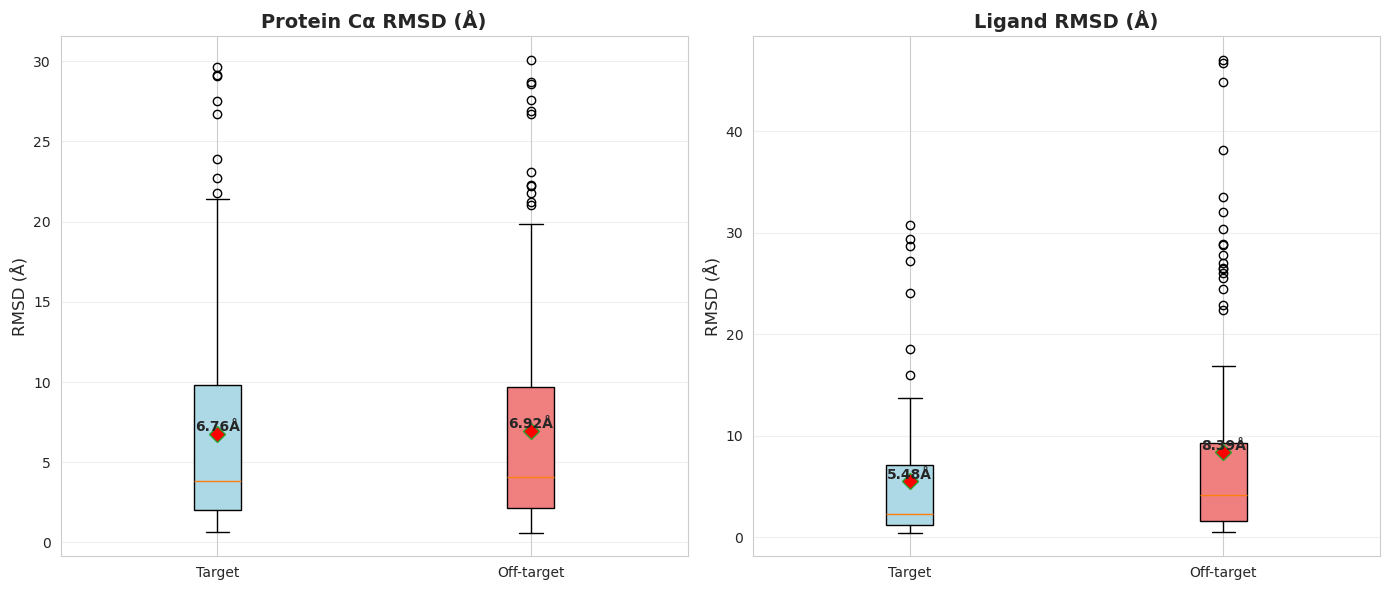

RMSD comparison boxplot saved at  /scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/eval/plots/rmsd_comparison_boxplot.png


In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

rmsd_types = [
    ('protein_rmsd_mean', 'Protein Cα RMSD (Å)'),
    ('ligand_rmsd_mean', 'Ligand RMSD (Å)')
]

for idx, (col, title) in enumerate(rmsd_types):
    ax = axes[idx]
    
    # Prepare data
    tar_data = rmsd_agg_df[rmsd_agg_df['target_type'] == 'tar'][col].dropna()
    off_data = rmsd_agg_df[rmsd_agg_df['target_type'] == 'off'][col].dropna()
    
    bp = ax.boxplot(
        [tar_data, off_data],
        tick_labels=['Target', 'Off-target'],
        patch_artist=True,
        showmeans=True,
        meanprops=dict(marker='D', markerfacecolor='red', markersize=8)
    )
    
    colors = ['lightblue', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax.set_ylabel('RMSD (Å)', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Add mean values
    if len(tar_data) > 0:
        tar_mean = tar_data.mean()
        ax.text(1, tar_mean + 0.2, f'{tar_mean:.2f}Å', ha='center', fontsize=10, fontweight='bold')
    if len(off_data) > 0:
        off_mean = off_data.mean()
        ax.text(2, off_mean + 0.2, f'{off_mean:.2f}Å', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
rmsd_plot_path = OUTPUT_PLOTS_DIR / 'rmsd_comparison_boxplot.png'
plt.savefig(rmsd_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print("RMSD comparison boxplot saved at ", rmsd_plot_path)

Scatter plots

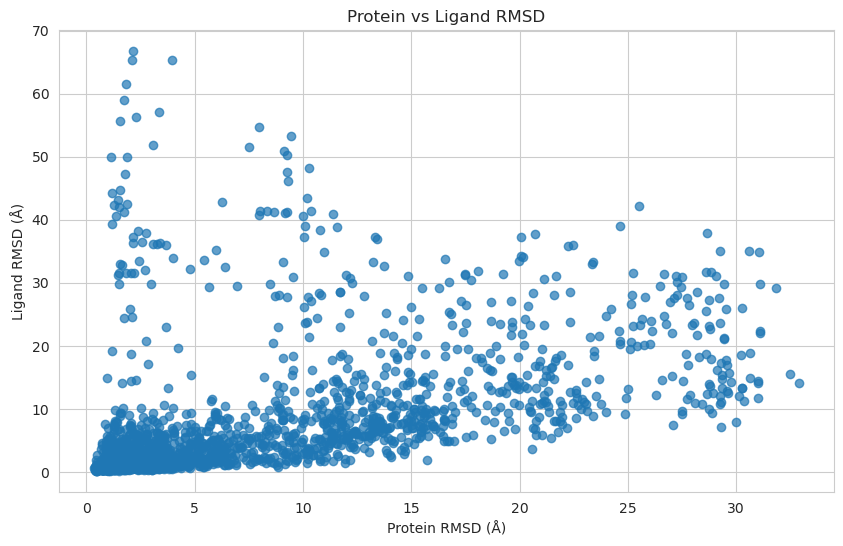

<Figure size 1200x600 with 0 Axes>

RMSD comparison scatterplot saved at  /scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/eval/plots/rmsd_scatter.png


In [83]:
import matplotlib.pyplot as plt

plot_df = rmsd_df.dropna(subset=["protein_rmsd", "ligand_rmsd"]).copy()

plt.figure(figsize=(10, 6))
plt.scatter(plot_df["protein_rmsd"], plot_df["ligand_rmsd"], alpha=0.7)
plt.xlabel("Protein RMSD (Å)")
plt.ylabel("Ligand RMSD (Å)")
plt.title("Protein vs Ligand RMSD")
plt.show()

rmsd_plot_path = OUTPUT_PLOTS_DIR / 'rmsd_scatter.png'
plt.savefig(rmsd_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print("RMSD comparison scatterplot saved at ", rmsd_plot_path)


Assay-wise scatter plots

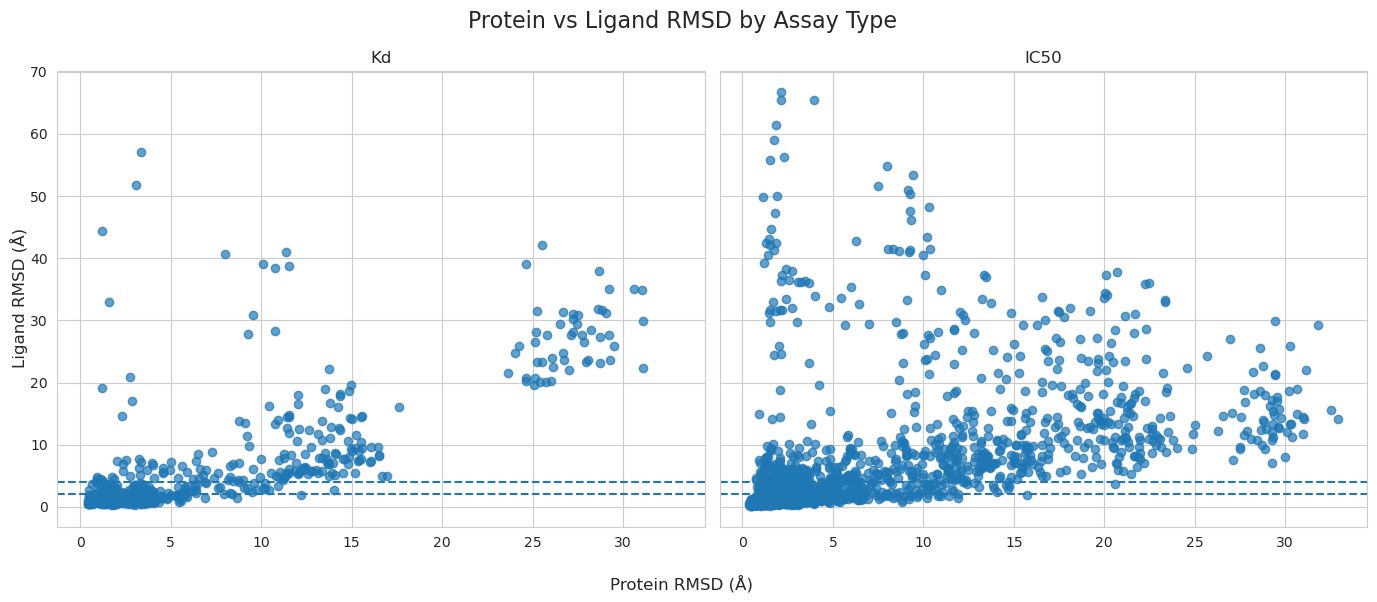

In [220]:
order = ["Kd", "IC50"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax, assay in zip(axes, order):
    sub = plot_df[plot_df["assay_type"] == assay]
    ax.scatter(sub["protein_rmsd"], sub["ligand_rmsd"], alpha=0.7)
    ax.set_title(f"{assay}")
    ax.axhline(2.0, linestyle="--")
    ax.axhline(4.0, linestyle="--")

fig.supxlabel("Protein RMSD (Å)")
fig.supylabel("Ligand RMSD (Å)")
fig.suptitle("Protein vs Ligand RMSD by Assay Type", fontsize=16)

rmsd_plot_path = OUTPUT_PLOTS_DIR / 'rmsd_scatter_by_assay.png'
plt.savefig(rmsd_plot_path, dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

RMSD distribution histogram

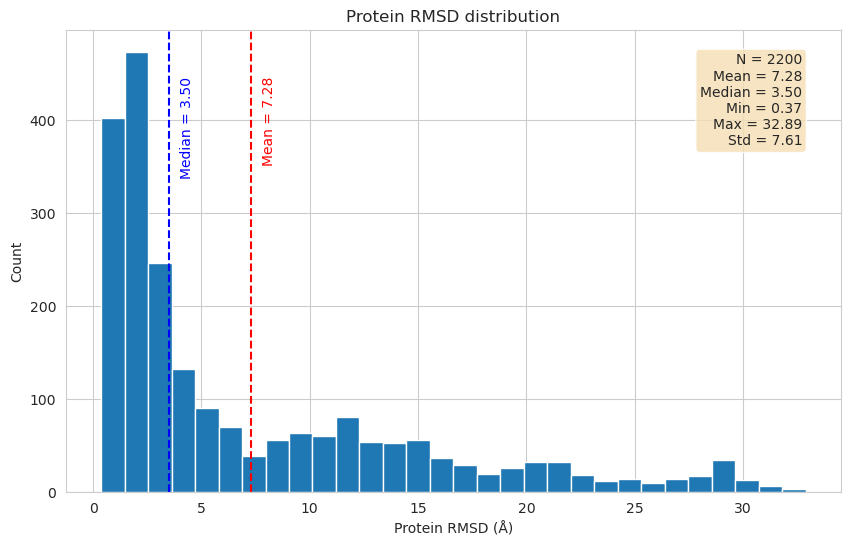

Protein RMSD distribution plot saved at  /scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/eval/plots/protein_rmsd_distribution.png


<Figure size 1200x600 with 0 Axes>

In [131]:
vals = plot_df["protein_rmsd"].dropna().values
stats_txt = (
    f"N = {len(vals)}\n"
    f"Mean = {vals.mean():.2f}\n"
    f"Median = {np.median(vals):.2f}\n"
    f"Min = {vals.min():.2f}\n"
    f"Max = {vals.max():.2f}\n"
    f"Std = {vals.std():.2f}"
)

plt.figure(figsize=(10, 6))
plt.hist(vals, bins=30)
plt.xlabel("Protein RMSD (Å)")
plt.ylabel("Count")
plt.title("Protein RMSD distribution")
plt.text(0.95, 0.95, stats_txt, transform=plt.gca().transAxes,
         ha="right", va="top", bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8)
        )
plt.axvline(np.median(vals), linestyle="--", color="blue")
plt.text(
    np.median(vals) + 0.5, plt.ylim()[1]*0.9,
    f"Median = {np.median(vals):.2f}",
    rotation=90, va="top", ha="left", color="blue"
)
plt.axvline(vals.mean(), linestyle="--", color="red")
plt.text(
    vals.mean() + 0.5, plt.ylim()[1]*0.9,
    f"Mean = {vals.mean():.2f}",
    rotation=90, va="top", ha="left", color="red"
)
plt.show()

rmsd_plot_path = OUTPUT_PLOTS_DIR / 'protein_rmsd_distribution.png'
plt.savefig(rmsd_plot_path, dpi=300, bbox_inches='tight')
print("Protein RMSD distribution plot saved at ", rmsd_plot_path)

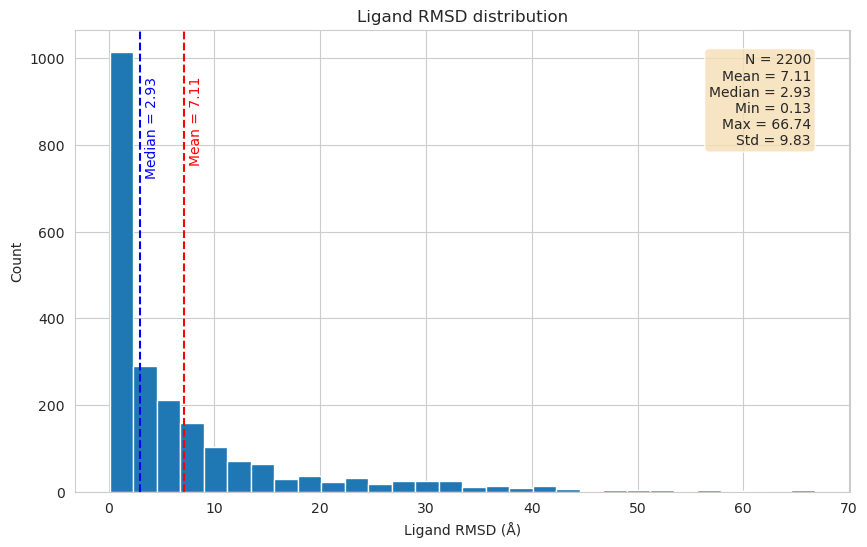

Ligand RMSD distribution plot saved at  /scratch/yunmin/data/graph/lmpnn/bdb_pdb/Kd/eval/plots/ligand_rmsd_distribution.png


<Figure size 1200x600 with 0 Axes>

In [129]:
vals = plot_df["ligand_rmsd"].dropna().values
stats_txt = (
    f"N = {len(vals)}\n"
    f"Mean = {vals.mean():.2f}\n"
    f"Median = {np.median(vals):.2f}\n"
    f"Min = {vals.min():.2f}\n"
    f"Max = {vals.max():.2f}\n"
    f"Std = {vals.std():.2f}"
)

plt.figure(figsize=(10, 6))
plt.hist(vals, bins=30)
plt.xlabel("Ligand RMSD (Å)")
plt.ylabel("Count")
plt.title("Ligand RMSD distribution")
plt.text(0.95, 0.95, stats_txt, transform=plt.gca().transAxes,
         ha="right", va="top", bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8)
        )
plt.axvline(np.median(vals), linestyle="--", color="blue")
plt.text(
    np.median(vals) + 0.5, plt.ylim()[1]*0.9,
    f"Median = {np.median(vals):.2f}",
    rotation=90, va="top", ha="left", color="blue"
)
plt.axvline(vals.mean(), linestyle="--", color="red")
plt.text(
    vals.mean() + 0.5, plt.ylim()[1]*0.9,
    f"Mean = {vals.mean():.2f}",
    rotation=90, va="top", ha="left", color="red"
)
plt.show()

rmsd_plot_path = OUTPUT_PLOTS_DIR / 'ligand_rmsd_distribution.png'
plt.savefig(rmsd_plot_path, dpi=300, bbox_inches='tight')
print("Ligand RMSD distribution plot saved at ", rmsd_plot_path)

Ligand Success Rate (lig RMSD < 2A, 4A) + by assay type

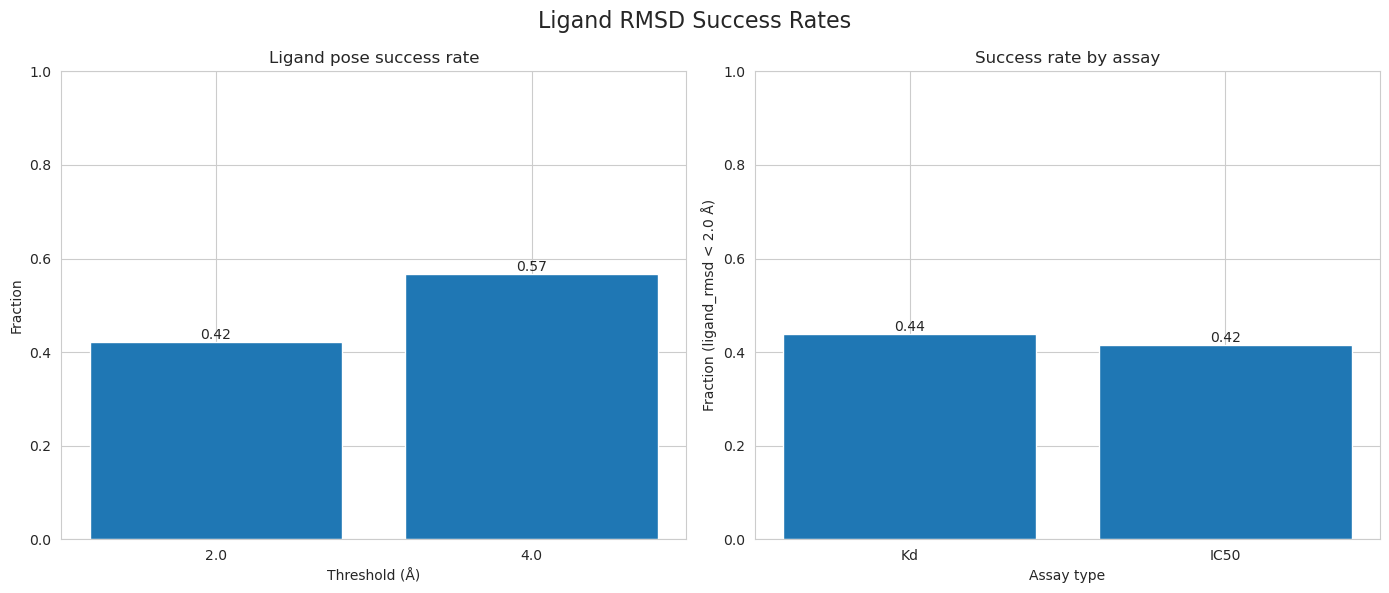

Ligand RMSD success rate by assay plot saved at  /scratch/yunmin/data/graph/lmpnn/bdb_pdb/all/eval/plots/ligand_rmsd_success_rate.png


<Figure size 1200x600 with 0 Axes>

In [222]:
order = ["Kd", "IC50"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Ligand pose success rates (lig RMSD < 2Å and < 4Å)
thresholds = [2.0, 4.0]
rates = [(plot_df["ligand_rmsd"] < t).mean() for t in thresholds]

bars0 = axes[0].bar([str(t) for t in thresholds], rates)
axes[0].set_xlabel("Threshold (Å)")
axes[0].set_ylabel("Fraction")
axes[0].set_title("Ligand pose success rate")
axes[0].bar_label(bars0, fmt="%.2f")
axes[0].set_ylim(0, 1)

# Success rate by assay type
threshold = 2.0
rates_by_assay = [
    (plot_df.loc[plot_df["assay_type"] == assay, "ligand_rmsd"] < threshold).mean()
    for assay in order
]

bars1 = axes[1].bar(order, rates_by_assay)
axes[1].set_xlabel("Assay type")
axes[1].set_ylabel(f"Fraction (ligand_rmsd < {threshold} Å)")
axes[1].set_title("Success rate by assay")
axes[1].bar_label(bars1, fmt="%.2f")
axes[1].set_ylim(0, 1)

fig.suptitle("Ligand RMSD Success Rates", fontsize=16)
plt.tight_layout()
plt.show()

rmsd_plot_path = OUTPUT_PLOTS_DIR / 'ligand_rmsd_success_rate.png'
plt.savefig(rmsd_plot_path, dpi=300, bbox_inches='tight')
print("Ligand RMSD success rate by assay plot saved at ", rmsd_plot_path)

## Detailed Analysis

### Model-wise Analysis

Model Comparison Across Metrics


confidence_score       ptm      iptm  ligand_iptm  \
model_num target_type                                                      
0         off                  0.780394  0.727506  0.802275     0.802275   
          tar                  0.791096  0.721854  0.826848     0.826848   
1         off                  0.769146  0.715323  0.778792     0.778792   
          tar                  0.781169  0.709849  0.805759     0.805759   
2         off                  0.758063  0.705016  0.753614     0.753614   
          tar                  0.771237  0.700215  0.785992     0.785992   

                       complex_plddt  complex_iplddt  complex_pde  \
model_num target_type                                               
0         off               0.774923        0.711967     1.241610   
          tar               0.782158        0.726455     1.231308   
1         off               0.766734        0.700461     1.311196   
          tar               0.775021        0.716522     1.298455   
2         off               0.759176        0.689232     1.372011   
          tar               0.767548        0.705518     1.355349   

                       complex_ipde   pae_mean  pde_mean  plddt_mean  \
model_num target_type                                                  
0         off              3.992614  10.801952  3.706524    0.774923   
          tar              4.041341  11.385343  3.870410    0.782158   
1         off              4.247044  11.174307  3.863013    0.766734   
          tar              4.276822  11.758961  4.030842    0.775021   
2         off              4.524102  11.478092  3.989810    0.759176   
          tar              4.551552  12.030476  4.164042    0.767548   

                       affinity_pred_value  affinity_probability_binary  
model_num target_type                                                    
0         off                     0.989496                     0.440366  
          tar                    -0.278637                     0.615870  
1         off                     0.989496                     0.440366  
          tar                    -0.278637                     0.615870  
2         off                     0.989496                     0.440366  
          tar                    -0.278637                     0.615870

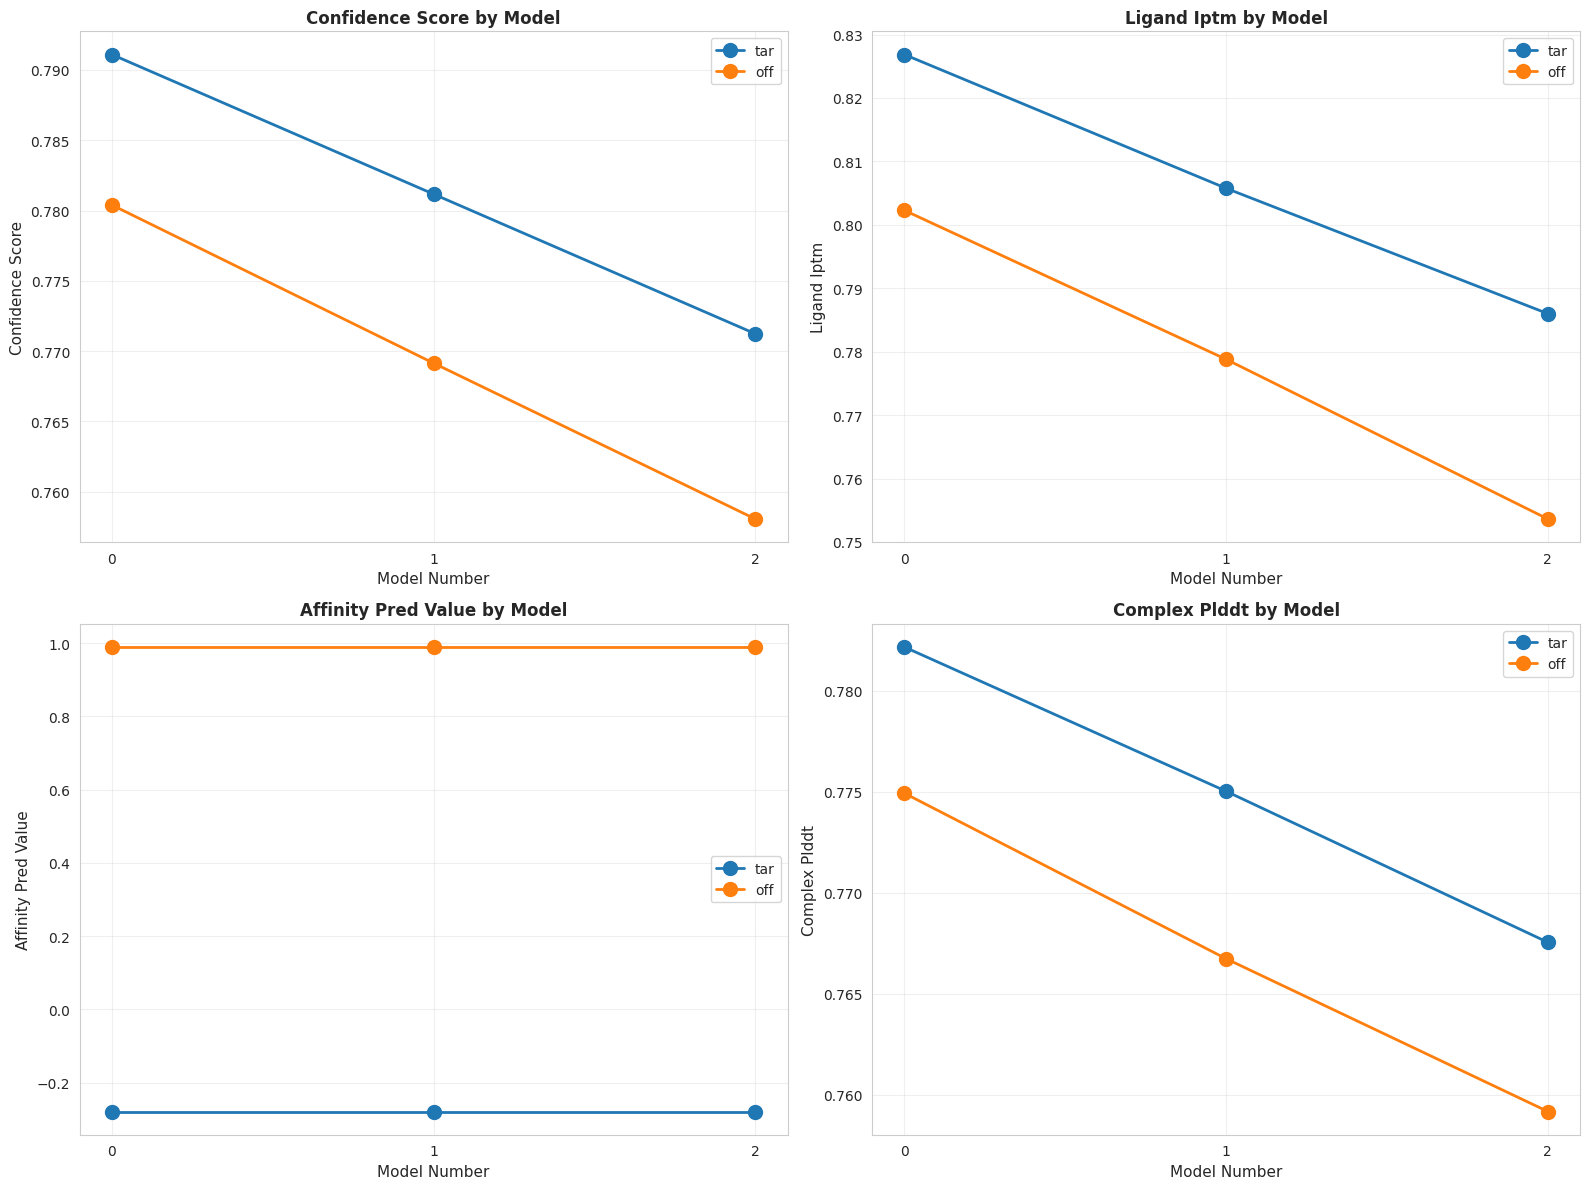

Model Comparison plots saved: model_comparison.png


In [ ]:
# Model comparison across metrics
print("=" * 80)
print("Model Comparison Across Metrics")
print("=" * 80)

model_comparison = df.groupby(['model_num', 'target_type'])[metrics].mean()
display(model_comparison)

# Plot model comparison for key metrics
key_metrics_model = ['confidence_score', 'ligand_iptm', 'affinity_pred_value', 'complex_plddt']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, metric in enumerate(key_metrics_model):
    ax = axes[idx]
    
    # Group by model and target type
    grouped = df.groupby(['model_num', 'target_type'])[metric].mean().reset_index()
    
    # Plot
    for target_type in ['tar', 'off']:
        subset = grouped[grouped['target_type'] == target_type]
        ax.plot(subset['model_num'], subset[metric], 
               marker='o', markersize=10, linewidth=2, label=target_type)
    
    ax.set_xlabel('Model Number', fontsize=11)
    ax.set_ylabel(metric.replace('_', ' ').title(), fontsize=11)
    ax.set_title(f'{metric.replace("_", " ").title()} by Model', fontsize=12, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xticks([0, 1, 2])

plt.tight_layout()
plt.savefig(BOLTZ_EVAL_DIR / 'plots' / 'model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Model Comparison plots saved: model_comparison.png")

### Sequence-wise Variability Analysis

In [ ]:
print("=" * 80)
print("Sequence-wise Variability Analysis")
print("=" * 80)

# Average for (protein, target_type, seq_num) set
seq_level_data = df.groupby(['uniprot_id', 'target_type', 'seq_num'])[metrics].mean().reset_index()

# Variability (std dev along seqeucnes in each protein/target_type)
variability_results = []

for protein in df['uniprot_id'].unique():
    for target_type in ['tar', 'off']:
        subset = seq_level_data[(seq_level_data['uniprot_id'] == protein) & 
                               (seq_level_data['target_type'] == target_type)]
        
        if len(subset) > 1:
            for metric in metrics:
                std = subset[metric].std()
                mean = subset[metric].mean()
                cv = (std / mean * 100) if mean != 0 else 0  # Coefficient of Variation
                
                variability_results.append({
                    'uniprot_id': protein,
                    'target_type': target_type,
                    'metric': metric,
                    'std': std,
                    'mean': mean,
                    'cv_percent': cv,
                    'n_sequences': len(subset)
                })

variability_df = pd.DataFrame(variability_results)

# Summary: Average variability per metric
print("\nAverage Coefficient of Variation (%) by Metric:")
cv_summary = variability_df.groupby(['metric', 'target_type'])['cv_percent'].mean().unstack()
cv_summary['difference'] = cv_summary['tar'] - cv_summary['off']
cv_summary_sorted = cv_summary.sort_values('difference', ascending=False)
print(cv_summary_sorted)

variability_df.head(20)

Sequence-wise Variability Analysis

Average Coefficient of Variation (%) by Metric:
target_type                        off        tar  difference
metric                                                       
affinity_pred_value         -36.618886 -22.956878   13.662008
ptm                           5.487761   5.165340   -0.322421
plddt_mean                    4.793578   4.454444   -0.339133
complex_plddt                 4.793578   4.454444   -0.339133
complex_iplddt                6.414415   6.045332   -0.369083
confidence_score              4.674663   4.254810   -0.419853
complex_pde                  14.030380  13.511343   -0.519036
affinity_probability_binary  10.137471   9.412686   -0.724785
ligand_iptm                   6.409107   5.650934   -0.758174
iptm                          6.409107   5.650934   -0.758174
complex_ipde                 17.486453  16.686697   -0.799756
pde_mean                     15.071217  13.848474   -1.222744
pae_mean                      9.917401   8.60870

,uniprot_id,target_type,metric,std,mean,cv_percent,n_sequences
0,Q07889,tar,confidence_score,0.029472,0.470160,6.268457,10
1,Q07889,tar,ptm,0.024331,0.304978,7.977800,10
2,Q07889,tar,iptm,0.072974,0.465571,15.673980,10
3,Q07889,tar,ligand_iptm,0.072974,0.465571,15.673980,10
4,Q07889,tar,complex_plddt,0.027714,0.471307,5.880246,10
5,Q07889,tar,complex_iplddt,0.028680,0.358658,7.996540,10
6,Q07889,tar,complex_pde,0.217291,3.417907,6.357439,10
7,Q07889,tar,complex_ipde,1.028227,10.870046,9.459269,10
8,Q07889,tar,pae_mean,0.505894,25.118154,2.014056,10
9,Q07889,tar,pde_mean,0.308023,11.665079,2.640555,10


NameError: name 'variability_df' is not defined

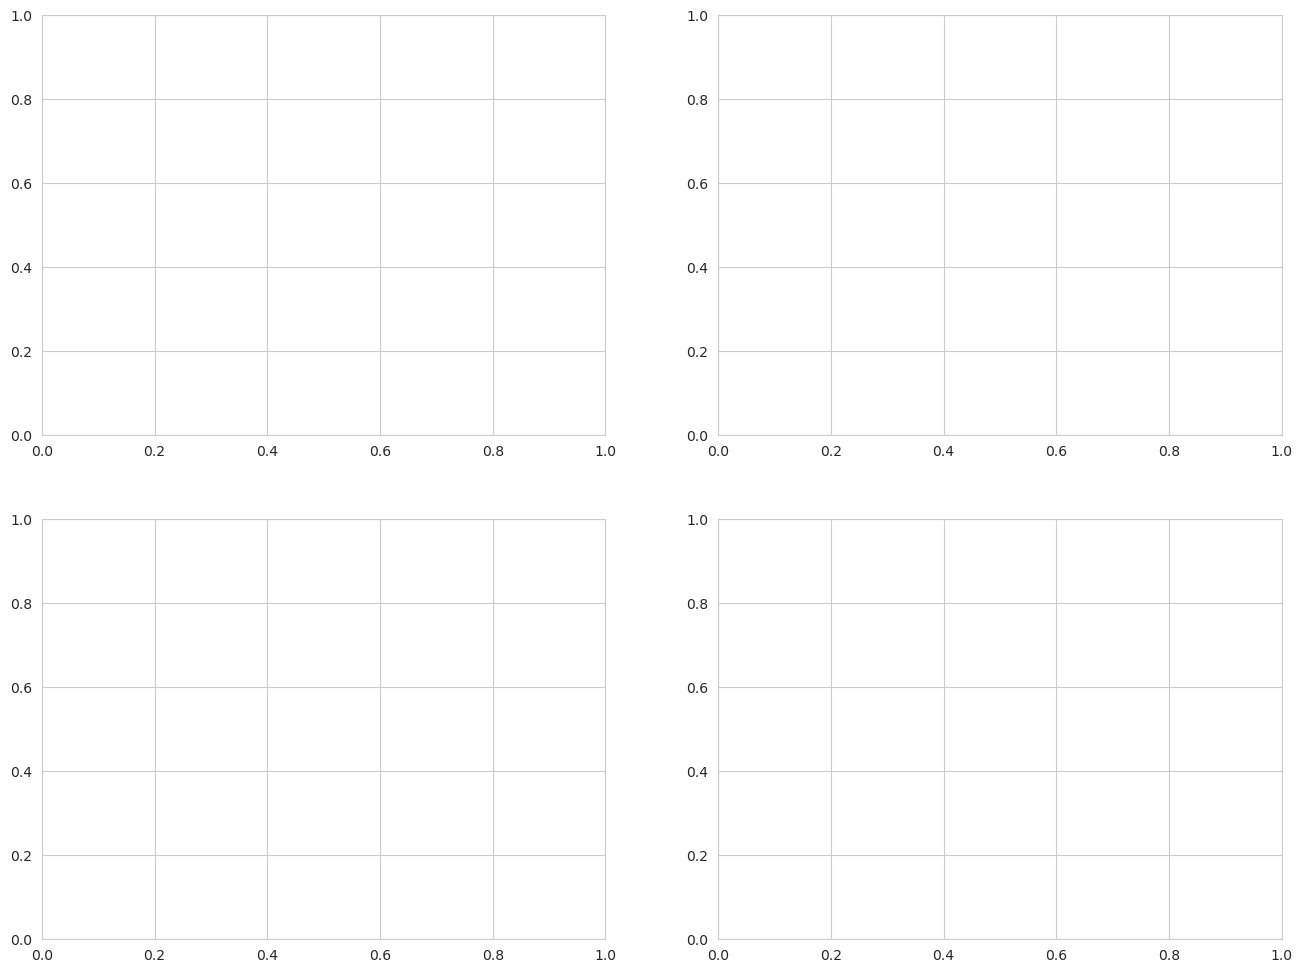

In [223]:
# Visualize sequence variability
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

variability_metrics = ['confidence_score', 'ligand_iptm', 'affinity_pred_value', 'complex_plddt']
colors_var = {'tar': '#3498db', 'off': '#e74c3c'}

for idx, metric in enumerate(variability_metrics):
    ax = axes[idx]
    
    metric_data = variability_df[variability_df['metric'] == metric]
    
    # Bar plot of CV for each protein
    x_pos = np.arange(len(metric_data['uniprot_id'].unique()))
    width = 0.35
    
    for i, target_type in enumerate(['tar', 'off']):
        subset = metric_data[metric_data['target_type'] == target_type]
        subset_sorted = subset.sort_values('uniprot_id')
        
        ax.bar(x_pos + i * width, subset_sorted['cv_percent'], width, 
              label=target_type, color=colors_var[target_type], alpha=0.8,
              edgecolor='black', linewidth=1)
    
    ax.set_xlabel('Protein', fontsize=11)
    ax.set_ylabel('Coefficient of Variation (%)', fontsize=11)
    ax.set_title(f'{metric.replace("_", " ").title()} - Sequence Variability', 
                fontsize=12, fontweight='bold')
    ax.set_xticks(x_pos + width / 2)
    ax.set_xticklabels(sorted(metric_data['uniprot_id'].unique()), rotation=45, ha='right')
    ax.legend(loc='best', framealpha=0.9)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(BOLTZ_EVAL_DIR / 'plots' / 'sequence_variability.png', dpi=300, bbox_inches='tight')
plt.show()

print("Sequence variability plot saved: sequence_variability.png")

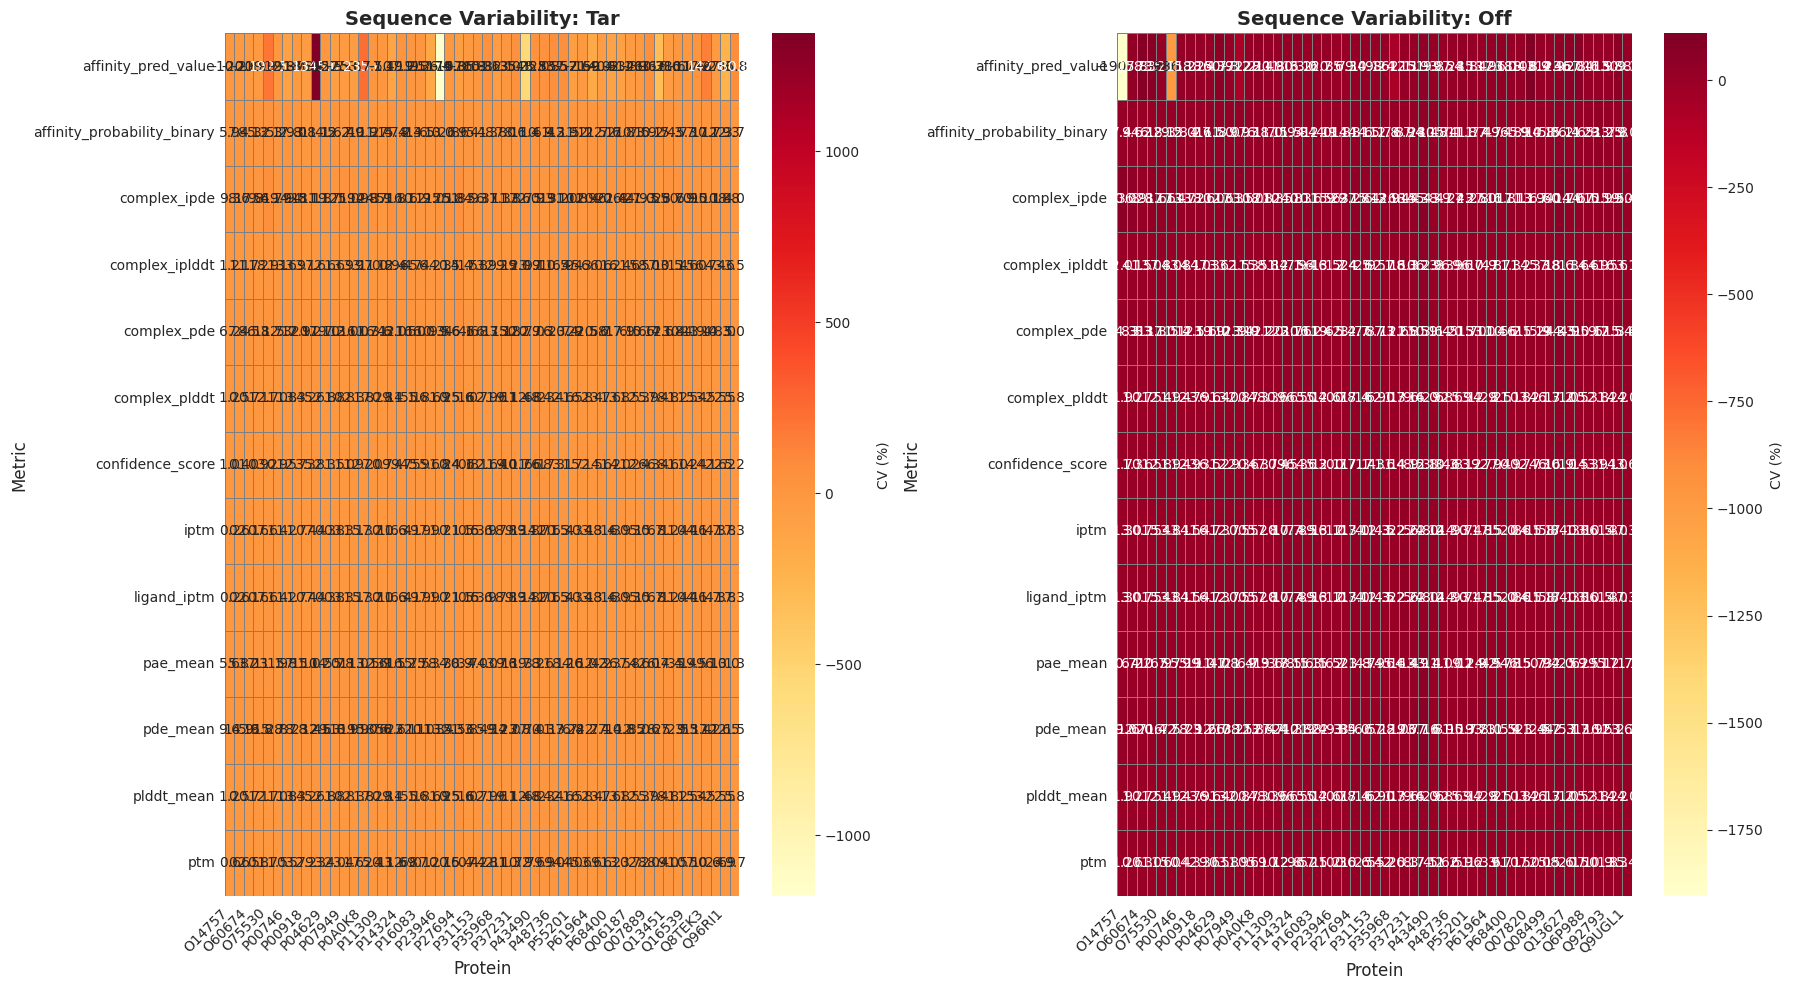

Sequence variability heatmap saved: sequence_variability_heatmap.png


In [ ]:
# Heatmap: Variability comparison across all metrics
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

for idx, target_type in enumerate(['tar', 'off']):
    ax = axes[idx]
    
    # Pivot data for heatmap
    heatmap_data = variability_df[variability_df['target_type'] == target_type].pivot(
        index='metric', columns='uniprot_id', values='cv_percent'
    )
    
    sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
               cbar_kws={'label': 'CV (%)'}, linewidths=0.5, linecolor='gray')
    ax.set_title(f'Sequence Variability: {target_type.title()}', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Protein', fontsize=12)
    ax.set_ylabel('Metric', fontsize=12)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    plt.setp(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(BOLTZ_EVAL_DIR / 'plots' / 'sequence_variability_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Sequence variability heatmap saved: sequence_variability_heatmap.png")

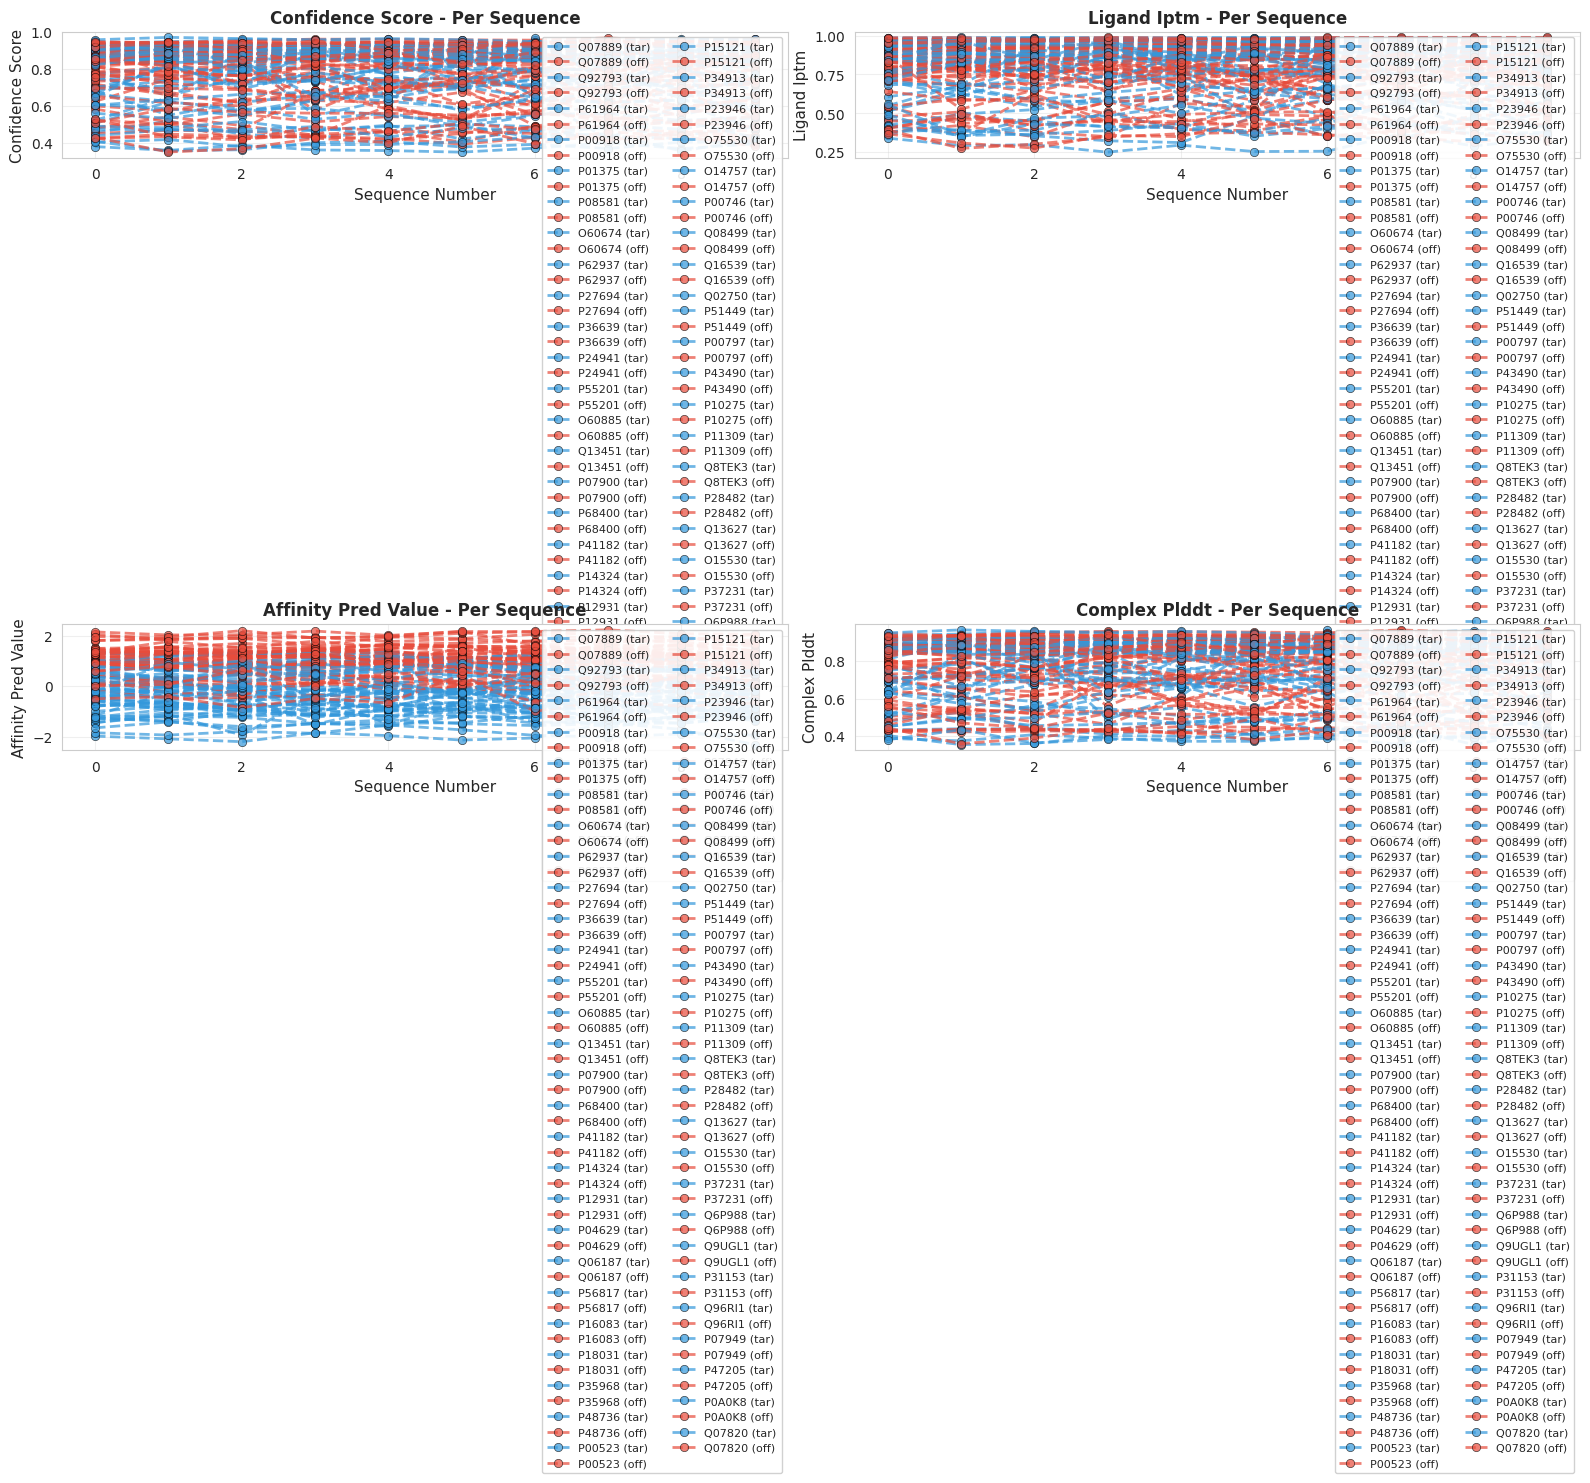

Sequence trajectories plot saved: sequence_trajectories.png


In [ ]:
# Per-sequence trajectory plots for key metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

trajectory_metrics = ['confidence_score', 'ligand_iptm', 'affinity_pred_value', 'complex_plddt']

for idx, metric in enumerate(trajectory_metrics):
    ax = axes[idx]
    
    for protein in df['uniprot_id'].unique():
        for target_type in ['tar', 'off']:
            subset = seq_level_data[(seq_level_data['uniprot_id'] == protein) & 
                                   (seq_level_data['target_type'] == target_type)]
            
            if len(subset) > 0:
                linestyle = '-' if target_type == 'target' else '--'
                color = colors_var[target_type]
                label = f'{protein} ({target_type})'
                
                ax.plot(subset['seq_num'], subset[metric], 
                       marker='o', linestyle=linestyle, linewidth=2, 
                       color=color, label=label, alpha=0.7,
                       markersize=6, markeredgecolor='black', markeredgewidth=0.5)
    
    ax.set_xlabel('Sequence Number', fontsize=11)
    ax.set_ylabel(metric.replace('_', ' ').title(), fontsize=11)
    ax.set_title(f'{metric.replace("_", " ").title()} - Per Sequence', 
                fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=8, ncol=2, framealpha=0.9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(BOLTZ_EVAL_DIR / 'plots' / 'sequence_trajectories.png', dpi=300, bbox_inches='tight')
plt.show()

print("Sequence trajectories plot saved: sequence_trajectories.png")

### Protein-wise Analysis

In [ ]:
# # Target vs Off-target Across Uniprot IDs
# protein_analysis = df.groupby(['uniprot_id', 'target_type'])[key_metrics_model].mean().reset_index()

# print("=" * 80)
# print("Protein Comparison Across Target Type")
# print("=" * 80)
# display(protein_analysis)

# # Protein별 시각화
# unique_proteins = df['uniprot_id'].unique()
# n_proteins = len(unique_proteins)

# fig, axes = plt.subplots(n_proteins, 2, figsize=(16, 5 * n_proteins))
# if n_proteins == 1:
#     axes = axes.reshape(1, -1)

# for idx, protein in enumerate(unique_proteins):
#     protein_data = df[df['uniprot_id'] == protein]
    
#     # Confidence score
#     ax = axes[idx, 0]
#     sns.boxplot(data=protein_data, x='target_type', y='confidence_score', ax=ax, palette='Set3')
#     ax.set_title(f'{protein}: Confidence Score', fontsize=12, fontweight='bold')
#     ax.set_xlabel('Target Type')
#     ax.set_ylabel('Confidence Score')
#     ax.grid(True, alpha=0.3)
    
#     # Affinity
#     ax = axes[idx, 1]
#     sns.boxplot(data=protein_data, x='target_type', y='affinity_pred_value', ax=ax, palette='Set3')
#     ax.set_title(f'{protein}: Affinity Prediction', fontsize=12, fontweight='bold')
#     ax.set_xlabel('Target Type')
#     ax.set_ylabel('Affinity Predicted Value')
#     ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig(BOLTZ_EVAL_DIR / 'plots' / 'protein_wise_analysis.png', dpi=300, bbox_inches='tight')
# plt.show()

# print("Protein-wise analysis plots saved: protein_wise_analysis.png")

## Summary Reports

In [224]:
summary_report = []

summary_report.append("=" * 80)
summary_report.append("LigandMPNN Target vs Off-target Prediction Analysis Summary")
summary_report.append("=" * 80)
summary_report.append("")

summary_report.append("1. Dataset Overview")
summary_report.append("-" * 40)
summary_report.append(f"Total samples: {len(df)}")
summary_report.append(f"Target samples: {len(df[df['target_type'] == 'target'])}")
summary_report.append(f"Off-target samples: {len(df[df['target_type'] == 'off-target'])}")
summary_report.append(f"Number of proteins: {df['uniprot_id'].nunique()}")
summary_report.append(f"Number of sequences per protein: {df['seq_num'].nunique()}")
summary_report.append(f"Number of models: {df['model_num'].nunique()}")
summary_report.append("")

summary_report.append("2. Key Findings")
summary_report.append("-" * 40)

# Find metrics with significant differences
significant_metrics = stat_results[stat_results['P-value'] < 0.05].sort_values('P-value')
summary_report.append(f"\nMetrics with significant differences (p < 0.05): {len(significant_metrics)}")
effect_col = "Effect Size (Cohen's d)"
for _, row in significant_metrics.iterrows():
    direction = "higher" if row['Difference'] > 0 else "lower"
    summary_report.append(
        f"  - {row['Metric']}: Target is {direction} "
        f"(p={row['P-value']:.2e}, effect size={row[effect_col]:.3f})"
    )

summary_report.append("")
summary_report.append("3. ROC-AUC Performance (Classification Ability)")
summary_report.append("-" * 40)
for _, row in roc_results_df.iterrows():
    summary_report.append(f"  - {row['Metric']}: AUC = {row['AUC']:.3f}")

summary_report.append("")
summary_report.append("4. Best Discriminative Metrics")
summary_report.append("-" * 40)
best_metrics = roc_results_df.head(3)
summary_report.append("Top 3 metrics for distinguishing target from off-target:")
for idx, (_, row) in enumerate(best_metrics.iterrows(), 1):
    summary_report.append(f"  {idx}. {row['Metric']} (AUC = {row['AUC']:.3f})")

summary_report.append("")
summary_report.append("=" * 80)
summary_report.append("Analysis complete! All plots saved.")
summary_report.append("=" * 80)

# Print summary
for line in summary_report:
    print(line)

# Save summary to file
summary_path = BOLTZ_EVAL_DIR / 'plots' / 'analysis_summary.txt'
with open(summary_path, 'w') as f:
    f.write('\n'.join(summary_report))

print("\nSummary report saved: analysis_summary.txt")

LigandMPNN Target vs Off-target Prediction Analysis Summary

1. Dataset Overview
----------------------------------------
Total samples: 10350
Target samples: 0
Off-target samples: 0
Number of proteins: 54
Number of sequences per protein: 10
Number of models: 3

2. Key Findings
----------------------------------------

Metrics with significant differences (p < 0.05): 8
  - affinity_pred_value: Target is lower (p=0.00e+00, effect size=-1.408)
  - affinity_probability_binary: Target is higher (p=0.00e+00, effect size=0.924)
  - iptm: Target is higher (p=4.72e-21, effect size=0.135)
  - ligand_iptm: Target is higher (p=4.72e-21, effect size=0.135)
  - pae_mean: Target is higher (p=8.60e-11, effect size=0.081)
  - complex_iplddt: Target is higher (p=4.88e-07, effect size=0.075)
  - pde_mean: Target is higher (p=3.22e-06, effect size=0.048)
  - confidence_score: Target is higher (p=1.05e-03, effect size=0.069)

3. ROC-AUC Performance (Classification Ability)
--------------------------------